In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math 
import networkx as nx
import numpy as np
from skimage.draw import line
from matplotlib.colors import ListedColormap

from coppeliasim_zmqremoteapi_client import RemoteAPIClient 

def Rz(theta):
  
    return np.array([[ np.cos(theta), -np.sin(theta), 0 ],
                      [ np.sin(theta), np.cos(theta) , 0 ],
                      [ 0            , 0             , 1 ]])

### HokuyoSensorSim

In [2]:
# original e funcionado teoricamente
# class HokuyoSensorSim(object):
#     _sim = None
#     _base_name = ""
#     _vision_sensor_name_template = "{}/fastHokuyo_sensor{}"
#     _base_obj = None
#     _is_range_data = False
    
#     _angle_min = -120*math.pi/180
#     _angle_max = 120*math.pi/180
#     _angle_increment = (240/684)*math.pi/180  # angle: 240 deg, pts: 684

#     def __init__(self, sim, base_name, is_range_data=True):
#         self._sim = sim
#         self._base_name = base_name
#         self._is_range_data = is_range_data

#         if "fastHokuyo" not in base_name:
#             raise ValueError("ERR: fastHokuyo must be in the base object name.")

#         self._base_obj = sim.getObject(base_name)
#         if self._base_obj == -1:
#             raise ValueError("ERR: base_obj is not a valid name in the simulation")

#         self._vision_sensors_obj = [
#             sim.getObject(self._vision_sensor_name_template.format(self._base_name, 1)),
#             sim.getObject(self._vision_sensor_name_template.format(self._base_name, 2)),
#         ]

#         if any(obj == -1 for obj in self._vision_sensors_obj):
#             raise ValueError("ERR: the vision sensors are not valid in the simulation")

#     def getSensorData(self):
#         angle = self._angle_min
#         sensor_data = []
        
#         for vision_sensor in self._vision_sensors_obj:
#             _, _, u = sim.readVisionSensor(vision_sensor)
#             if u:
                
#                     for j in range(int(u[1])):
#                         for k in range(int(u[0])):
#                             w = 2 + 4 * (j * int(u[0]) + k)
#                             v = [u[w], u[w + 1], u[w + 2], u[w + 3]]
#                             angle = angle + self._angle_increment
#                             if self._is_range_data:
#                                 sensor_data.append([angle, v[3]])
#                             else:
#                                 sensor_data.append([v[0], v[1], v[2]])
                            
#         return np.array(sensor_data)


# def transform_laser_to_global(laser_data, robot_pos, robot_ori):

#     x_r, y_r = robot_pos[0], robot_pos[1]
#     theta_r = robot_ori[2]  # orientação em torno de z

#     global_points = []

    

#     for ang, dist in laser_data:
#         if dist > 0.01 and dist < 5:
#             # coordenadas no robô
#             x_local = dist * np.cos(ang)
#             y_local = dist * np.sin(ang)

#             # transformação para global
#             x_global = x_r + x_local*np.cos(theta_r) - y_local*np.sin(theta_r)
#             y_global = y_r + x_local*np.sin(theta_r) + y_local*np.cos(theta_r)

#             global_points.append([x_global, y_global])

#     return global_points

In [3]:
# codigo de aluno no moodle

class HokuyoSensorSim(object): 
    _sim = None
    
    _base_name = "" 

    _angles_lua = np.empty(0) 
    _is_initialized_angles = False 
    ANGLE_SIGNAL = 'signal.hokuyo_angle_data' 
    
    _base_obj = None 
    _is_range_data = True
    _vision_sensors_obj = []

    def __init__(self, sim, base_name, is_range_data=True):
        self._sim = sim
        self._base_name = base_name
        self._is_range_data = is_range_data

        if "fastHokuyo" not in base_name:
            raise ValueError(
                f"ERR: fastHokuyo must be in the base object name. Ex: `/kobuki/fastHokuyo`"
            )

        self._base_obj = sim.getObject(base_name)
        if self._base_obj == -1:
            raise ValueError(
                f"ERR: base_obj ({self._base_obj}) is not a valid name in the simulation"
            )

        self._vision_sensors_obj = [
            sim.getObject(f'{base_name}/fastHokuyo_sensor1'),
            sim.getObject(f'{base_name}/fastHokuyo_sensor2'),
        ]

        if any(obj == -1 for obj in self._vision_sensors_obj):
            raise ValueError(
                f"ERR: the _vision_sensors_obj names are not valid in the simulation"
            )

    def get_is_range_data(self) -> bool:
        return self._is_range_data

    def set_is_range_data(self, is_range_data: bool) -> None:
        self._is_range_data = is_range_data

    def _initialize_angles_from_lua(self):

        # Essas variáveis agora são utilizadas apenas quando os valores do laser 
        # não são desempacotados diretamente do sensor, como um fallback em caso de falha
        angle_min = -120 * math.pi / 180
        angle_increment = (240 / 684) * math.pi / 180
        total_steps = 684
        
        for i in range(15):
            try:
                if self._vision_sensors_obj and self._vision_sensors_obj[0] != -1:
                    self._sim.readVisionSensor(self._vision_sensors_obj[0]) 

                angles_packed = self._sim.getBufferProperty(self._sim.handle_scene, self.ANGLE_SIGNAL, {'noError' : True})
                
                if angles_packed:
                    self._angles_lua = np.array(self._sim.unpackFloatTable(angles_packed))
                    self._is_initialized_angles = True
                    print(f"Precise sensor angles read on attempt {i+1} ({self._angles_lua.size} laser beam readings)")
                    return True
                
                time.sleep(0.01)

            except Exception as e:
                pass 
                
        self._angles_lua = np.arange(angle_min, angle_min + total_steps * angle_increment, angle_increment)
        self._is_initialized_angles = True
        print("ALERT: Communication via buffer property failed. Using approximation. Map may be blurred.")
        return False

    def getSensorData(self):
        
        if not self._is_initialized_angles:
            self._initialize_angles_from_lua()
        
        sensor_data = []
        angle_idx = 0
        angles_to_use = self._angles_lua
        
        if angles_to_use.size == 0:
            return np.empty((0, 2))
        
        for vision_sensor in self._vision_sensors_obj:
            
            result = self._sim.readVisionSensor(vision_sensor)
            if not isinstance(result, (list, tuple)) or len(result) != 3: continue 
                
            r, t, u = result
            if u:
                for j in range(int(u[1])): 
                    for k in range(int(u[0])): 
                        w_idx = 2 + 4 * (j * int(u[0]) + k)
                        v_dist = u[w_idx + 3] 
                        if angle_idx < angles_to_use.size:
                            current_angle = angles_to_use[angle_idx]
                            sensor_data.append([current_angle, v_dist])
                            angle_idx += 1
                        else:
                            break 
                    if angle_idx >= angles_to_use.size: break

        return np.array(sensor_data) if sensor_data else np.empty((0, 2))
    
def transform_laser_to_global(laser_data, robot_pos, robot_ori):

    x_r, y_r = robot_pos[0], robot_pos[1]
    theta_r = robot_ori[2]  # orientação em torno de z

    global_points = []

    

    for ang, dist in laser_data:
        if dist > 0.01 and dist < 5:
            # coordenadas no robô
            x_local = dist * np.cos(ang)
            y_local = dist * np.sin(ang)

            # transformação para global
            x_global = x_r + x_local*np.cos(theta_r) - y_local*np.sin(theta_r)
            y_global = y_r + x_local*np.sin(theta_r) + y_local*np.cos(theta_r)

            global_points.append([x_global, y_global])

    return global_points

### Novos testes Ocuppancy Grid


In [4]:
# verificar funcao
def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
        scale = world_size / img_size
        x_world = ((x_px - img_size/2) * scale)
        y_world = (-(y_px - img_size/2) * scale) 
        return x_world, y_world


def att_force(q, goal, katt=.01):
    return katt*(goal - q)

def rep_force(q, laser_data, R=3, krep=.1):
    # Se lista estiver vazia
    if not laser_data:
        return np.zeros(2)

    laser_data = np.array(laser_data, dtype=float)

    # Garante que tenha 3 colunas (x, y, r)
    if laser_data.shape[1] == 2:
        # adiciona uma coluna de zeros (raio)
        laser_data = np.hstack([laser_data, np.zeros((laser_data.shape[0], 1))])

    # Vetor posição relativa robô -> obstáculo
    v = q - laser_data[:, :2]

    # Distância ao obstáculo (menos o raio)
    d = np.linalg.norm(v, axis=1) - laser_data[:, 2]
    d = np.maximum(d, 1e-6)  # evita divisão por zero
    d = d.reshape(-1, 1)

    # Força repulsiva
    rep = (1/d**2) * ((1/d) - (1/R)) * (v/d)

    # Zera onde fora do raio de influência
    rep[d.flatten() > R, :] = 0.0

    # Retorna soma das forças
    return krep * np.sum(rep, axis=0)




In [4]:
def controle(laser_data,r,L):
     # Controle simples de desvio
        v, w = 0, 0
        frente = int(len(laser_data) / 2)
        lado_direito = int(len(laser_data) * 1 / 4)
        lado_esquerdo = int(len(laser_data) * 3 / 4)

        if laser_data[frente, 1] > 2:
            v = .5
            w = 0
        elif laser_data[lado_direito, 1] > 1:
            v = 0
            w = np.deg2rad(-45)
        elif laser_data[lado_esquerdo, 1] > 1:
            v = 0
            w = np.deg2rad(45)

        # Modelo cinemático
        wl = v / r - (w * L) / (2 * r)
        wr = v / r + (w * L) / (2 * r)
        
        return wl,wr



def controle_campos(word, goal_position, robot_pos, robot_ori, laser_data, r, L):
    # constantes -> verificar
    K_att = 50
    REP_RADIUS = 0.6
    REP_GAIN = 15

    MAX_LINEAR_VEL = 0.8
    MAX_ANGULAR_VEL = np.deg2rad(90)

    LINEAR_GAIN = 0.25
    ANGULAR_GAIN = 2.0
    GOAL_TOL = 0.20

    
    laser_global = transform_laser_to_global(laser_data, robot_pos, robot_ori)
    f_att = att_force(robot_pos, goal_position,K_att)
    f_rep = rep_force(robot_pos, laser_global, R = REP_RADIUS, krep = REP_GAIN)

    f_total = f_att + f_rep

    # CONTROLADOR DESAI ET AL. (1998) -> verificar se realmente está correto
    xd, yd = f_total
    theta = robot_ori[2]
    d = L / 2.0  

    J = np.array([
        [np.cos(theta), np.sin(theta)],
        [-np.sin(theta) / d, np.cos(theta) / d]
    ])

    v_cmd, w_cmd = J @ np.array([xd, yd])

    v_cmd *= LINEAR_GAIN
    w_cmd *= ANGULAR_GAIN

    theta_d = np.arctan2(f_total[1], f_total[0])
    erro_theta = np.arctan2(np.sin(theta_d - theta), np.cos(theta_d - theta))
    if abs(erro_theta) > np.deg2rad(45):
        v_cmd *= 0.25

    v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
    w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

    # prev_v_cmd = v_cmd

    # cinematica
    v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
    v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

    return v_l, v_r



import numpy as np


def controle_wall_following_corrigido(laser_data, r, L):
    """
    Controlador 'Right Wall Following' com lógica de velocidade e erro corrigida.
    """
    # print(type(laser_data))
    # print(laser_data[:5])
    # --- Constantes ---
    # DISTANCIA_DESEJADA = 0.5
    # KP_ANGULAR = 2.0
    # VEL_LINEAR_FIXA = 0.35 # Esta é a velocidade-alvo
    # MAX_LINEAR_VEL = 0.8
    # MAX_ANGULAR_VEL = np.deg2rad(90)
    # LIMITE_FRONTAL = 0.35  
    # ZONA_MORTA_ERRO = 0.05
    # # Novo: Distância para considerar "sem parede"
    # DISTANCIA_SEM_PAREDE = 2.0 
    
    DISTANCIA_DESEJADA = 0.8
    KP_ANGULAR = 2
    VEL_LINEAR_FIXA = 1 # Esta é a velocidade-alvo
    MAX_LINEAR_VEL = 1
    MAX_ANGULAR_VEL = np.deg2rad(90)
    LIMITE_FRONTAL = 0.9 
    ZONA_MORTA_ERRO = 0.05
    # Novo: Distância para considerar "sem parede"
    DISTANCIA_SEM_PAREDE = 2.0 
    

    # --- Laser ---
    if isinstance(laser_data, dict) and "ranges" in laser_data:
        ranges = np.array(laser_data["ranges"], dtype=float)
    else:
        # laser_data é ndarray com colunas [ângulo, distância]
        ranges = np.array(laser_data[:, 1], dtype=float)

    # Limpeza
    ranges = np.nan_to_num(ranges, posinf=100.0, neginf=0.0)
    num = len(ranges)
    if num == 0:
        return 0.0, 0.0

    c = num // 2
    fatia_frente = int(num * 0.08)
    frente_ranges = ranges[c - fatia_frente : c + fatia_frente]
    dist_frente = np.min(frente_ranges) if frente_ranges.size > 0 else 100.0

    # !!! CORREÇÃO DO BUG DO LASER !!!
    # Assume que ranges[0] é a direita.
    fatia_direita = int(num * 0.10)
    direita_ranges = ranges[0 : fatia_direita] 
    dist_direita = np.min(direita_ranges) if direita_ranges.size > 0 else 100.0
    
    # Se o robô começar a seguir a parede da ESQUERDA, 
    # troque a linha acima por esta:
    # direita_ranges = ranges[num - fatia_direita : num] 
    # dist_direita = np.min(direita_ranges) if direita_ranges.size > 0 else 100.0
    # if dist_direita < DISTANCIA_DESEJADA:
    #     v_cmd *= dist_direita / DISTANCIA_DESEJADA
    #     v_cmd = max(v_cmd, 0.05)

    # --- Controle Corrigido ---
    
    # Caso 1: Obstáculo à frente
    if dist_frente < LIMITE_FRONTAL:
    # Caso obstáculo à frente
        if dist_direita < DISTANCIA_DESEJADA + 0.2:
            # Obstáculo na frente e parede muito próxima → fazer curva para esquerda
            v_cmd = 0.1
            w_cmd = MAX_ANGULAR_VEL * 0.7
        else:
            # Obstáculo frontal mas parede distante → contornar à direita
            v_cmd = 0.1
            w_cmd = -MAX_ANGULAR_VEL * 0.5

    # Caso 3: Seguindo a parede (Controle P)
    else:
        erro = DISTANCIA_DESEJADA - dist_direita
        if abs(erro) < ZONA_MORTA_ERRO:
            erro = 0.0
        
        # O 'clip' do erro foi removido para deixar o P funcionar
        w_cmd = KP_ANGULAR * erro
        
        # Lógica de velocidade estável (corrige o Bug 1)
        fator_reducao = 1.0 - (abs(w_cmd) / MAX_ANGULAR_VEL)
        v_cmd = VEL_LINEAR_FIXA * fator_reducao
        v_cmd = max(v_cmd, 0.1) # Garantir que nunca pare

    # --- Saturação (Clipping) ---
    v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
    w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

    # --- Cinemática diferencial ---
    v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
    v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)
    
    # print(f"Frente={dist_frente:.2f}, Direita={dist_direita:.2f}, v={v_cmd:.2f}, w={np.rad2deg(w_cmd):.1f}")

    
    return v_l, v_r

def controle_wall_following_corrigido(laser_data, r, L):
    """
    Controlador 'Right Wall Following' com lógica de velocidade e erro corrigida.
    """
    # print(type(laser_data))
    # print(laser_data[:5])
    # --- Constantes ---
    # DISTANCIA_DESEJADA = 0.5
    # KP_ANGULAR = 2.0
    # VEL_LINEAR_FIXA = 0.35 # Esta é a velocidade-alvo
    # MAX_LINEAR_VEL = 0.8
    # MAX_ANGULAR_VEL = np.deg2rad(90)
    # LIMITE_FRONTAL = 0.35  
    # ZONA_MORTA_ERRO = 0.05
    # # Novo: Distância para considerar "sem parede"
    # DISTANCIA_SEM_PAREDE = 2.0 
    
    # --- Constantes de Controle ---
    DISTANCIA_DESEJADA = 0.8       # Distância ideal da parede
    KP_ANGULAR = 2.0               # Ganho proporcional do controle angular
    VEL_LINEAR_FIXA = 1.0          # Velocidade base (antes de redução)
    MAX_LINEAR_VEL = 1.0           # Velocidade máxima linear
    MAX_ANGULAR_VEL = np.deg2rad(90)  # Limite de velocidade angular
    LIMITE_FRONTAL = 0.9           # Distância mínima frontal para desvio
    ZONA_MORTA_ERRO = 0.05         # Faixa neutra para evitar oscilação
    DISTANCIA_SEM_PAREDE = 2.0     # Distância máxima antes de considerar que não há parede

    # --- Processamento do laser ---
    if isinstance(laser_data, dict) and "ranges" in laser_data:
        ranges = np.array(laser_data["ranges"], dtype=float)
    else:
        # Espera array Nx2: [ângulo, distância]
        ranges = np.array(laser_data[:, 1], dtype=float)

    # Limpa dados inválidos
    ranges = np.nan_to_num(ranges, posinf=100.0, neginf=0.0)
    num = len(ranges)
    if num == 0:
        return 0.0, 0.0

    # Índice central (frente do robô)
    c = num // 2

    # --- Leitura frontal ---
    fatia_frente = int(num * 0.08)
    frente_ranges = ranges[c - fatia_frente : c + fatia_frente]
    dist_frente = np.min(frente_ranges) if frente_ranges.size > 0 else 100.0

    # --- Leitura lateral direita (filtrada) ---
    fatia_direita = int(num * 0.10)
    direita_ranges = ranges[0 : fatia_direita]

    # Filtragem: média dos 25% menores valores válidos
    validas = direita_ranges[direita_ranges < DISTANCIA_SEM_PAREDE]
    if len(validas) > 0:
        dist_direita = np.mean(np.sort(validas)[:max(3, len(validas)//4)])
    else:
        dist_direita = DISTANCIA_SEM_PAREDE

    # --- Memória curta: suaviza buracos entre pernas de móveis ---
    if not hasattr(controle_wall_following_corrigido, "ultima_direita"):
        controle_wall_following_corrigido.ultima_direita = dist_direita

    # Se a nova leitura for muito maior que a anterior → parede "sumiu"
    if dist_direita > controle_wall_following_corrigido.ultima_direita * 1.5:
        dist_direita = controle_wall_following_corrigido.ultima_direita * 1.1

    controle_wall_following_corrigido.ultima_direita = dist_direita

    # --- Controle principal ---
    if dist_frente < LIMITE_FRONTAL:
        # Caso obstáculo à frente
        if dist_direita < DISTANCIA_DESEJADA + 0.2:
            # Obstáculo na frente e parede próxima → curva à esquerda
            v_cmd = 0.1
            w_cmd = MAX_ANGULAR_VEL * 0.7
        else:
            # Obstáculo frontal mas parede distante → curva à direita
            v_cmd = 0.1
            w_cmd = -MAX_ANGULAR_VEL * 0.5

    elif dist_direita > DISTANCIA_SEM_PAREDE:
        # Perdeu a parede de vista → segue reto até reencontrar
        v_cmd = 0.4
        w_cmd = 0.0

    else:
        # Controle P: seguir parede suavemente
        erro = DISTANCIA_DESEJADA - dist_direita
        if abs(erro) < ZONA_MORTA_ERRO:
            erro = 0.0

        w_cmd = KP_ANGULAR * erro

        # Ajusta velocidade linear conforme curvatura
        fator_reducao = 1.0 - (abs(w_cmd) / MAX_ANGULAR_VEL)
        v_cmd = VEL_LINEAR_FIXA * fator_reducao
        v_cmd = max(v_cmd, 0.1)

    # --- Saturação ---
    v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
    w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

    # --- Cinemática diferencial ---
    v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
    v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

    # Debug opcional
    # print(f"Frente={dist_frente:.2f}, Direita={dist_direita:.2f}, v={v_cmd:.2f}, w={np.rad2deg(w_cmd):.1f}")

    return v_l, v_r

# --- Variáveis Globais da Máquina de Estados ---
# Define os estados possíveis da manobra
ESTADO_SEGUIR_PAREDE = 0
ESTADO_MANOBRA_VIRAR1 = 1
ESTADO_MANOBRA_SEGUIR_RETO = 2
ESTADO_MANOBRA_VIRAR2 = 3

# Variável que guarda o estado atual
estado_manobra_global = ESTADO_SEGUIR_PAREDE
# Contador para a duração das viradas
contador_manobra_global = 0

# DURAÇÃO DA VIRADA (em passos de simulação)
# Você precisará ajustar este valor por tentativa e erro!
# Comece com 20 e veja se vira 90 graus.
DURACAO_VIRADA_90_GRAUS = 20

def controle_wall_following_corrigido(sim, robot, laser_data, r, L):
    """
    Controlador 'Right Wall Following' que implementa uma
    máquina de estados para uma manobra especial.
    """
    # Declara que estamos usando as variáveis globais
    global estado_manobra_global, contador_manobra_global

    # --- Constantes ---
    # (Suas constantes estão aqui)
    DISTANCIA_DESEJADA = 0.5
    KP_ANGULAR = 2
    VEL_LINEAR_FIXA = 1.0
    MAX_LINEAR_VEL = 1.0
    MAX_ANGULAR_VEL = np.deg2rad(90)
    LIMITE_FRONTAL = 0.9
    ZONA_MORTA_ERRO = 0.05
    DISTANCIA_SEM_PAREDE = 2.0

    # --- Obter Posição e Laser ---
    pos = sim.getObjectPosition(robot, sim.handle_world)
    x, y = pos[0], pos[1]

    if isinstance(laser_data, dict) and "ranges" in laser_data:
        ranges = np.array(laser_data["ranges"], dtype=float)
    else:
        ranges = np.array(laser_data[:, 1], dtype=float)

    ranges = np.nan_to_num(ranges, posinf=100.0, neginf=0.0)
    num = len(ranges)
    if num == 0:
        return 0.0, 0.0

    c = num // 2
    fatia_frente = int(num * 0.08)
    frente_ranges = ranges[c - fatia_frente : c + fatia_frente]
    dist_frente = np.min(frente_ranges) if frente_ranges.size > 0 else 100.0

    fatia_direita = int(num * 0.10)
    direita_ranges = ranges[0:fatia_direita]
    dist_direita = np.min(direita_ranges) if direita_ranges.size > 0 else 100.0
    
    # --- Início da Máquina de Estados ---

    # Estado 0: Seguir Parede (Padrão)
    if estado_manobra_global == ESTADO_SEGUIR_PAREDE:
        # Lógica normal do wall following
        if dist_frente < LIMITE_FRONTAL:
            # (Sua lógica de desvio)
            if dist_direita < DISTANCIA_DESEJADA + 0.2:
                v_cmd = 0.1
                w_cmd = MAX_ANGULAR_VEL * 0.7
            else:
                v_cmd = 0.1
                w_cmd = -MAX_ANGULAR_VEL * 0.5
        else:
            # (Sua lógica P)
            erro = DISTANCIA_DESEJADA - dist_direita
            if abs(erro) < ZONA_MORTA_ERRO:
                erro = 0.0
            w_cmd = KP_ANGULAR * erro
            fator_reducao = 1.0 - (abs(w_cmd) / MAX_ANGULAR_VEL)
            v_cmd = VEL_LINEAR_FIXA * fator_reducao
            v_cmd = max(v_cmd, 0.1)
        
        # --- GATILHO DA MANOBRA ---
        # (Usa > 3.0 e > 1.5 para dar uma margem de segurança)
        if x > 3.0 and y > 1.0:
            print(f">> GATILHO ATINGIDO em x={x:.2f}, y={y:.2f}. Iniciando manobra.")
            estado_manobra_global = ESTADO_MANOBRA_VIRAR1
            contador_manobra_global = DURACAO_VIRADA_90_GRAUS # Inicia contador
            v_cmd = 0.0 # Para para virar
            w_cmd = MAX_ANGULAR_VEL # Vira à esquerda

    # Estado 1: Virando 90º à esquerda (1ª vez)
    elif estado_manobra_global == ESTADO_MANOBRA_VIRAR1:
        print(f">> MANOBRA: Virando à esquerda... ({contador_manobra_global})")
        v_cmd = 0.0
        w_cmd = MAX_ANGULAR_VEL
        
        contador_manobra_global -= 1
        if contador_manobra_global <= 0:
            print(">> MANOBRA: Virada 1 completa. Seguindo reto.")
            estado_manobra_global = ESTADO_MANOBRA_SEGUIR_RETO

    # Estado 2: Seguindo reto até x <= 1.5
    elif estado_manobra_global == ESTADO_MANOBRA_SEGUIR_RETO:
        print(f">> MANOBRA: Seguindo reto... (X atual: {x:.2f})")
        v_cmd = VEL_LINEAR_FIXA * 0.5 # Vai mais devagar para precisão
        w_cmd = 0.0
        
        if x <= 1:
            print(">> MANOBRA: Atingiu x=1.5. Iniciando virada 2.")
            estado_manobra_global = ESTADO_MANOBRA_VIRAR2
            contador_manobra_global = DURACAO_VIRADA_90_GRAUS # Reinicia contador
            v_cmd = 0.0 # Para para virar
            w_cmd = MAX_ANGULAR_VEL # Vira à esquerda

    # Estado 3: Virando 90º à esquerda (2ª vez)
    elif estado_manobra_global == ESTADO_MANOBRA_VIRAR2:
        print(f">> MANOBRA: Virando à esquerda... ({contador_manobra_global})")
        v_cmd = 0.0
        w_cmd = MAX_ANGULAR_VEL
        
        contador_manobra_global -= 1
        if contador_manobra_global <= 0:
            print(">> MANOBRA: Manobra completa. Retomando wall-following.")
            estado_manobra_global = ESTADO_SEGUIR_PAREDE
            
    # --- Fim da Máquina de Estados ---

    # Saturação (sempre executado)
    v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
    w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

    # Cinemática (sempre executado)
    v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
    v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

    return v_l, v_r

Precise sensor angles read on attempt 1 (684 laser beam readings)
Gerando Plot 2 (Mapa de Grid)...


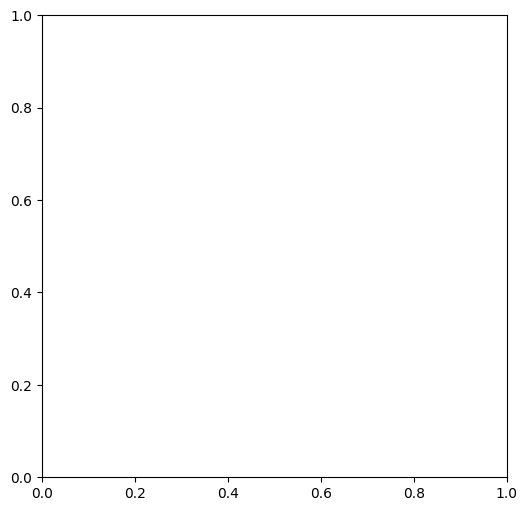

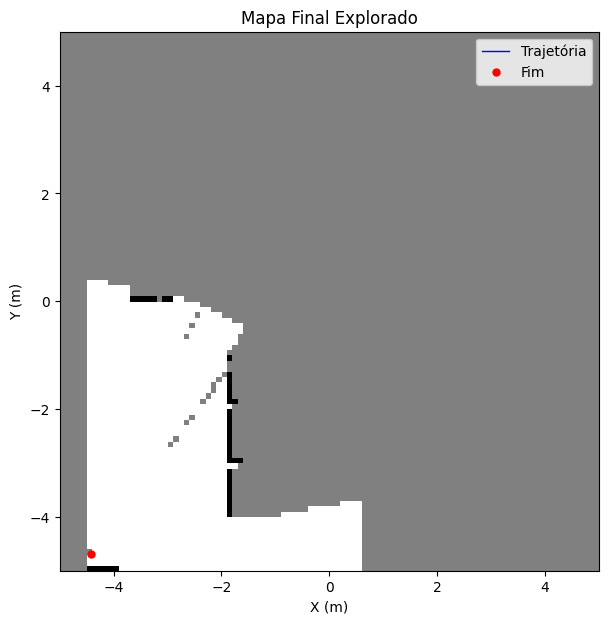

Gerando Plot 2 (Mapa de Grid)...


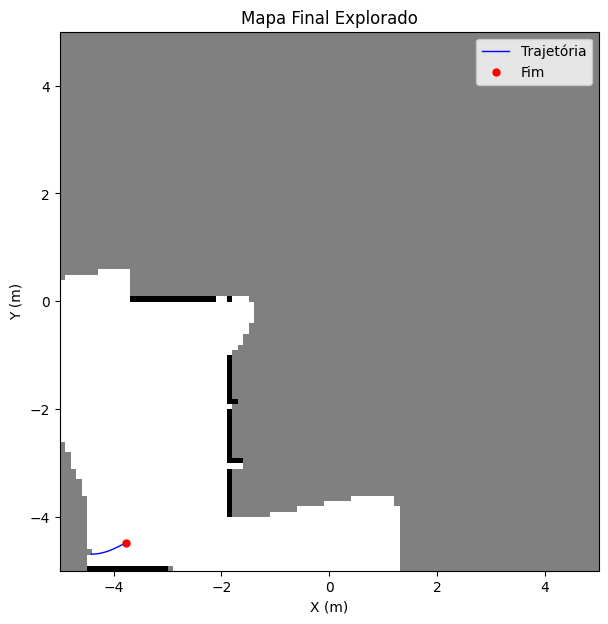

Gerando Plot 2 (Mapa de Grid)...


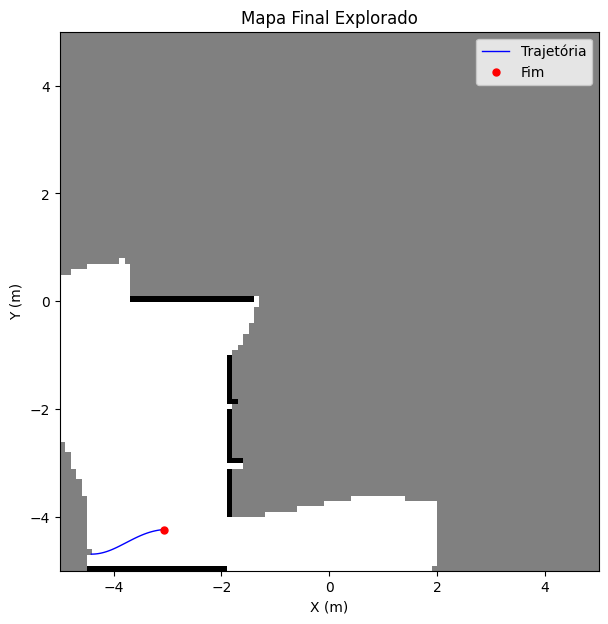

Gerando Plot 2 (Mapa de Grid)...


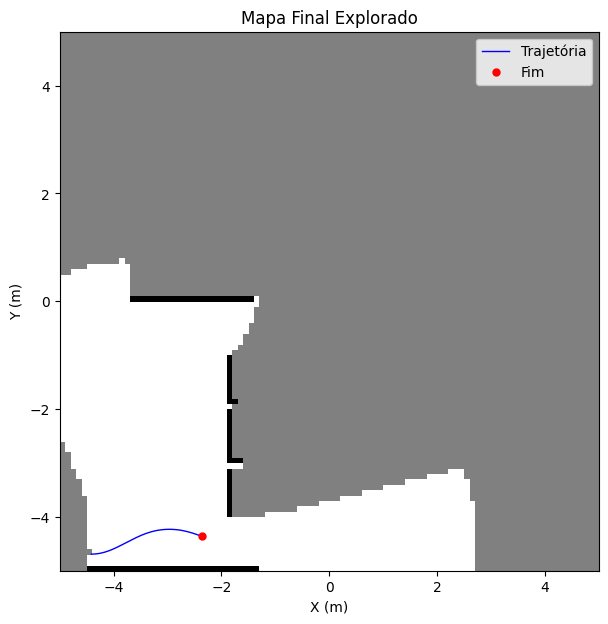

Gerando Plot 2 (Mapa de Grid)...


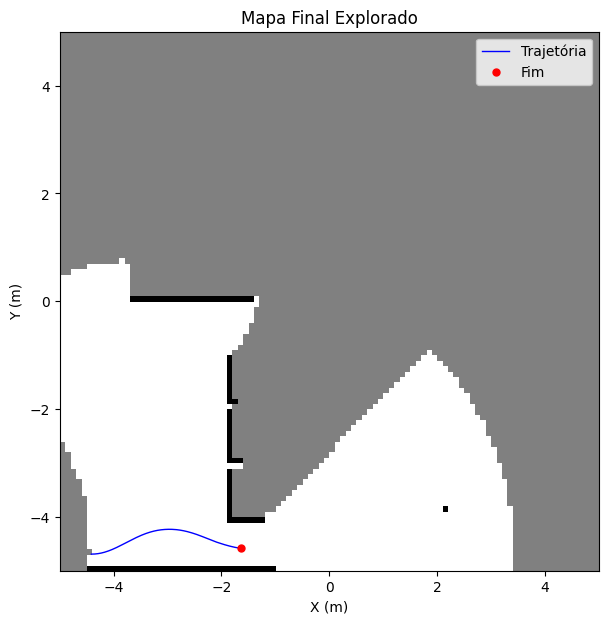

Gerando Plot 2 (Mapa de Grid)...


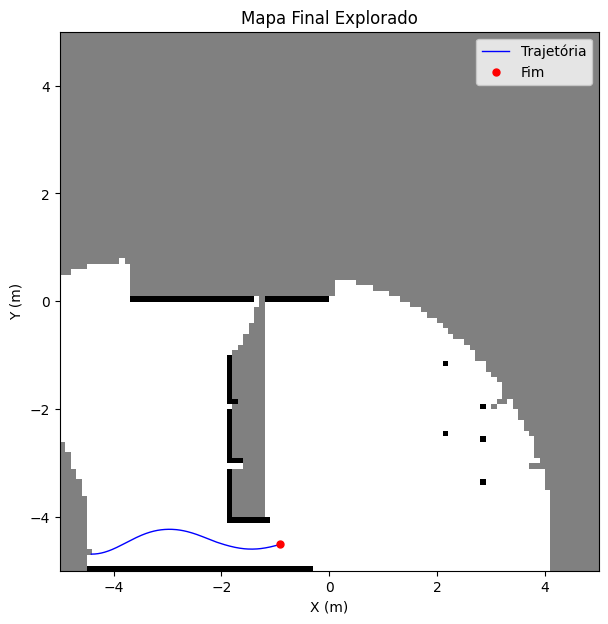

Gerando Plot 2 (Mapa de Grid)...


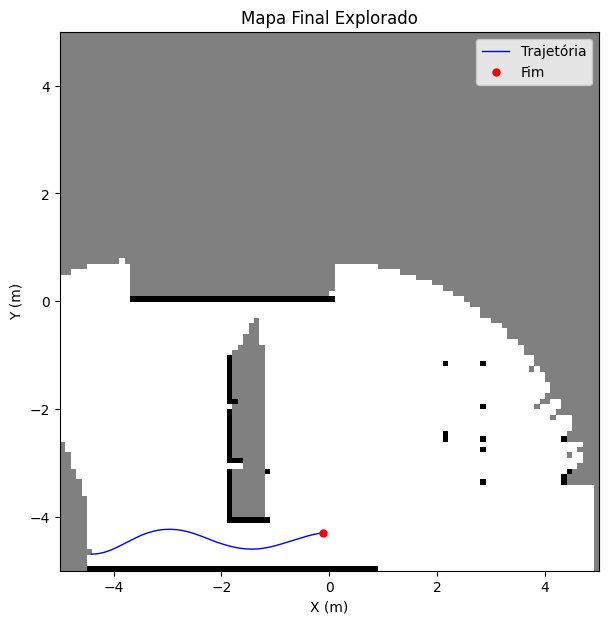

Gerando Plot 2 (Mapa de Grid)...


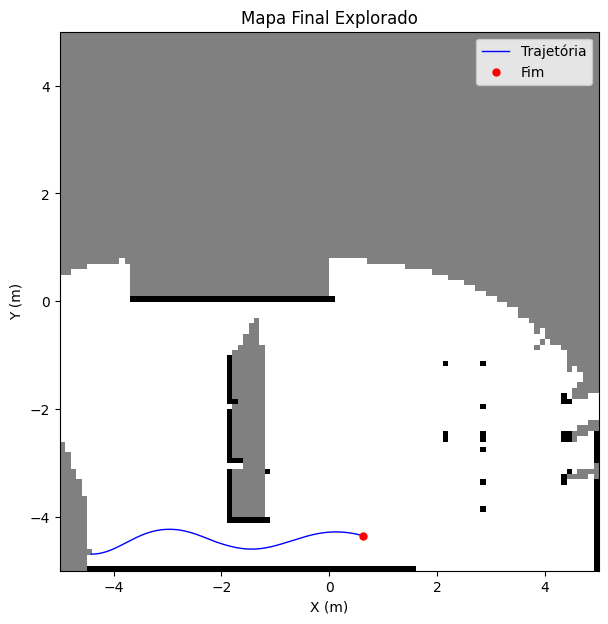

Gerando Plot 2 (Mapa de Grid)...


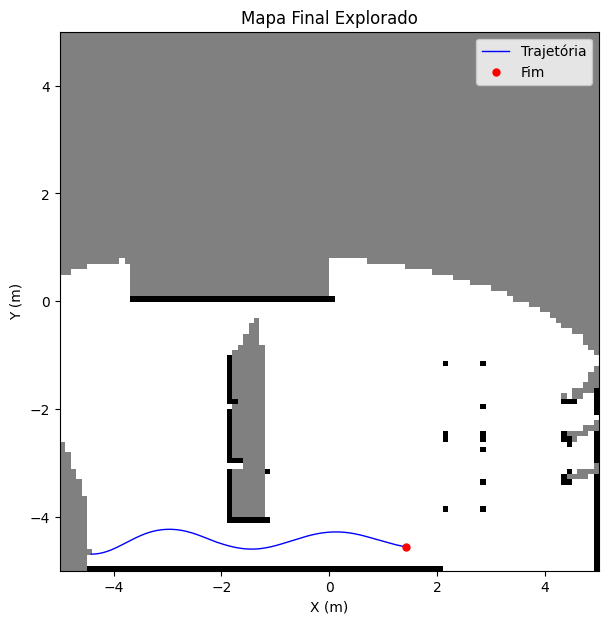

Gerando Plot 2 (Mapa de Grid)...


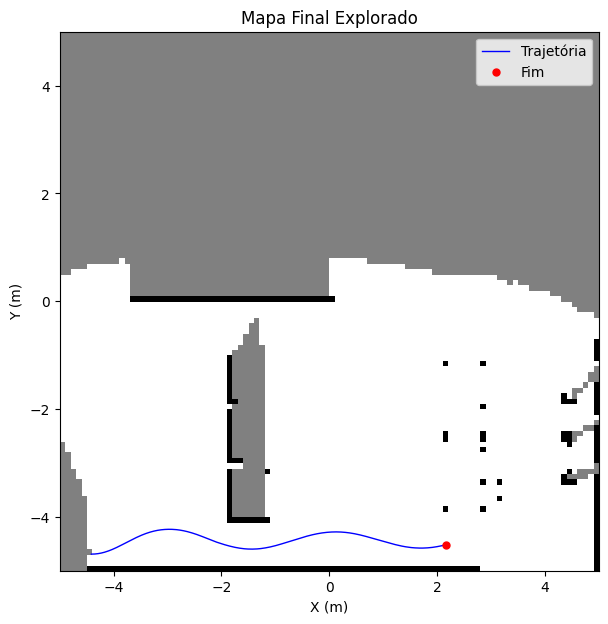

Gerando Plot 2 (Mapa de Grid)...


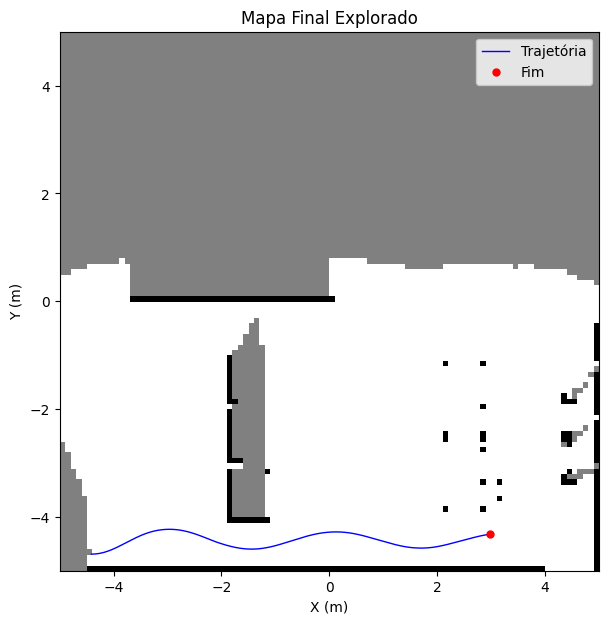

Gerando Plot 2 (Mapa de Grid)...


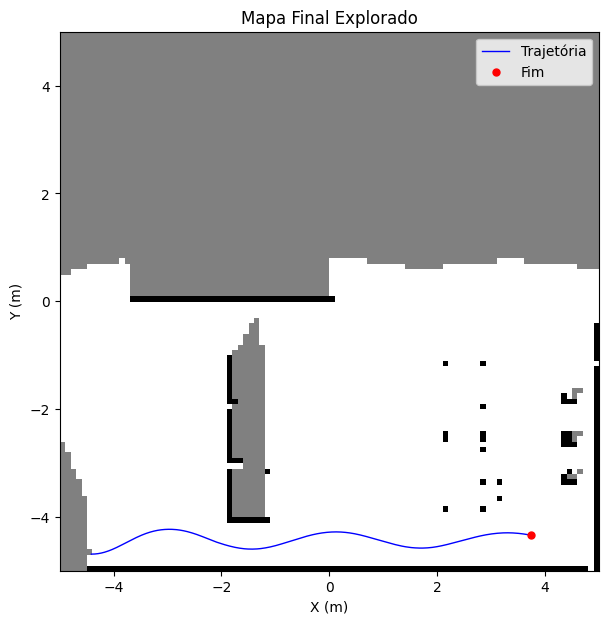

Gerando Plot 2 (Mapa de Grid)...


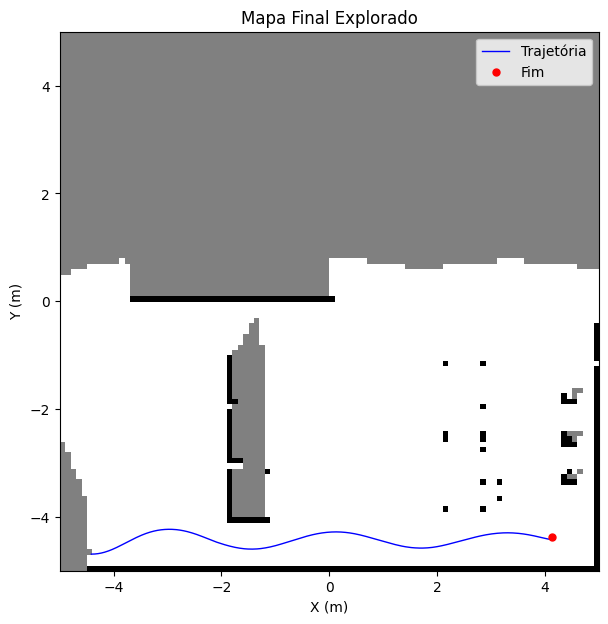

Gerando Plot 2 (Mapa de Grid)...


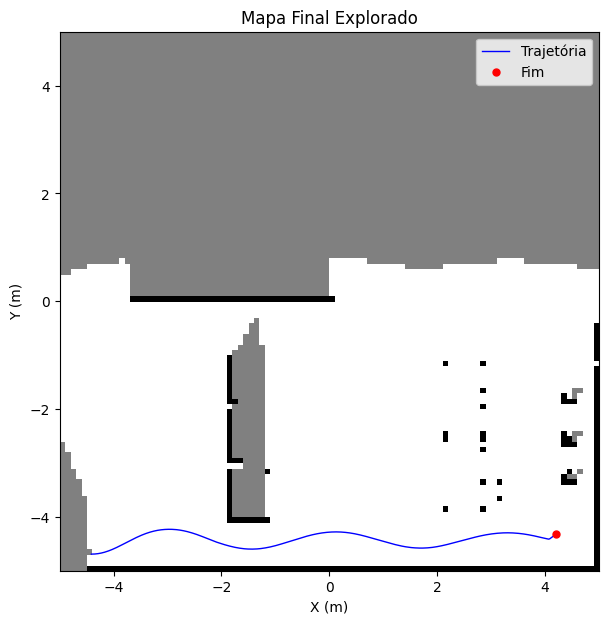

Gerando Plot 2 (Mapa de Grid)...


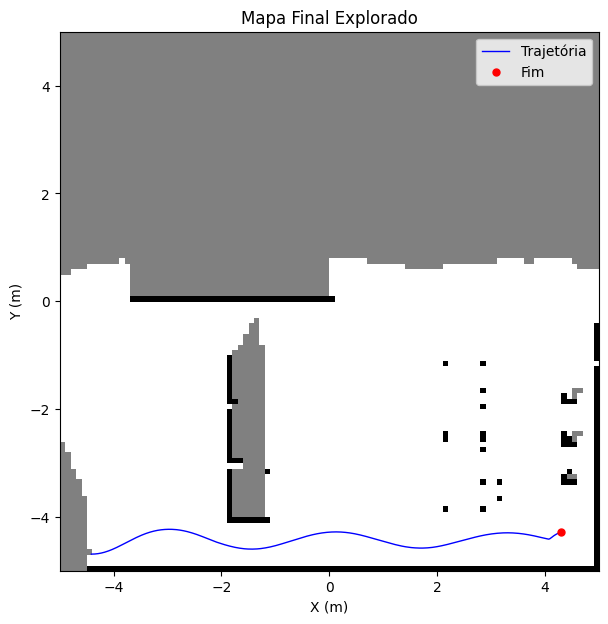

Gerando Plot 2 (Mapa de Grid)...


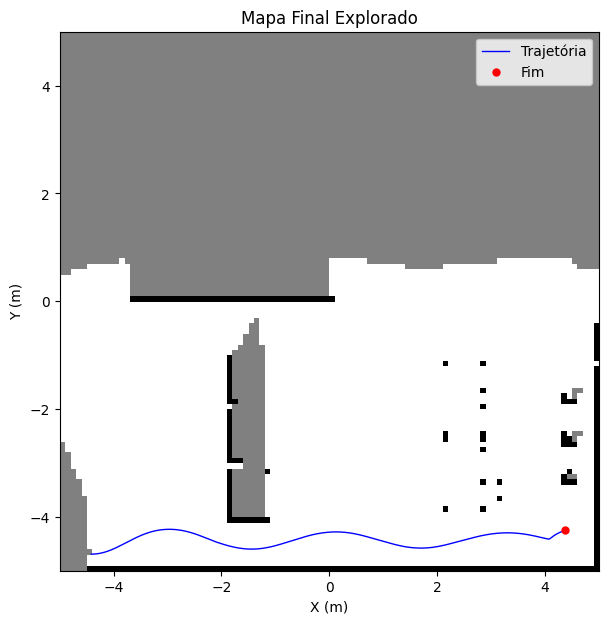

Gerando Plot 2 (Mapa de Grid)...


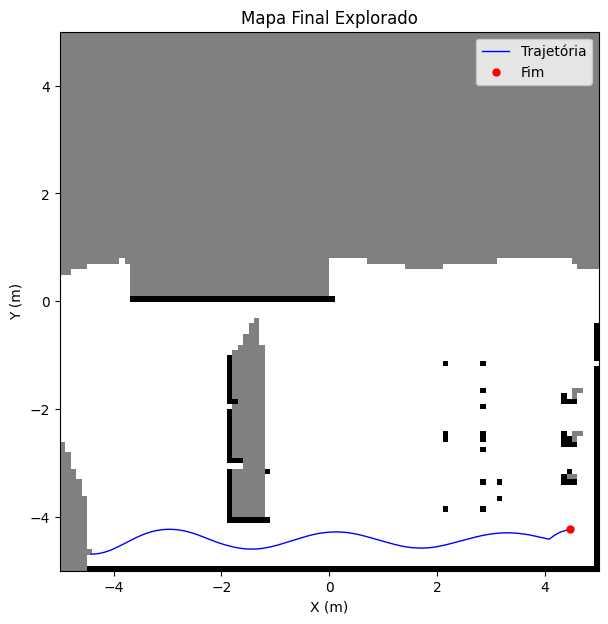

Gerando Plot 2 (Mapa de Grid)...


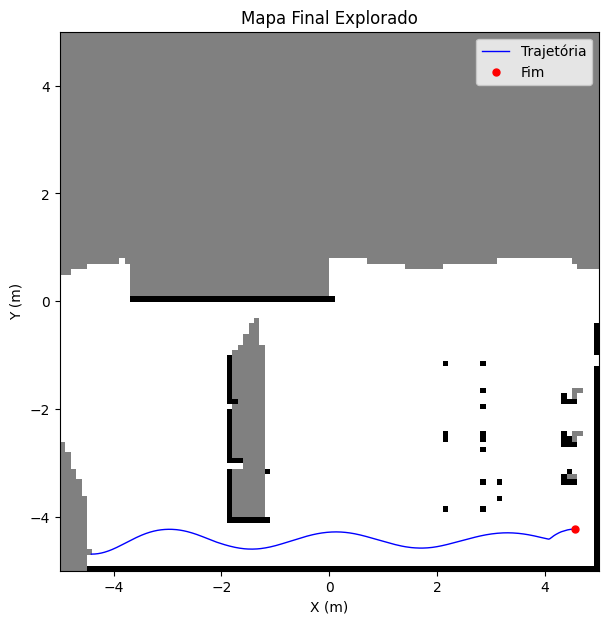

Gerando Plot 2 (Mapa de Grid)...


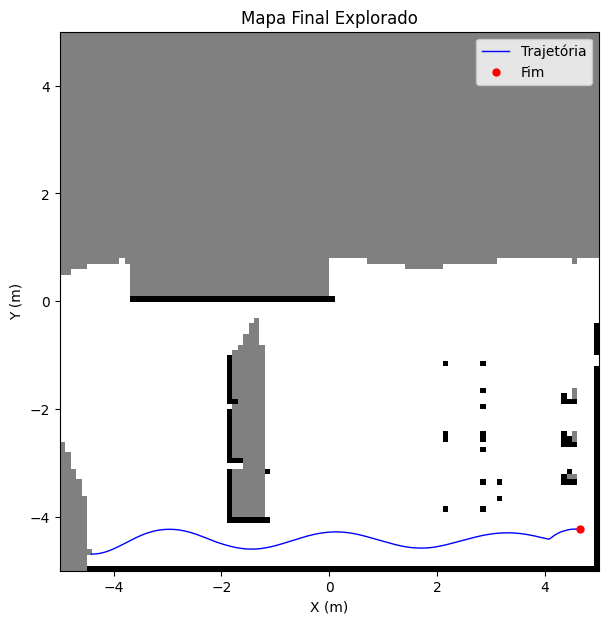

Gerando Plot 2 (Mapa de Grid)...


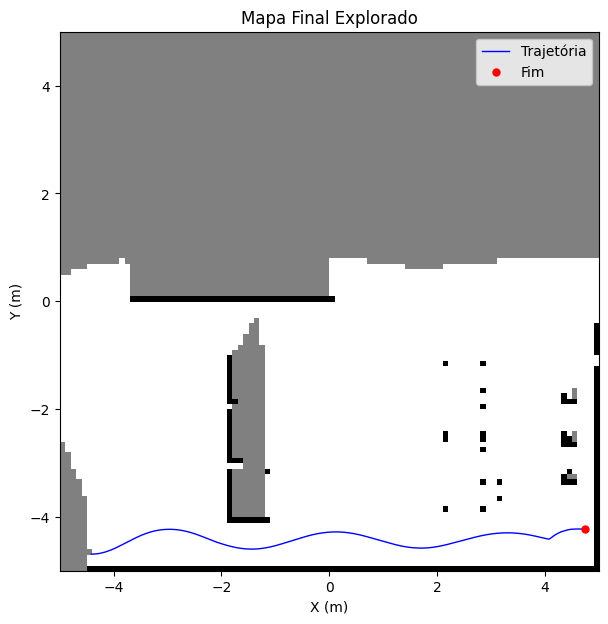

Gerando Plot 2 (Mapa de Grid)...


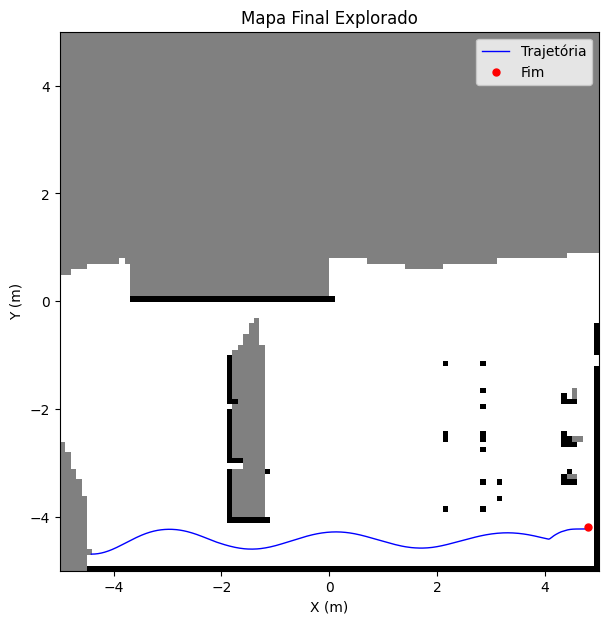

Gerando Plot 2 (Mapa de Grid)...


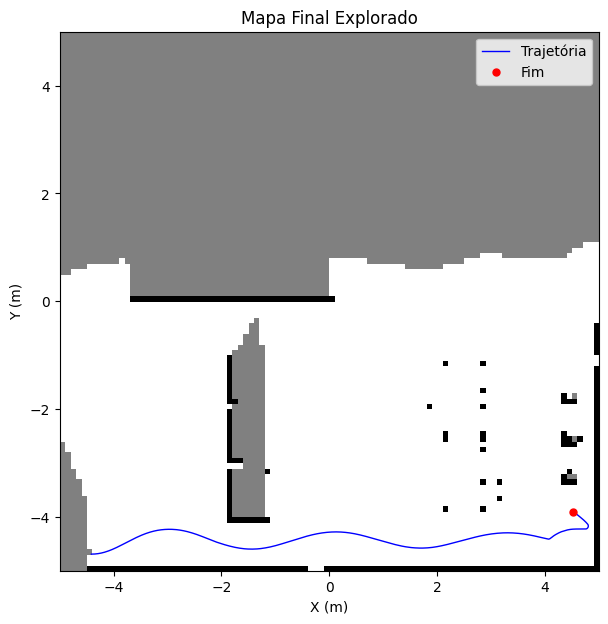

Gerando Plot 2 (Mapa de Grid)...


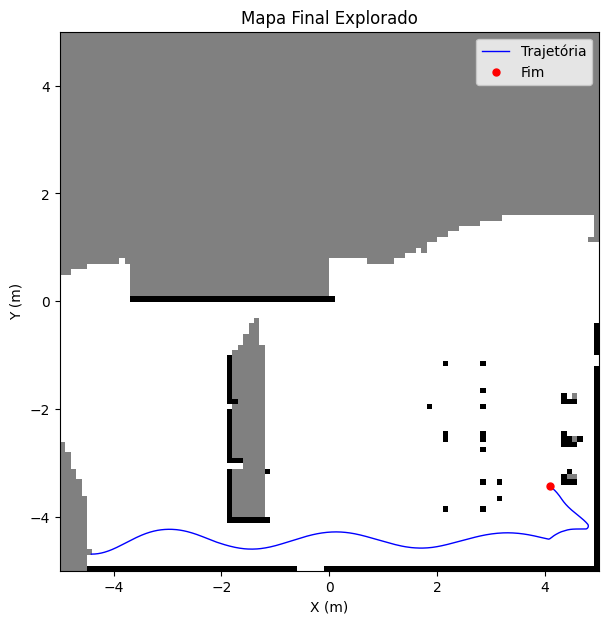

Gerando Plot 2 (Mapa de Grid)...


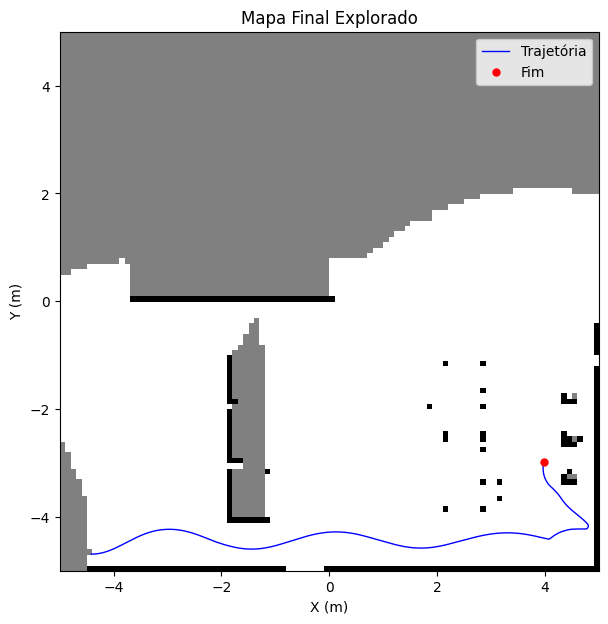

Gerando Plot 2 (Mapa de Grid)...


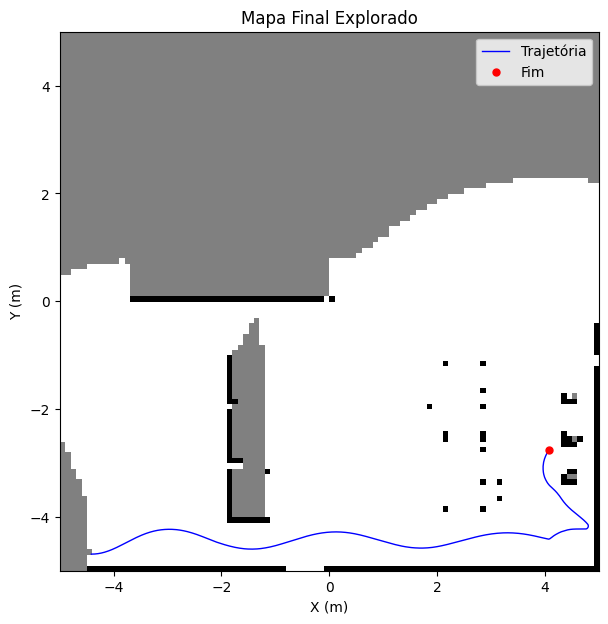

Gerando Plot 2 (Mapa de Grid)...


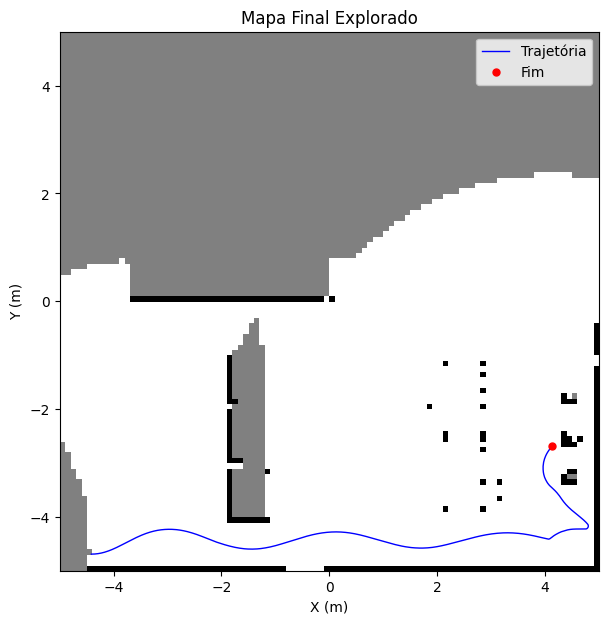

Gerando Plot 2 (Mapa de Grid)...


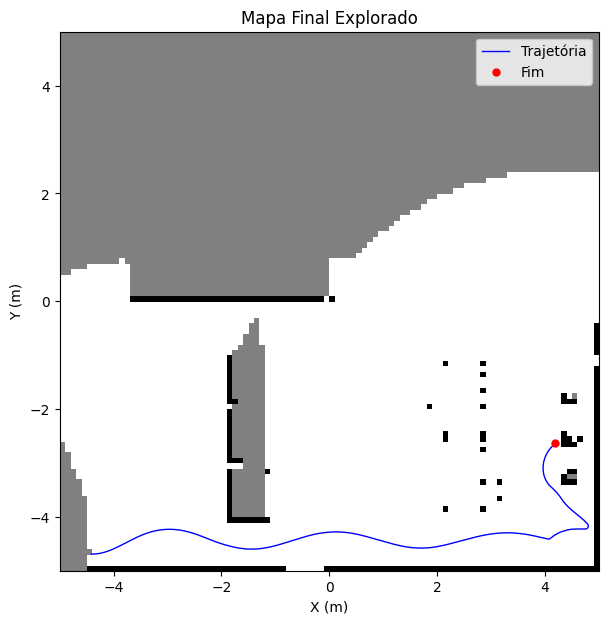

Gerando Plot 2 (Mapa de Grid)...


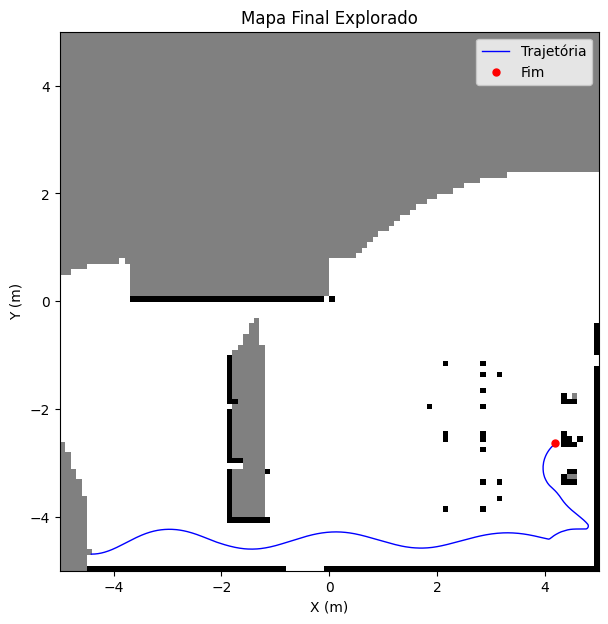

Gerando Plot 2 (Mapa de Grid)...


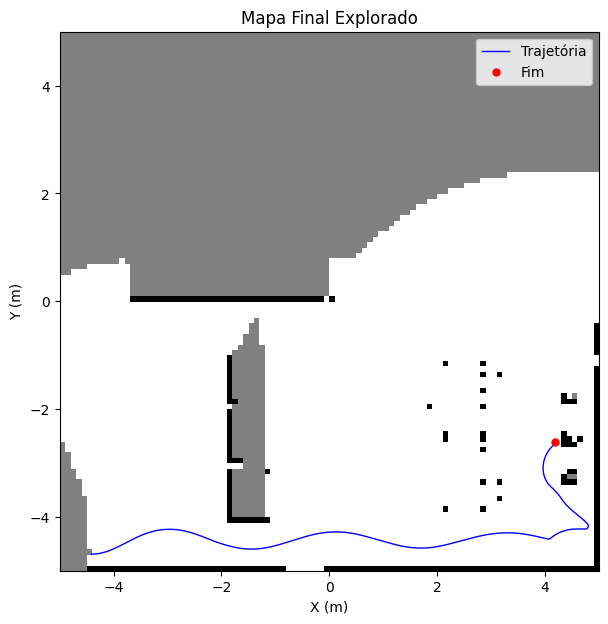

Gerando Plot 2 (Mapa de Grid)...


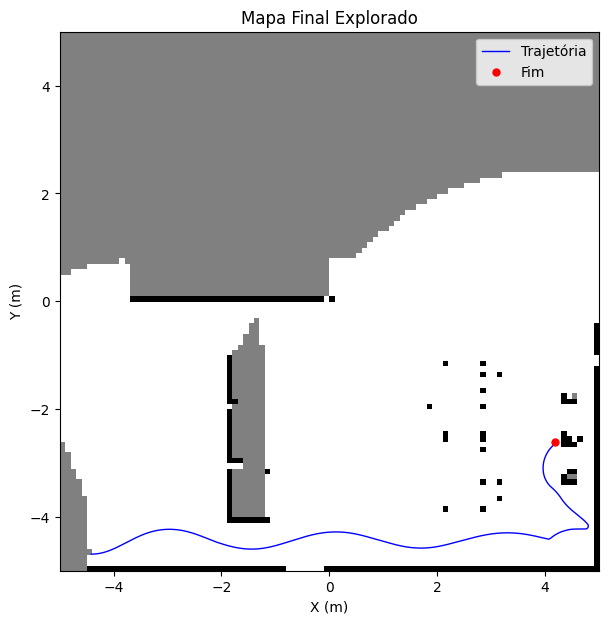

Gerando Plot 2 (Mapa de Grid)...


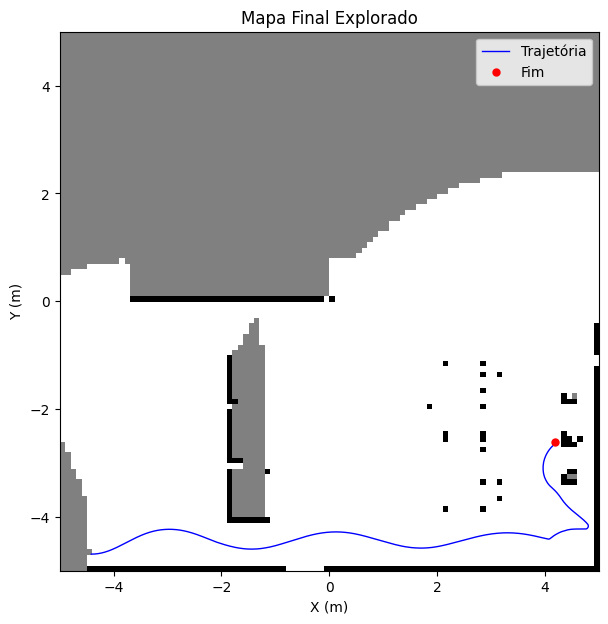

Gerando Plot 2 (Mapa de Grid)...


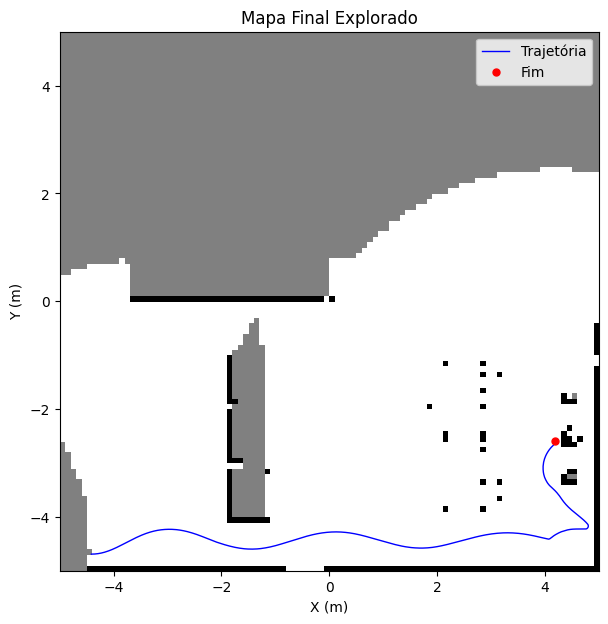

Gerando Plot 2 (Mapa de Grid)...


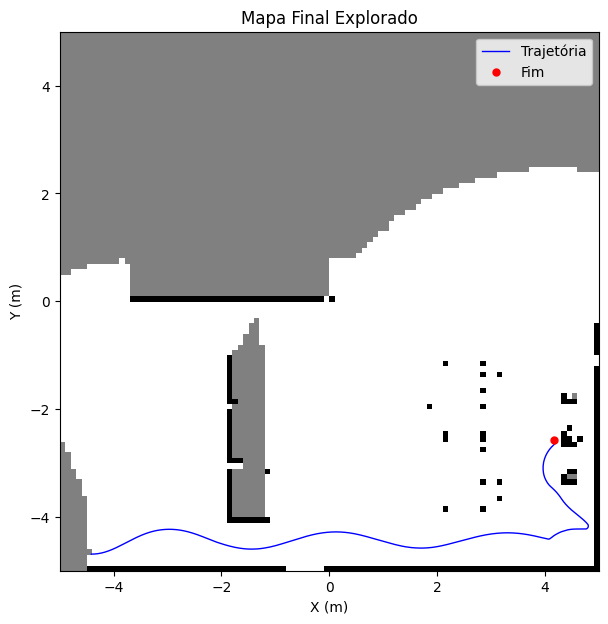

Gerando Plot 2 (Mapa de Grid)...


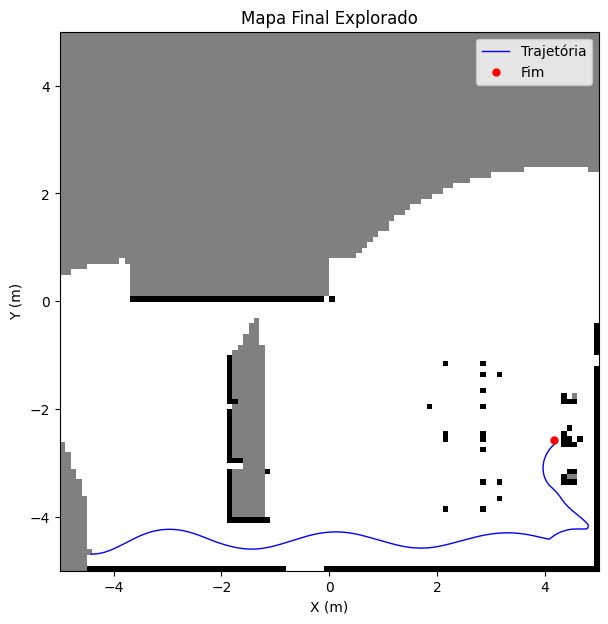

Gerando Plot 2 (Mapa de Grid)...


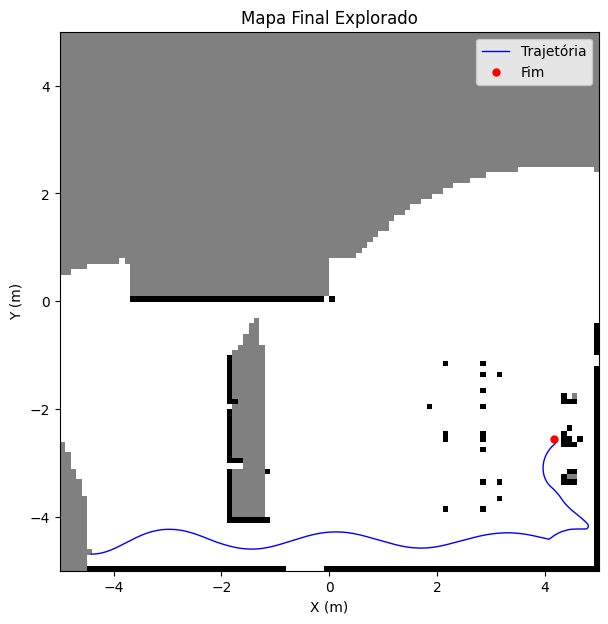

Gerando Plot 2 (Mapa de Grid)...


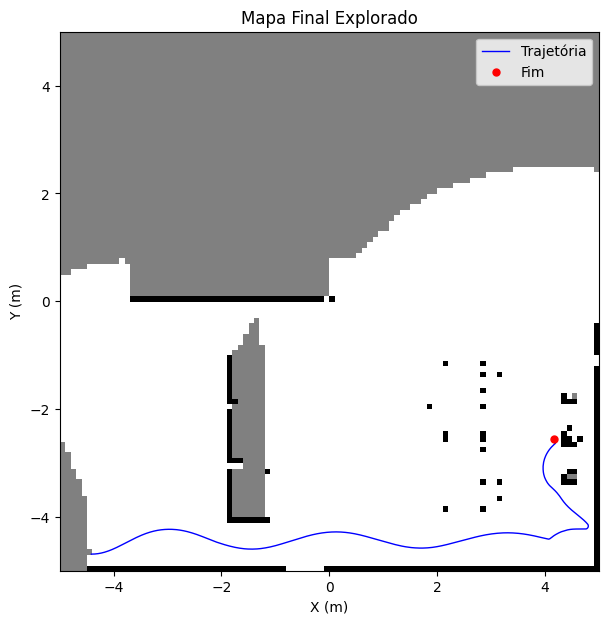

Gerando Plot 2 (Mapa de Grid)...


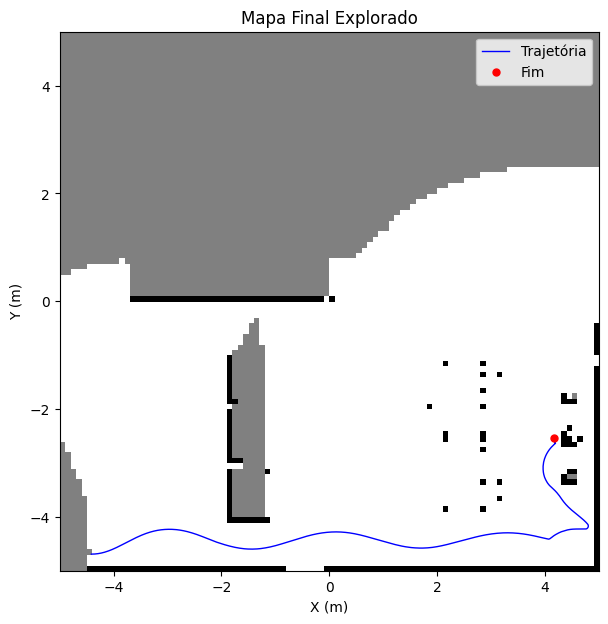

Gerando Plot 2 (Mapa de Grid)...


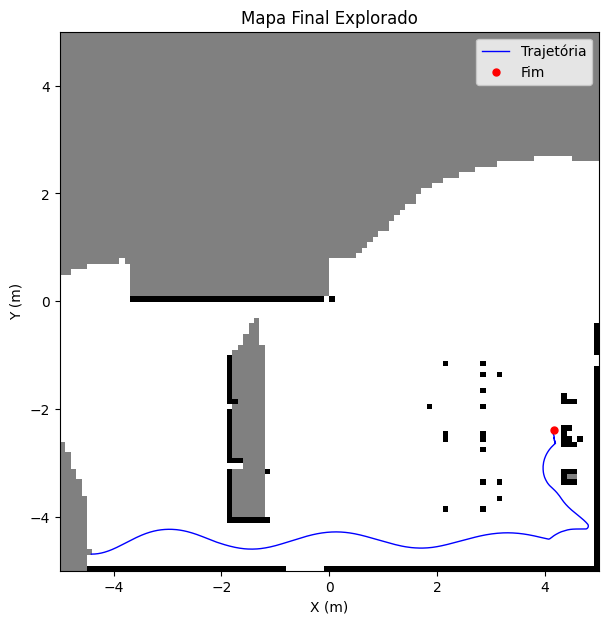

Gerando Plot 2 (Mapa de Grid)...


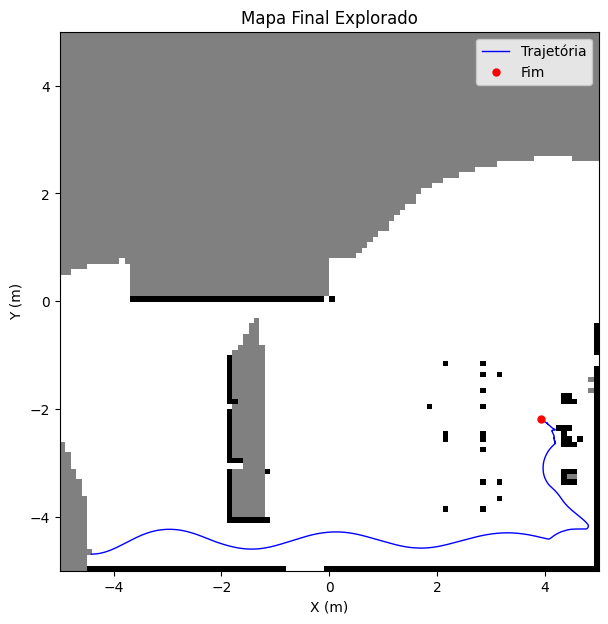

Gerando Plot 2 (Mapa de Grid)...


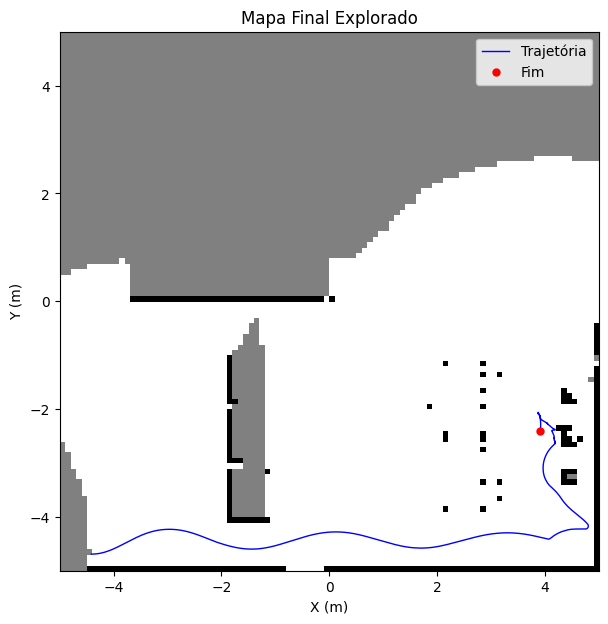

Gerando Plot 2 (Mapa de Grid)...


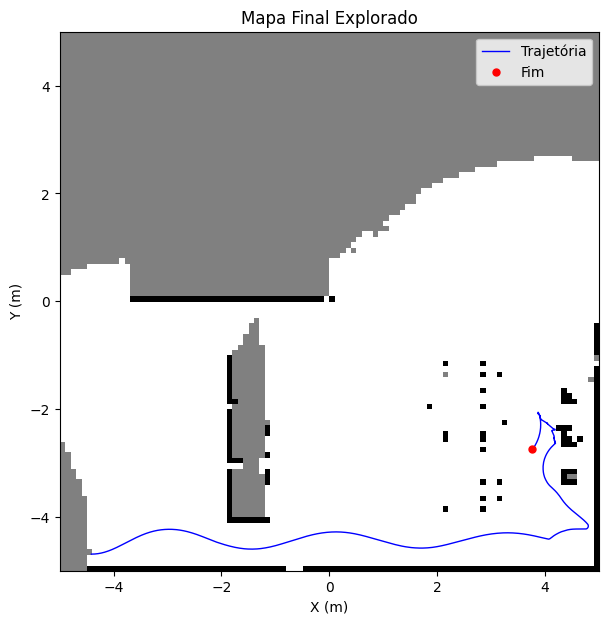

Gerando Plot 2 (Mapa de Grid)...


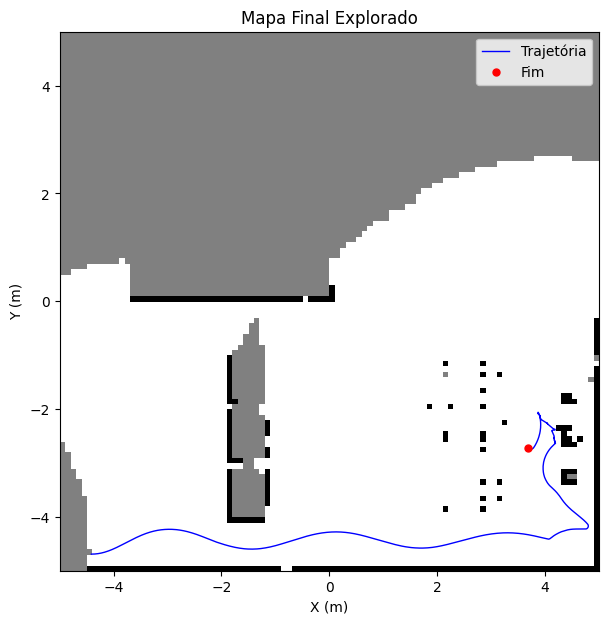

Gerando Plot 2 (Mapa de Grid)...


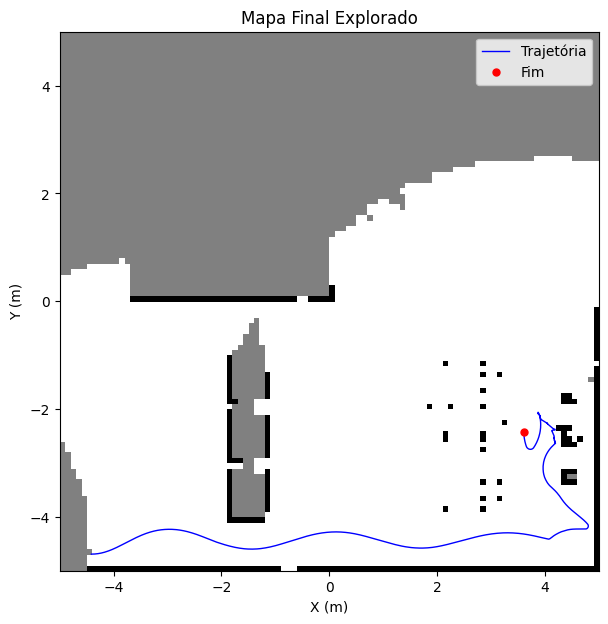

Gerando Plot 2 (Mapa de Grid)...


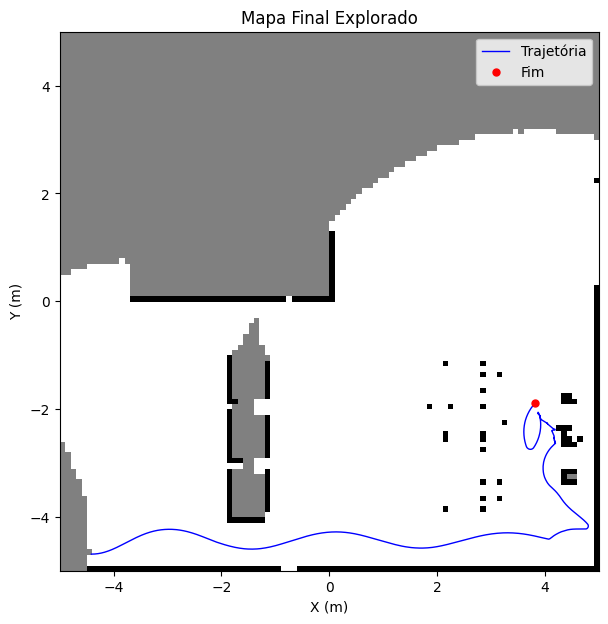

Gerando Plot 2 (Mapa de Grid)...


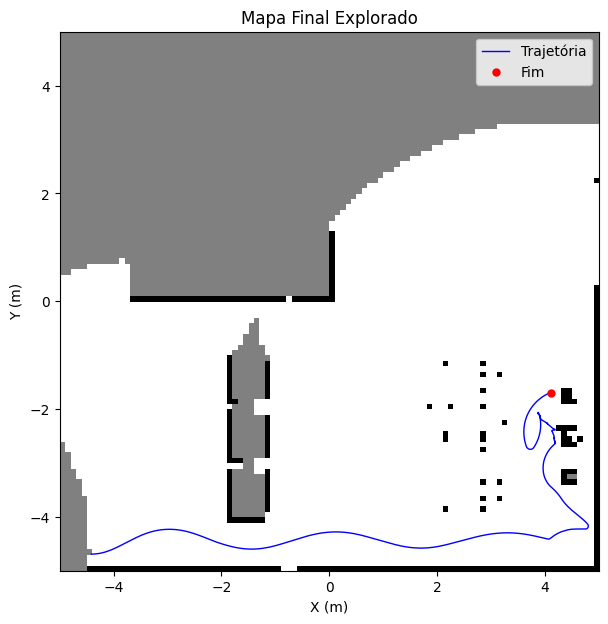

Gerando Plot 2 (Mapa de Grid)...


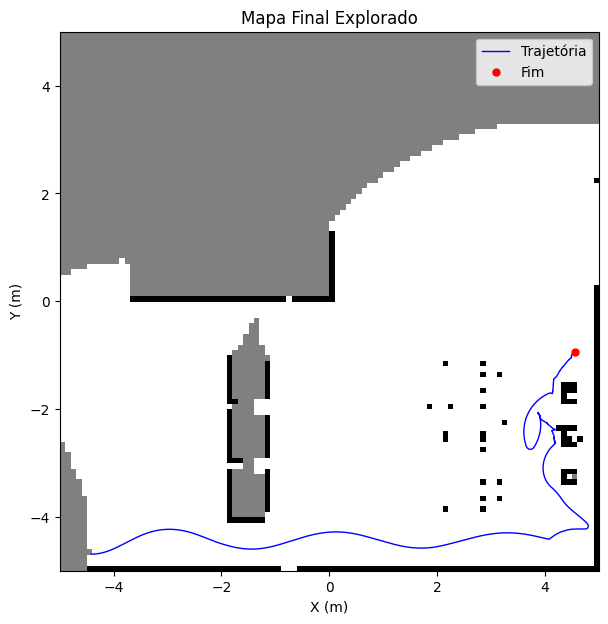

Gerando Plot 2 (Mapa de Grid)...


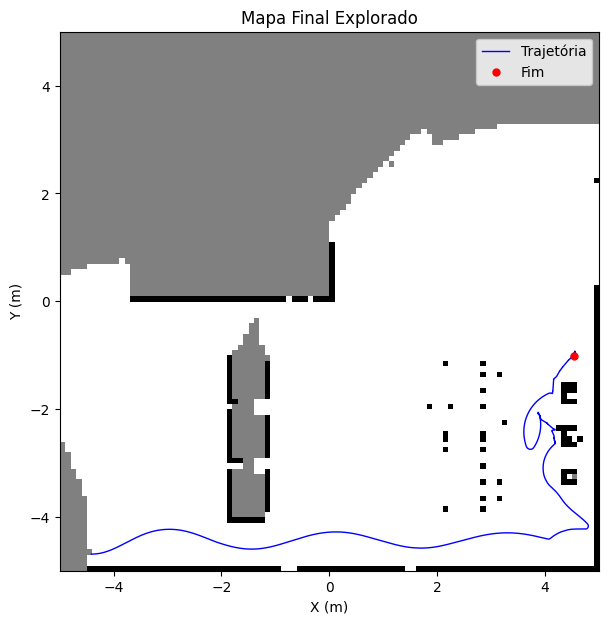

Gerando Plot 2 (Mapa de Grid)...


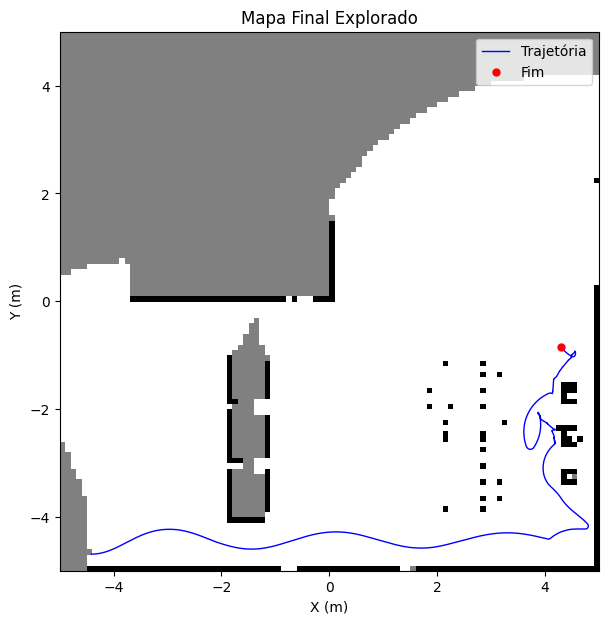

Gerando Plot 2 (Mapa de Grid)...


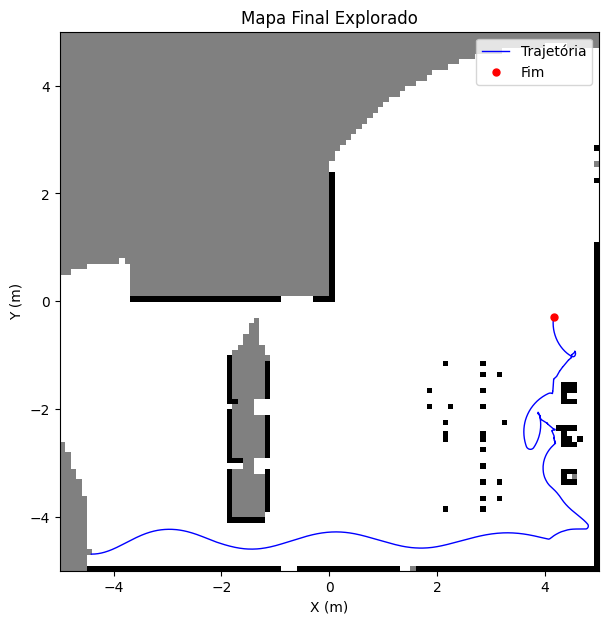

Gerando Plot 2 (Mapa de Grid)...


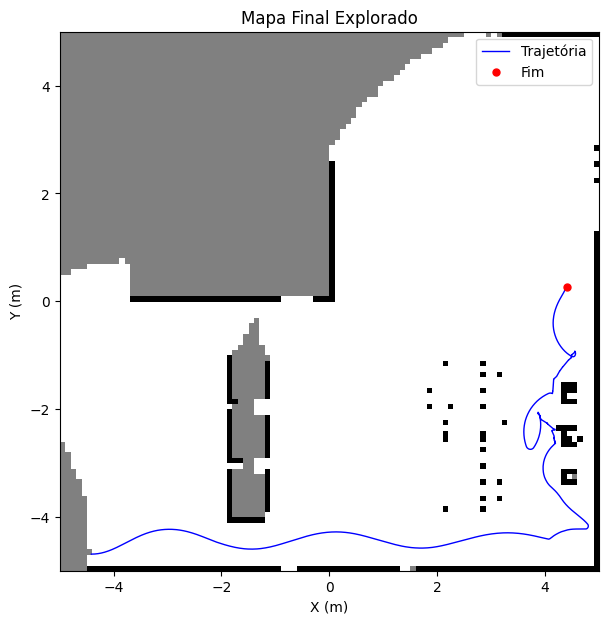

Gerando Plot 2 (Mapa de Grid)...


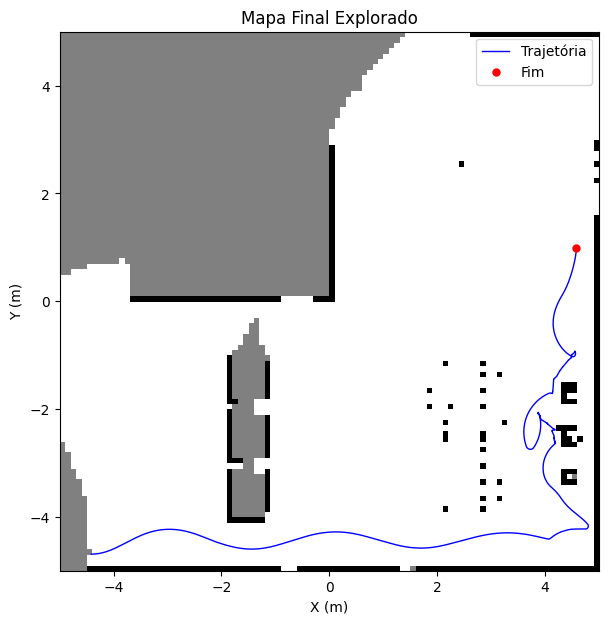

>> GATILHO ATINGIDO em x=4.59, y=1.01. Iniciando manobra.
>> MANOBRA: Virando à esquerda... (20)
>> MANOBRA: Virando à esquerda... (19)
>> MANOBRA: Virando à esquerda... (18)
>> MANOBRA: Virando à esquerda... (17)
>> MANOBRA: Virando à esquerda... (16)
>> MANOBRA: Virando à esquerda... (15)
>> MANOBRA: Virando à esquerda... (14)
>> MANOBRA: Virando à esquerda... (13)
>> MANOBRA: Virando à esquerda... (12)
>> MANOBRA: Virando à esquerda... (11)
>> MANOBRA: Virando à esquerda... (10)
>> MANOBRA: Virando à esquerda... (9)
>> MANOBRA: Virando à esquerda... (8)
>> MANOBRA: Virando à esquerda... (7)
>> MANOBRA: Virando à esquerda... (6)
>> MANOBRA: Virando à esquerda... (5)
>> MANOBRA: Virando à esquerda... (4)
>> MANOBRA: Virando à esquerda... (3)
>> MANOBRA: Virando à esquerda... (2)
>> MANOBRA: Virando à esquerda... (1)
>> MANOBRA: Virada 1 completa. Seguindo reto.
>> MANOBRA: Seguindo reto... (X atual: 4.59)
>> MANOBRA: Seguindo reto... (X atual: 4.59)
>> MANOBRA: Seguindo reto... (X atu

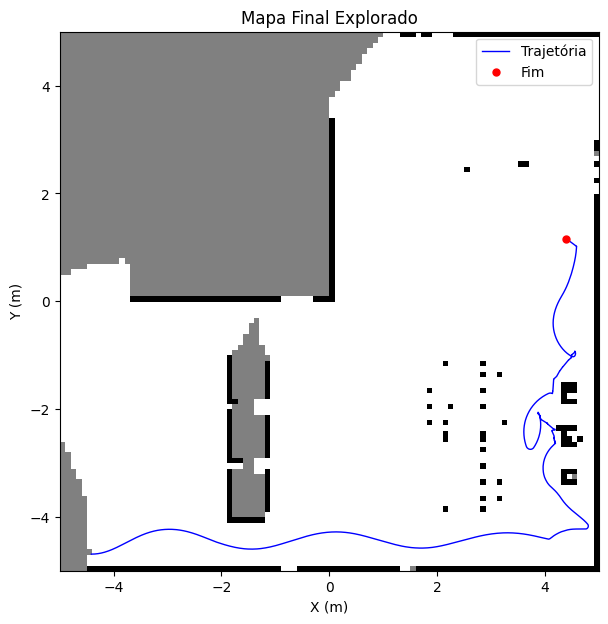

>> MANOBRA: Seguindo reto... (X atual: 4.39)
>> MANOBRA: Seguindo reto... (X atual: 4.38)
>> MANOBRA: Seguindo reto... (X atual: 4.38)
>> MANOBRA: Seguindo reto... (X atual: 4.37)
>> MANOBRA: Seguindo reto... (X atual: 4.36)
>> MANOBRA: Seguindo reto... (X atual: 4.35)
>> MANOBRA: Seguindo reto... (X atual: 4.35)
>> MANOBRA: Seguindo reto... (X atual: 4.34)
>> MANOBRA: Seguindo reto... (X atual: 4.33)
>> MANOBRA: Seguindo reto... (X atual: 4.33)
>> MANOBRA: Seguindo reto... (X atual: 4.32)
>> MANOBRA: Seguindo reto... (X atual: 4.31)
>> MANOBRA: Seguindo reto... (X atual: 4.31)
>> MANOBRA: Seguindo reto... (X atual: 4.30)
>> MANOBRA: Seguindo reto... (X atual: 4.29)
>> MANOBRA: Seguindo reto... (X atual: 4.28)
>> MANOBRA: Seguindo reto... (X atual: 4.28)
>> MANOBRA: Seguindo reto... (X atual: 4.27)
>> MANOBRA: Seguindo reto... (X atual: 4.26)
>> MANOBRA: Seguindo reto... (X atual: 4.25)
>> MANOBRA: Seguindo reto... (X atual: 4.25)
>> MANOBRA: Seguindo reto... (X atual: 4.24)
>> MANOBRA

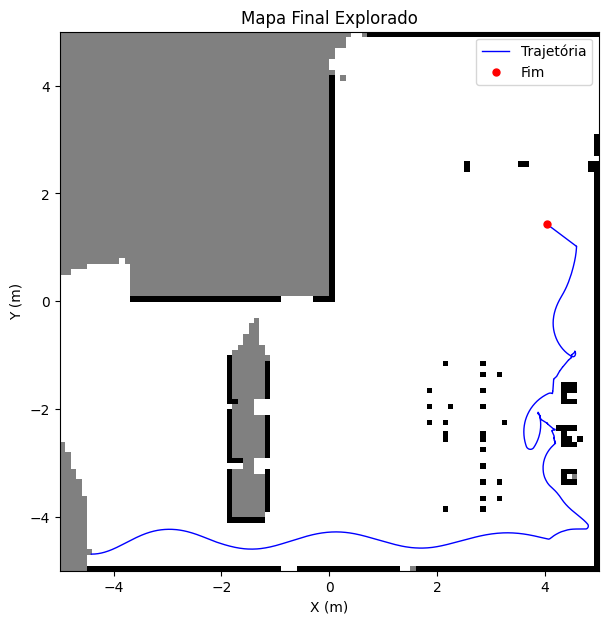

>> MANOBRA: Seguindo reto... (X atual: 4.03)
>> MANOBRA: Seguindo reto... (X atual: 4.02)
>> MANOBRA: Seguindo reto... (X atual: 4.02)
>> MANOBRA: Seguindo reto... (X atual: 4.01)
>> MANOBRA: Seguindo reto... (X atual: 4.00)
>> MANOBRA: Seguindo reto... (X atual: 4.00)
>> MANOBRA: Seguindo reto... (X atual: 3.99)
>> MANOBRA: Seguindo reto... (X atual: 3.98)
>> MANOBRA: Seguindo reto... (X atual: 3.97)
>> MANOBRA: Seguindo reto... (X atual: 3.97)
>> MANOBRA: Seguindo reto... (X atual: 3.96)
>> MANOBRA: Seguindo reto... (X atual: 3.95)
>> MANOBRA: Seguindo reto... (X atual: 3.94)
>> MANOBRA: Seguindo reto... (X atual: 3.94)
>> MANOBRA: Seguindo reto... (X atual: 3.93)
>> MANOBRA: Seguindo reto... (X atual: 3.92)
>> MANOBRA: Seguindo reto... (X atual: 3.92)
>> MANOBRA: Seguindo reto... (X atual: 3.91)
>> MANOBRA: Seguindo reto... (X atual: 3.90)
>> MANOBRA: Seguindo reto... (X atual: 3.89)
>> MANOBRA: Seguindo reto... (X atual: 3.89)
>> MANOBRA: Seguindo reto... (X atual: 3.88)
>> MANOBRA

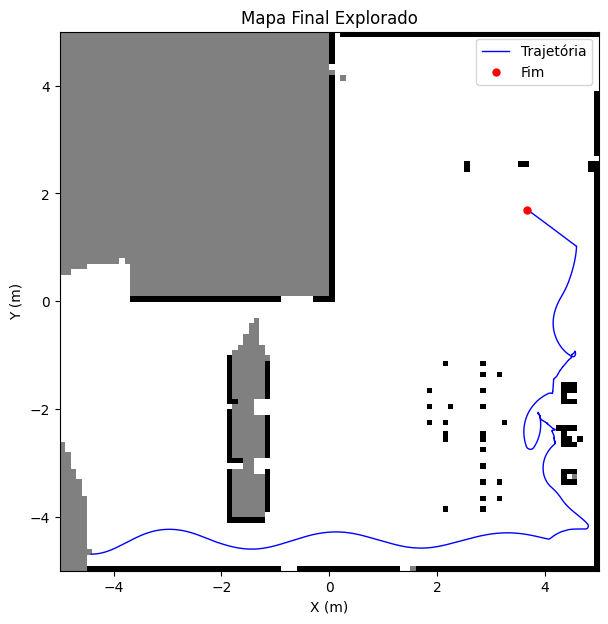

>> MANOBRA: Seguindo reto... (X atual: 3.67)
>> MANOBRA: Seguindo reto... (X atual: 3.66)
>> MANOBRA: Seguindo reto... (X atual: 3.66)
>> MANOBRA: Seguindo reto... (X atual: 3.65)
>> MANOBRA: Seguindo reto... (X atual: 3.64)
>> MANOBRA: Seguindo reto... (X atual: 3.63)
>> MANOBRA: Seguindo reto... (X atual: 3.63)
>> MANOBRA: Seguindo reto... (X atual: 3.62)
>> MANOBRA: Seguindo reto... (X atual: 3.61)
>> MANOBRA: Seguindo reto... (X atual: 3.60)
>> MANOBRA: Seguindo reto... (X atual: 3.60)
>> MANOBRA: Seguindo reto... (X atual: 3.59)
>> MANOBRA: Seguindo reto... (X atual: 3.58)
>> MANOBRA: Seguindo reto... (X atual: 3.58)
>> MANOBRA: Seguindo reto... (X atual: 3.57)
>> MANOBRA: Seguindo reto... (X atual: 3.56)
>> MANOBRA: Seguindo reto... (X atual: 3.55)
>> MANOBRA: Seguindo reto... (X atual: 3.55)
>> MANOBRA: Seguindo reto... (X atual: 3.54)
>> MANOBRA: Seguindo reto... (X atual: 3.53)
>> MANOBRA: Seguindo reto... (X atual: 3.52)
>> MANOBRA: Seguindo reto... (X atual: 3.52)
>> MANOBRA

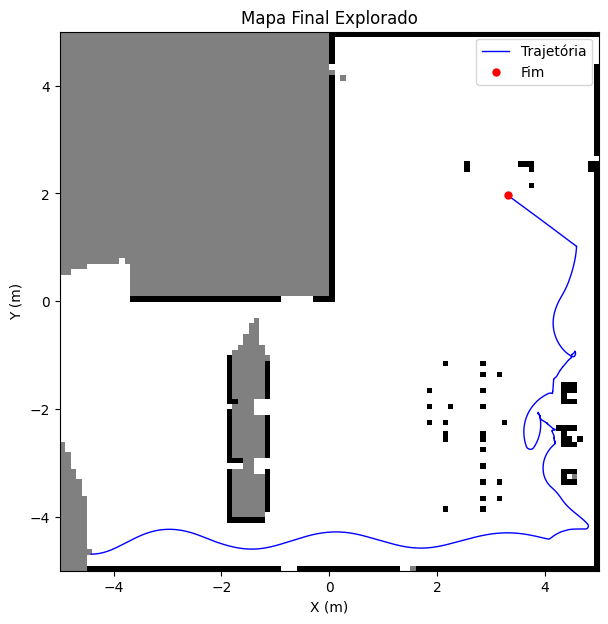

>> MANOBRA: Seguindo reto... (X atual: 3.31)
>> MANOBRA: Seguindo reto... (X atual: 3.30)
>> MANOBRA: Seguindo reto... (X atual: 3.29)
>> MANOBRA: Seguindo reto... (X atual: 3.29)
>> MANOBRA: Seguindo reto... (X atual: 3.28)
>> MANOBRA: Seguindo reto... (X atual: 3.27)
>> MANOBRA: Seguindo reto... (X atual: 3.27)
>> MANOBRA: Seguindo reto... (X atual: 3.26)
>> MANOBRA: Seguindo reto... (X atual: 3.25)
>> MANOBRA: Seguindo reto... (X atual: 3.24)
>> MANOBRA: Seguindo reto... (X atual: 3.24)
>> MANOBRA: Seguindo reto... (X atual: 3.23)
>> MANOBRA: Seguindo reto... (X atual: 3.23)
>> MANOBRA: Seguindo reto... (X atual: 3.22)
>> MANOBRA: Seguindo reto... (X atual: 3.22)
>> MANOBRA: Seguindo reto... (X atual: 3.21)
>> MANOBRA: Seguindo reto... (X atual: 3.21)
>> MANOBRA: Seguindo reto... (X atual: 3.20)
>> MANOBRA: Seguindo reto... (X atual: 3.20)
>> MANOBRA: Seguindo reto... (X atual: 3.19)
>> MANOBRA: Seguindo reto... (X atual: 3.19)
>> MANOBRA: Seguindo reto... (X atual: 3.18)
>> MANOBRA

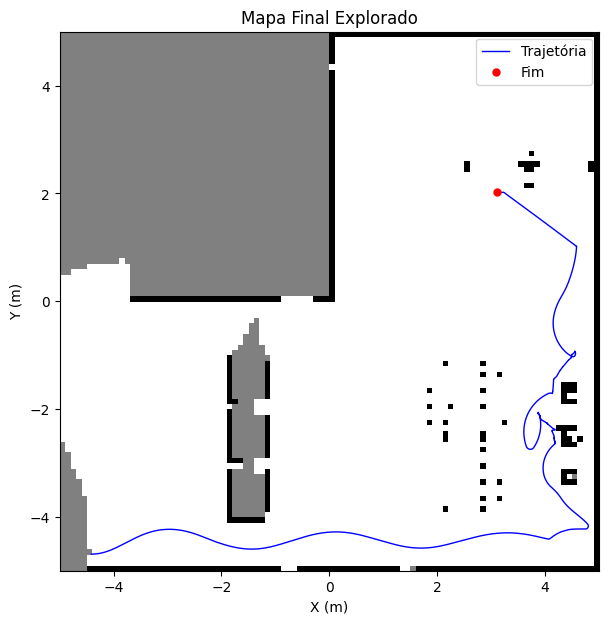

>> MANOBRA: Seguindo reto... (X atual: 3.05)
>> MANOBRA: Seguindo reto... (X atual: 3.05)
>> MANOBRA: Seguindo reto... (X atual: 3.05)
>> MANOBRA: Seguindo reto... (X atual: 3.05)
>> MANOBRA: Seguindo reto... (X atual: 2.94)
>> MANOBRA: Seguindo reto... (X atual: 2.94)
>> MANOBRA: Seguindo reto... (X atual: 2.94)
>> MANOBRA: Seguindo reto... (X atual: 2.94)
>> MANOBRA: Seguindo reto... (X atual: 2.42)
>> MANOBRA: Seguindo reto... (X atual: 2.42)
>> MANOBRA: Seguindo reto... (X atual: 2.28)
>> MANOBRA: Seguindo reto... (X atual: 2.28)
>> MANOBRA: Seguindo reto... (X atual: 2.28)
>> MANOBRA: Seguindo reto... (X atual: 2.28)
>> MANOBRA: Seguindo reto... (X atual: 2.28)
>> MANOBRA: Seguindo reto... (X atual: 2.28)
>> MANOBRA: Seguindo reto... (X atual: 2.27)
>> MANOBRA: Seguindo reto... (X atual: 2.27)
>> MANOBRA: Seguindo reto... (X atual: 1.93)
>> MANOBRA: Seguindo reto... (X atual: 1.93)
>> MANOBRA: Seguindo reto... (X atual: 1.93)
>> MANOBRA: Seguindo reto... (X atual: 1.93)
>> MANOBRA

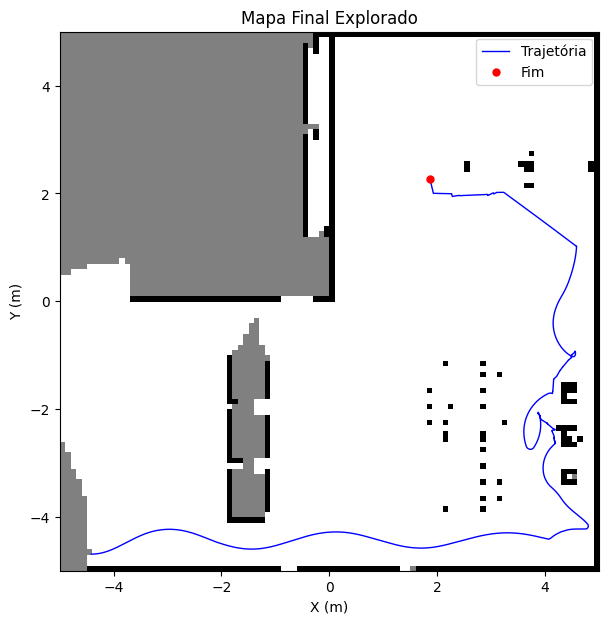

>> MANOBRA: Seguindo reto... (X atual: 1.87)
>> MANOBRA: Seguindo reto... (X atual: 1.87)
>> MANOBRA: Seguindo reto... (X atual: 1.86)
>> MANOBRA: Seguindo reto... (X atual: 1.86)
>> MANOBRA: Seguindo reto... (X atual: 1.86)
>> MANOBRA: Seguindo reto... (X atual: 1.86)
>> MANOBRA: Seguindo reto... (X atual: 1.86)
>> MANOBRA: Seguindo reto... (X atual: 1.85)
>> MANOBRA: Seguindo reto... (X atual: 1.85)
>> MANOBRA: Seguindo reto... (X atual: 1.85)
>> MANOBRA: Seguindo reto... (X atual: 1.85)
>> MANOBRA: Seguindo reto... (X atual: 1.85)
>> MANOBRA: Seguindo reto... (X atual: 1.84)
>> MANOBRA: Seguindo reto... (X atual: 1.84)
>> MANOBRA: Seguindo reto... (X atual: 1.84)
>> MANOBRA: Seguindo reto... (X atual: 1.84)
>> MANOBRA: Seguindo reto... (X atual: 1.83)
>> MANOBRA: Seguindo reto... (X atual: 1.83)
>> MANOBRA: Seguindo reto... (X atual: 1.83)
>> MANOBRA: Seguindo reto... (X atual: 1.83)
>> MANOBRA: Seguindo reto... (X atual: 1.83)
>> MANOBRA: Seguindo reto... (X atual: 1.82)
>> MANOBRA

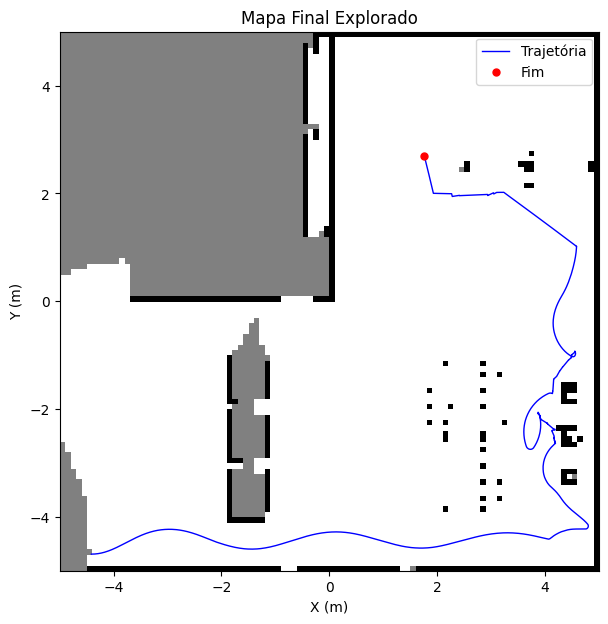

>> MANOBRA: Seguindo reto... (X atual: 1.76)
>> MANOBRA: Seguindo reto... (X atual: 1.76)
>> MANOBRA: Seguindo reto... (X atual: 1.76)
>> MANOBRA: Seguindo reto... (X atual: 1.75)
>> MANOBRA: Seguindo reto... (X atual: 1.75)
>> MANOBRA: Seguindo reto... (X atual: 1.75)
>> MANOBRA: Seguindo reto... (X atual: 1.75)
>> MANOBRA: Seguindo reto... (X atual: 1.75)
>> MANOBRA: Seguindo reto... (X atual: 1.74)
>> MANOBRA: Seguindo reto... (X atual: 1.74)
>> MANOBRA: Seguindo reto... (X atual: 1.74)
>> MANOBRA: Seguindo reto... (X atual: 1.74)
>> MANOBRA: Seguindo reto... (X atual: 1.74)
>> MANOBRA: Seguindo reto... (X atual: 1.73)
>> MANOBRA: Seguindo reto... (X atual: 1.73)
>> MANOBRA: Seguindo reto... (X atual: 1.73)
>> MANOBRA: Seguindo reto... (X atual: 1.73)
>> MANOBRA: Seguindo reto... (X atual: 1.72)
>> MANOBRA: Seguindo reto... (X atual: 1.72)
>> MANOBRA: Seguindo reto... (X atual: 1.72)
>> MANOBRA: Seguindo reto... (X atual: 1.72)
>> MANOBRA: Seguindo reto... (X atual: 1.72)
>> MANOBRA

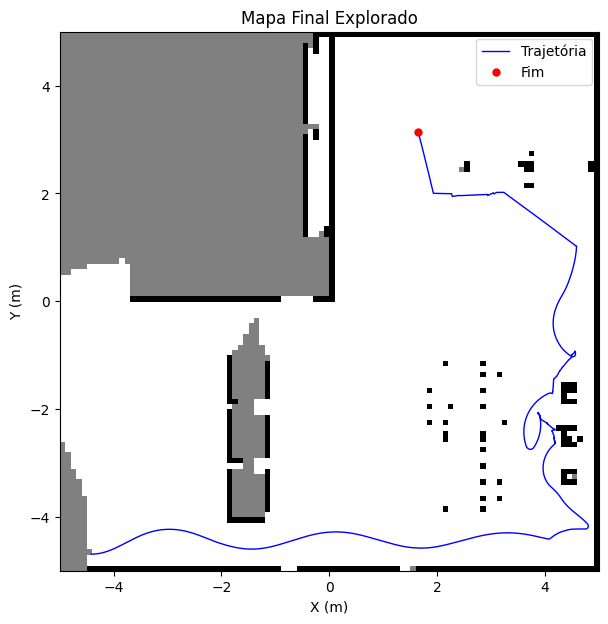

>> MANOBRA: Seguindo reto... (X atual: 1.65)
>> MANOBRA: Seguindo reto... (X atual: 1.65)
>> MANOBRA: Seguindo reto... (X atual: 1.65)
>> MANOBRA: Seguindo reto... (X atual: 1.64)
>> MANOBRA: Seguindo reto... (X atual: 1.64)
>> MANOBRA: Seguindo reto... (X atual: 1.64)
>> MANOBRA: Seguindo reto... (X atual: 1.64)
>> MANOBRA: Seguindo reto... (X atual: 1.63)
>> MANOBRA: Seguindo reto... (X atual: 1.63)
>> MANOBRA: Seguindo reto... (X atual: 1.63)
>> MANOBRA: Seguindo reto... (X atual: 1.63)
>> MANOBRA: Seguindo reto... (X atual: 1.62)
>> MANOBRA: Seguindo reto... (X atual: 1.62)
>> MANOBRA: Seguindo reto... (X atual: 1.62)
>> MANOBRA: Seguindo reto... (X atual: 1.62)
>> MANOBRA: Seguindo reto... (X atual: 1.61)
>> MANOBRA: Seguindo reto... (X atual: 1.61)
>> MANOBRA: Seguindo reto... (X atual: 1.61)
>> MANOBRA: Seguindo reto... (X atual: 1.61)
>> MANOBRA: Seguindo reto... (X atual: 1.61)
>> MANOBRA: Seguindo reto... (X atual: 1.60)
>> MANOBRA: Seguindo reto... (X atual: 1.60)
>> MANOBRA

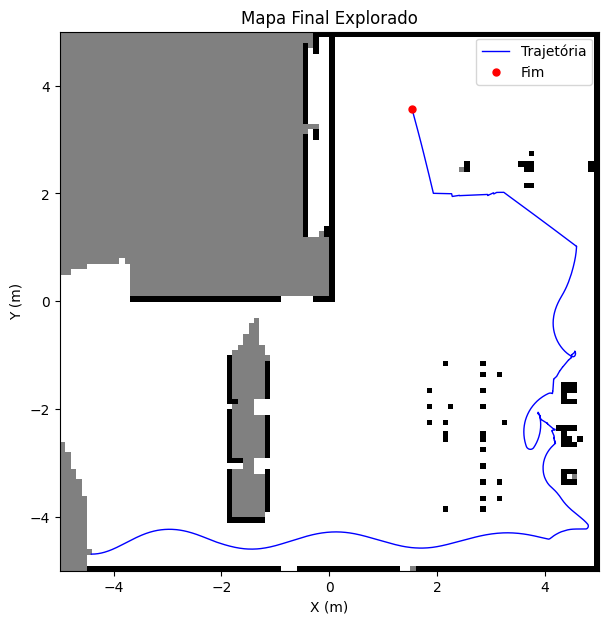

>> MANOBRA: Seguindo reto... (X atual: 1.54)
>> MANOBRA: Seguindo reto... (X atual: 1.53)
>> MANOBRA: Seguindo reto... (X atual: 1.53)
>> MANOBRA: Seguindo reto... (X atual: 1.53)
>> MANOBRA: Seguindo reto... (X atual: 1.53)
>> MANOBRA: Seguindo reto... (X atual: 1.52)
>> MANOBRA: Seguindo reto... (X atual: 1.52)
>> MANOBRA: Seguindo reto... (X atual: 1.52)
>> MANOBRA: Seguindo reto... (X atual: 1.52)
>> MANOBRA: Seguindo reto... (X atual: 1.52)
>> MANOBRA: Seguindo reto... (X atual: 1.51)
>> MANOBRA: Seguindo reto... (X atual: 1.51)
>> MANOBRA: Seguindo reto... (X atual: 1.51)
>> MANOBRA: Seguindo reto... (X atual: 1.51)
>> MANOBRA: Seguindo reto... (X atual: 1.50)
>> MANOBRA: Seguindo reto... (X atual: 1.50)
>> MANOBRA: Seguindo reto... (X atual: 1.50)
>> MANOBRA: Seguindo reto... (X atual: 1.50)
>> MANOBRA: Seguindo reto... (X atual: 1.49)
>> MANOBRA: Seguindo reto... (X atual: 1.49)
>> MANOBRA: Seguindo reto... (X atual: 1.49)
>> MANOBRA: Seguindo reto... (X atual: 1.49)
>> MANOBRA

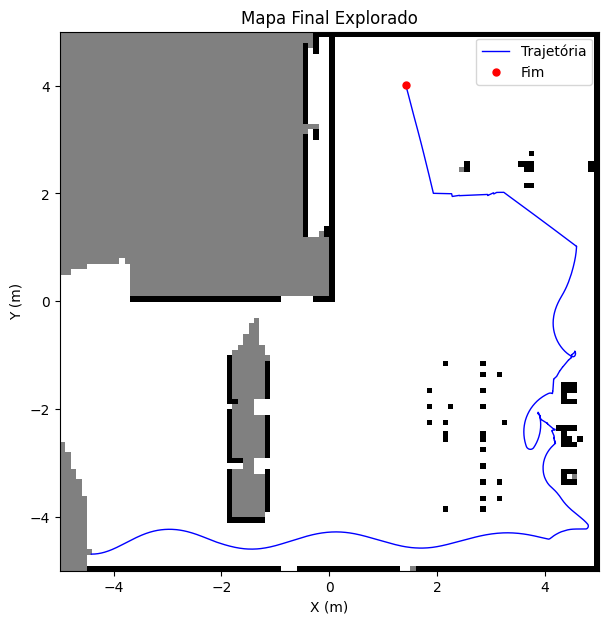

>> MANOBRA: Seguindo reto... (X atual: 1.42)
>> MANOBRA: Seguindo reto... (X atual: 1.42)
>> MANOBRA: Seguindo reto... (X atual: 1.42)
>> MANOBRA: Seguindo reto... (X atual: 1.41)
>> MANOBRA: Seguindo reto... (X atual: 1.41)
>> MANOBRA: Seguindo reto... (X atual: 1.41)
>> MANOBRA: Seguindo reto... (X atual: 1.41)
>> MANOBRA: Seguindo reto... (X atual: 1.40)
>> MANOBRA: Seguindo reto... (X atual: 1.40)
>> MANOBRA: Seguindo reto... (X atual: 1.40)
>> MANOBRA: Seguindo reto... (X atual: 1.40)
>> MANOBRA: Seguindo reto... (X atual: 1.39)
>> MANOBRA: Seguindo reto... (X atual: 1.39)
>> MANOBRA: Seguindo reto... (X atual: 1.39)
>> MANOBRA: Seguindo reto... (X atual: 1.39)
>> MANOBRA: Seguindo reto... (X atual: 1.39)
>> MANOBRA: Seguindo reto... (X atual: 1.38)
>> MANOBRA: Seguindo reto... (X atual: 1.38)
>> MANOBRA: Seguindo reto... (X atual: 1.38)
>> MANOBRA: Seguindo reto... (X atual: 1.38)
>> MANOBRA: Seguindo reto... (X atual: 1.37)
>> MANOBRA: Seguindo reto... (X atual: 1.37)
>> MANOBRA

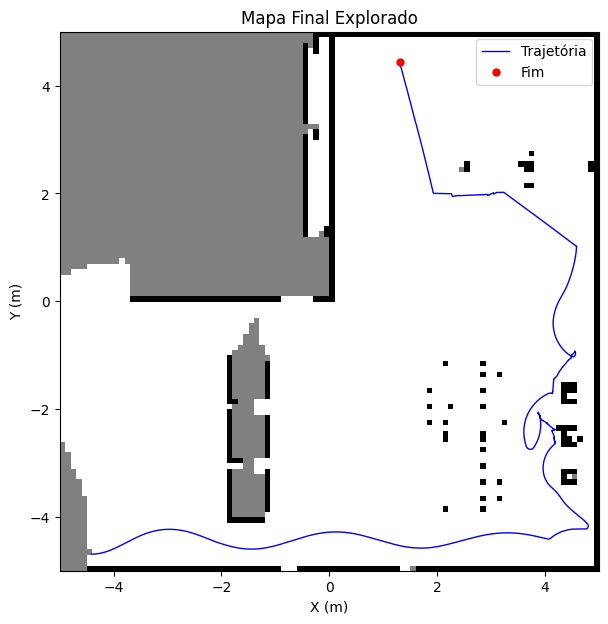

>> MANOBRA: Seguindo reto... (X atual: 1.30)
>> MANOBRA: Seguindo reto... (X atual: 1.30)
>> MANOBRA: Seguindo reto... (X atual: 1.30)
>> MANOBRA: Seguindo reto... (X atual: 1.30)
>> MANOBRA: Seguindo reto... (X atual: 1.29)
>> MANOBRA: Seguindo reto... (X atual: 1.29)
>> MANOBRA: Seguindo reto... (X atual: 1.29)
>> MANOBRA: Seguindo reto... (X atual: 1.29)
>> MANOBRA: Seguindo reto... (X atual: 1.28)
>> MANOBRA: Seguindo reto... (X atual: 1.28)
>> MANOBRA: Seguindo reto... (X atual: 1.28)
>> MANOBRA: Seguindo reto... (X atual: 1.28)
>> MANOBRA: Seguindo reto... (X atual: 1.28)
>> MANOBRA: Seguindo reto... (X atual: 1.27)
>> MANOBRA: Seguindo reto... (X atual: 1.27)
>> MANOBRA: Seguindo reto... (X atual: 1.27)
>> MANOBRA: Seguindo reto... (X atual: 1.27)
>> MANOBRA: Seguindo reto... (X atual: 1.26)
>> MANOBRA: Seguindo reto... (X atual: 1.26)
>> MANOBRA: Seguindo reto... (X atual: 1.26)
>> MANOBRA: Seguindo reto... (X atual: 1.26)
>> MANOBRA: Seguindo reto... (X atual: 1.25)
>> MANOBRA

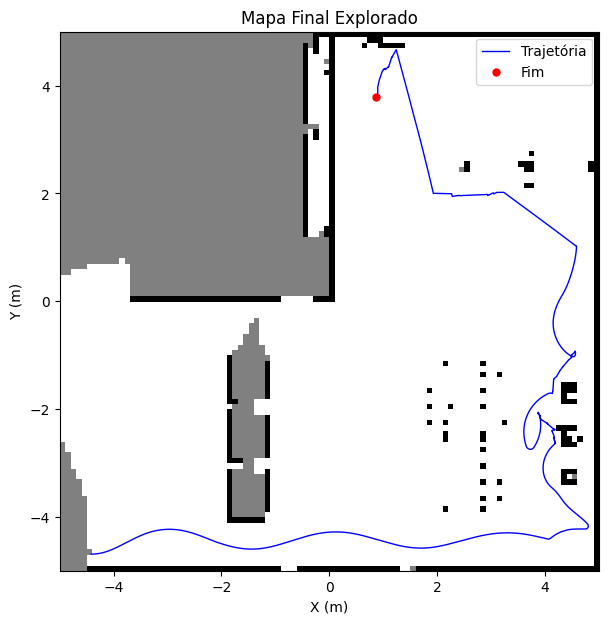

>> MANOBRA: Virando à esquerda... (7)
>> MANOBRA: Virando à esquerda... (6)
>> MANOBRA: Virando à esquerda... (5)
>> MANOBRA: Virando à esquerda... (4)
>> MANOBRA: Virando à esquerda... (3)
>> MANOBRA: Virando à esquerda... (2)
>> MANOBRA: Virando à esquerda... (1)
>> MANOBRA: Manobra completa. Retomando wall-following.
Gerando Plot 2 (Mapa de Grid)...


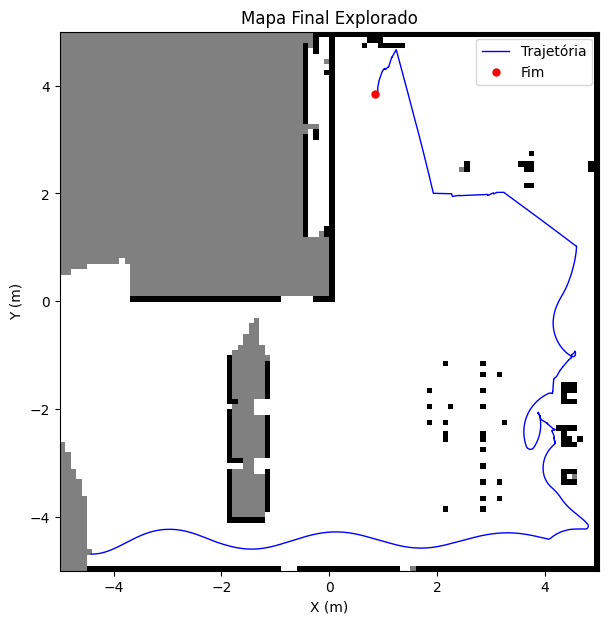

Gerando Plot 2 (Mapa de Grid)...


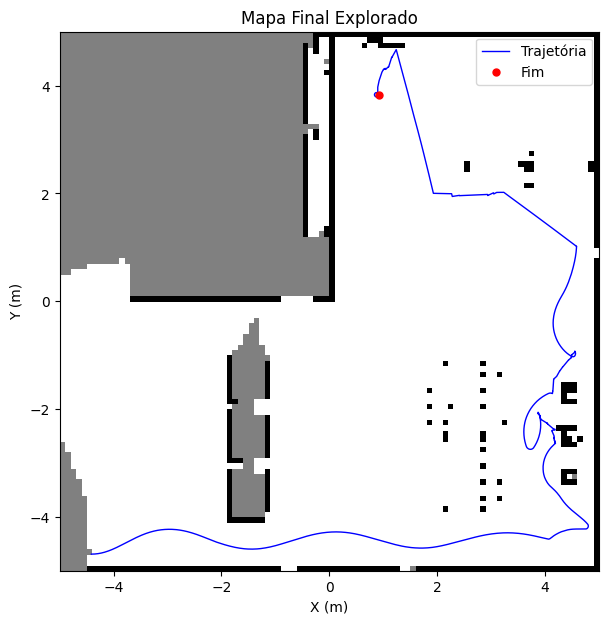

Gerando Plot 2 (Mapa de Grid)...


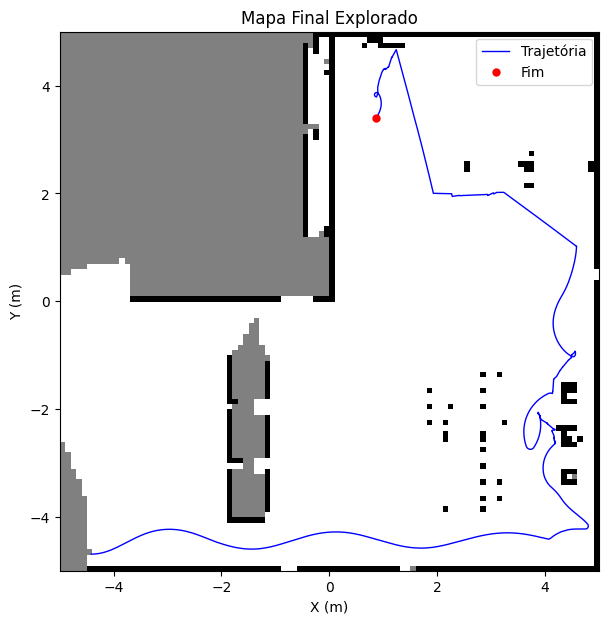

Gerando Plot 2 (Mapa de Grid)...


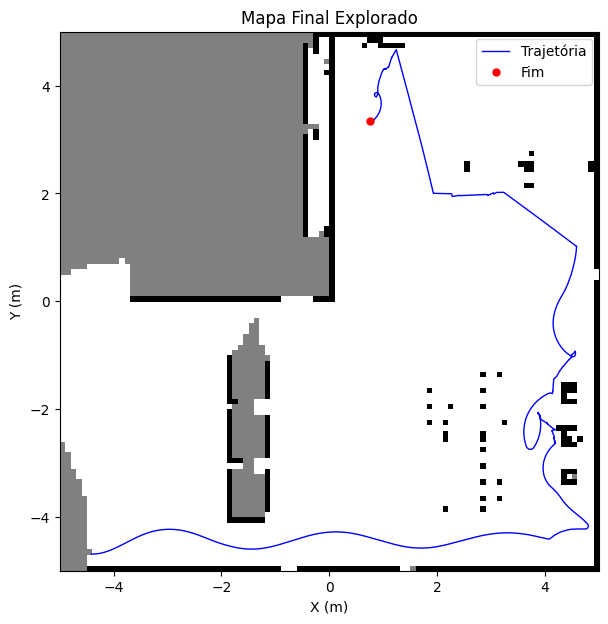

Gerando Plot 2 (Mapa de Grid)...


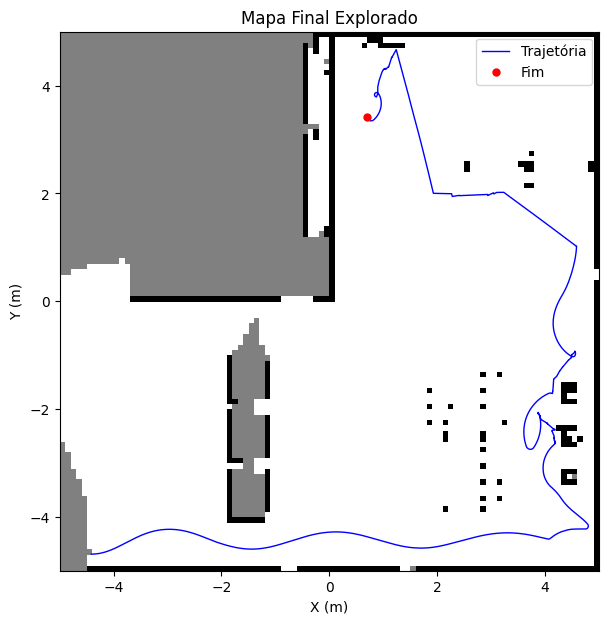

Gerando Plot 2 (Mapa de Grid)...


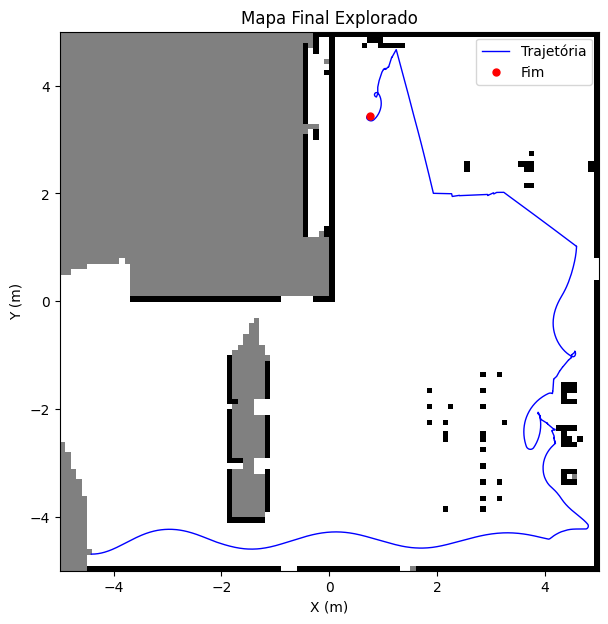

Gerando Plot 2 (Mapa de Grid)...


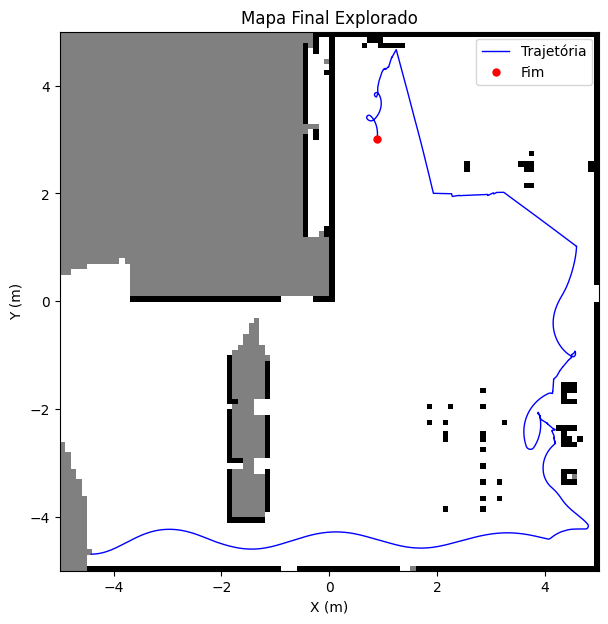

Gerando Plot 2 (Mapa de Grid)...


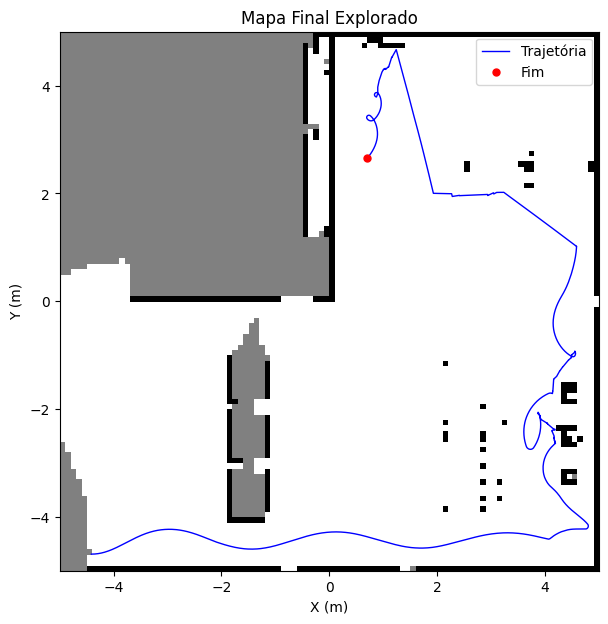

Gerando Plot 2 (Mapa de Grid)...


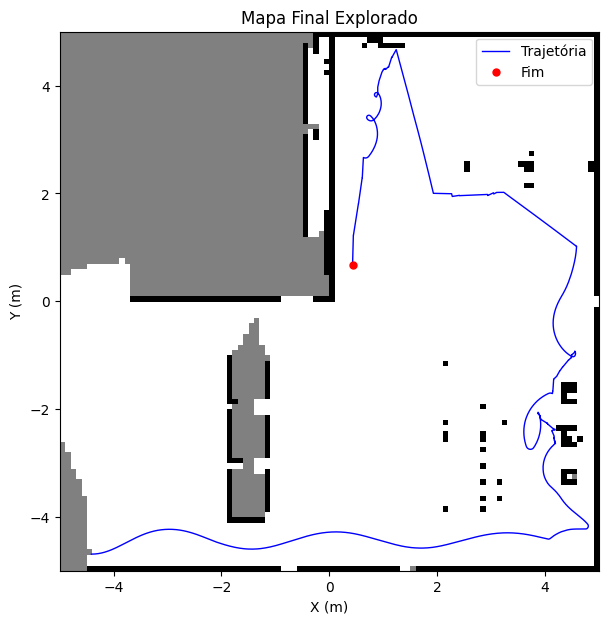

Gerando Plot 2 (Mapa de Grid)...


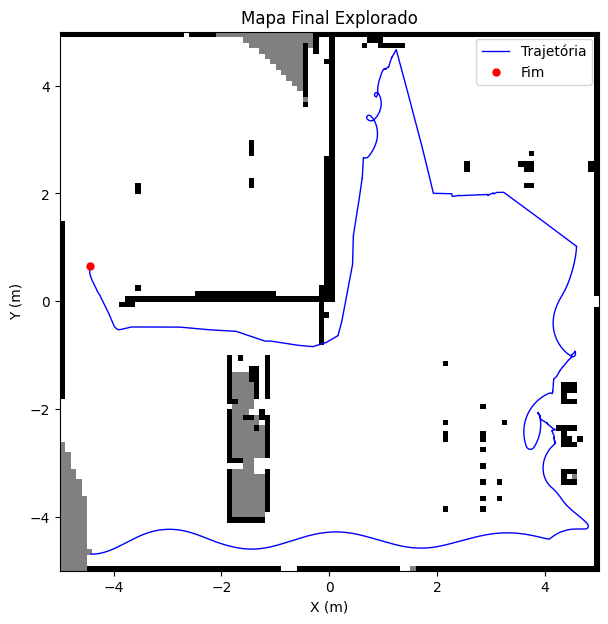

Gerando Plot 2 (Mapa de Grid)...


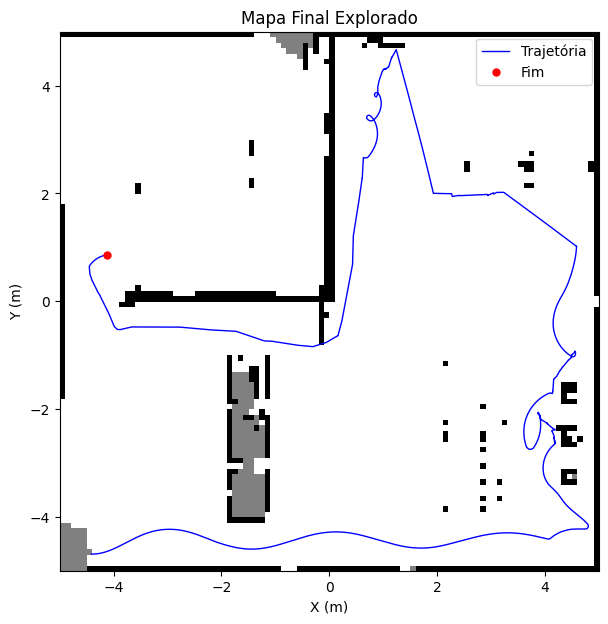

Gerando Plot 2 (Mapa de Grid)...


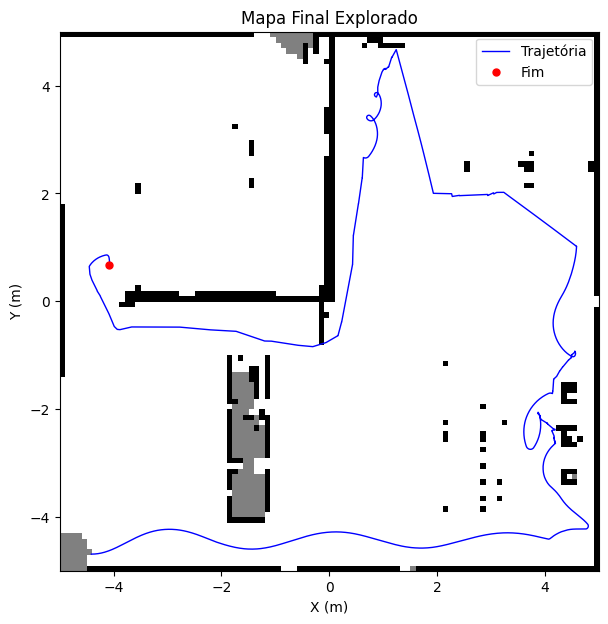

Gerando Plot 2 (Mapa de Grid)...


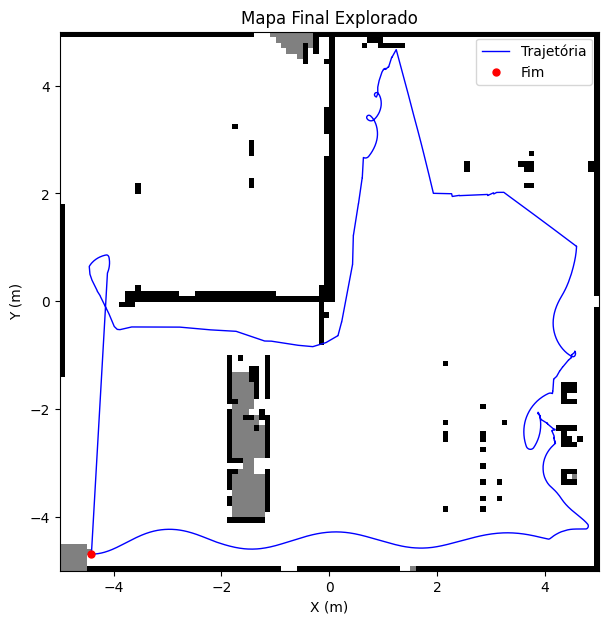

Gerando Plot 2 (Mapa de Grid)...


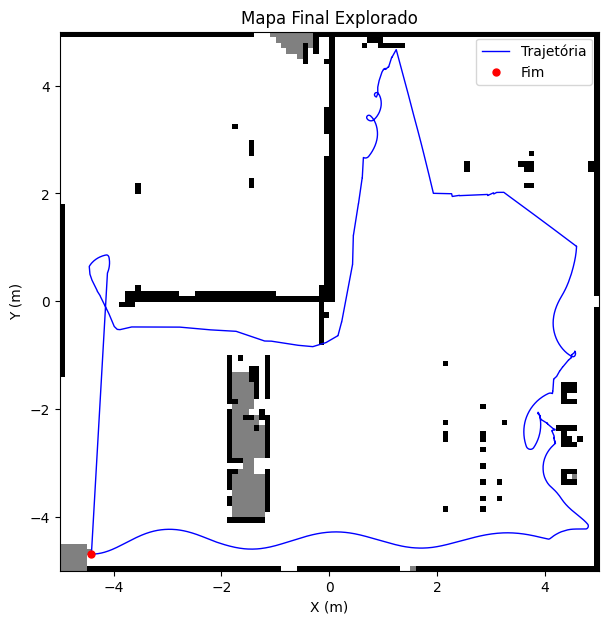

Gerando Plot 2 (Mapa de Grid)...


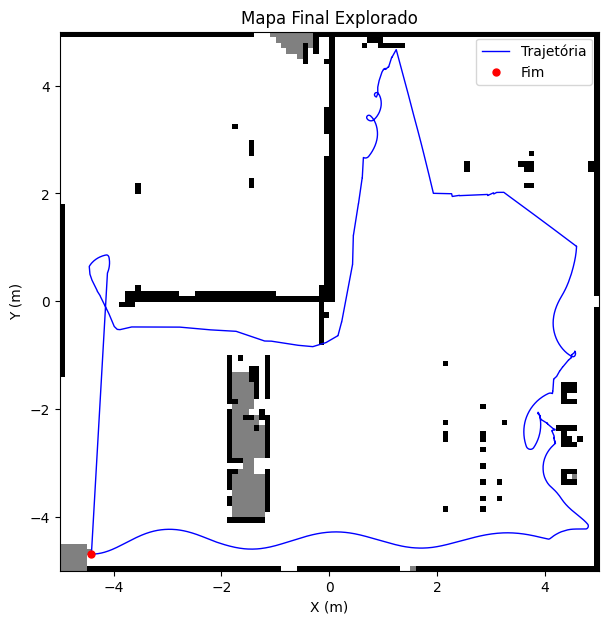

Gerando Plot 2 (Mapa de Grid)...


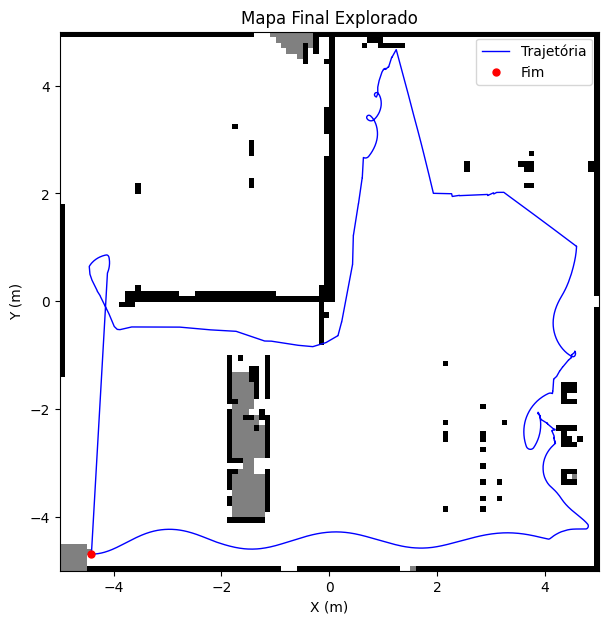

Gerando Plot 2 (Mapa de Grid)...


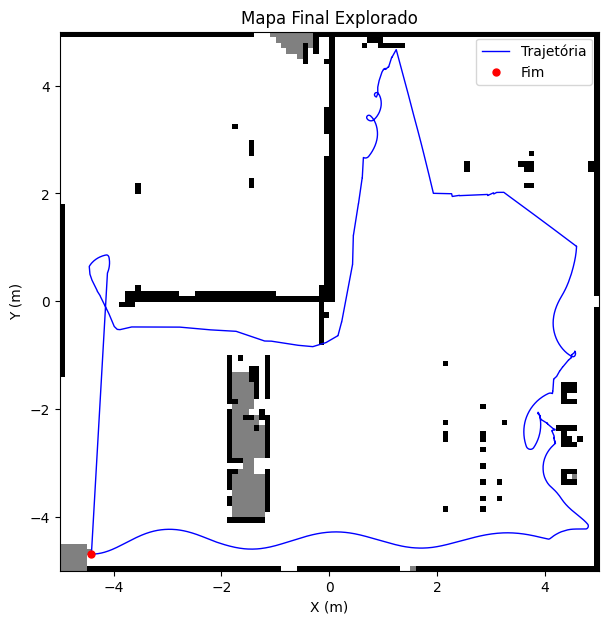

KeyboardInterrupt: 

In [234]:
# mexendo atualmente
LOG_ODDS_MIN = -10.0
LOG_ODDS_MAX = 10.0

# --- PARÂMETROS DO MAPA ---
MAP_RESOLUTION = 0.1  # 10 cm por célula (problema quando muda a resolucao)
MAP_SIZE_X = 10.0      # metros
MAP_SIZE_Y = 10.0      # metros
MAP_ORIGIN_X = -5.0    # Canto inferior esquerdo X
MAP_ORIGIN_Y = -5.0    # Canto inferior esquerdo Y
nrows = int(MAP_SIZE_Y / MAP_RESOLUTION)
ncols = int(MAP_SIZE_X / MAP_RESOLUTION)
MAX_SCAN_DISTANCE = 5.0

# Valores de Log-Odds
# l_occ = 0.9
# l_free = -0.4
LOG_ODDS_MIN = -5.0
LOG_ODDS_MAX = 5.0


def world_to_grid_xy(wx, wy):
    
    # Converte mundo (x,y) [m] -> índice de célula (ix, iy)
    # origem está no centro do mapa 0,0
    
    ix = int((wx - MAP_ORIGIN_X) / MAP_RESOLUTION)
    iy = int((wy - MAP_ORIGIN_Y) / MAP_RESOLUTION)
    
    # ix = int((ncols / 2) + (wx / cell_size)) # parentezes modificado, caso tenha problema rever
    # iy = int((nrows / 2) + (wy / cell_size))

    if 0 <= ix < ncols and 0 <= iy < nrows:
        return ix, iy
    return None, None

MAX_RANGE_THRESHOLD = MAX_SCAN_DISTANCE * 0.99
# Calculo do log_odds (explicar no video)
def update_map_log_odds(log_odds_map, robot_pos, laser_data, step, last_seen,
                        l_occ=0.2, l_free=-0.7):
    
    x, y, theta_r = robot_pos[0], robot_pos[1], robot_pos[2]
    x_Grid, y_Grid = world_to_grid_xy(x, y)
    
    if x_Grid is None or y_Grid is None:
        return log_odds_map, last_seen

    # Limiar para considerar uma célula como "fortemente ocupada"
    # (Não apague células acima deste valor)
    L_OCC_THRESHOLD = 3 
    L_FREE_THRESHOLD = -3
    
    
    for d, ang in laser_data:
        if d <= 0.01: 
            continue

        global_ang = theta_r + ang
        posi_x = x + d * np.cos(global_ang)
        posi_y = y + d * np.sin(global_ang)
        posi_xGrid, posi_yGrid = world_to_grid_xy(posi_x, posi_y)
        
        if posi_xGrid is None or posi_yGrid is None:
            continue
        
        rr, cc = line(y_Grid, x_Grid, posi_yGrid, posi_xGrid)
        
        if len(rr) <= 1:
            continue

        # --- LÓGICA DE ATUALIZAÇÃO CORRIGIDA ---

        # 1. Obter todas as células do feixe (exceto a do robô)
        beam_rows, beam_cols = rr[1:], cc[1:]

        # 2. Aplicar 'livre' (l_free) ao longo do feixe, EXCETO no ponto final
        if len(beam_rows) > 1:
            path_rows, path_cols = beam_rows[:-1], beam_cols[:-1]
            
            # Verificar o estado atual dessas células
            current_log_odds = log_odds_map[path_rows, path_cols]
            
            # Criar uma máscara de células que NÃO estão fortemente ocupadas
            free_or_unknown_mask = current_log_odds < L_OCC_THRESHOLD
            
            # Aplicar 'l_free' APENAS a essas células
            rows_to_free = path_rows[free_or_unknown_mask]
            cols_to_free = path_cols[free_or_unknown_mask]
            log_odds_map[rows_to_free, cols_to_free] += l_free

        # 3. Tratar o PONTO FINAL (a última célula do feixe)
        end_row, end_col = beam_rows[-1], beam_cols[-1]
        
        if d < MAX_RANGE_THRESHOLD:
            # if log_odds_map[end_row, end_col] > L_FREE_THRESHOLD:
                log_odds_map[end_row, end_col] += l_occ
        else:
            # Feixe de Max Range -> Marcar ponto final como LIVRE
            # (Também checando para não apagar um obstáculo)
            # if log_odds_map[end_row, end_col] < L_OCC_THRESHOLD:
                log_odds_map[end_row, end_col] += l_free

        # 4. Atualizar o tempo de visão de todo o feixe
        last_seen[rr, cc] = step

    # Clamp para estabilidade
    np.clip(log_odds_map, LOG_ODDS_MIN, LOG_ODDS_MAX, out=log_odds_map)
    return log_odds_map, last_seen



# -----------------------
# Setup CoppeliaSim (exemplo)
# -----------------------
client = RemoteAPIClient()
sim = client.require("sim")
sim.stopSimulation()
time.sleep(0.2)
sim.startSimulation()
sim.setStepping(True)

robotname = "kobuki"
robot = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")  # seu wrapper

# funcoes a verificar
world = pixel_to_world(30,34,100,10)
goal_position = np.array([world[0], world[1]])

# -----------------------
# Config mapa / constantes
# -----------------------
map_size_m = 10.0
cell_size = 0.1                      # m por célula
ncols = int(map_size_m / cell_size)  # cols = eixo X
nrows = int(map_size_m / cell_size)  # rows = eixo Y
grid_origin = np.array([-map_size_m/2, -map_size_m/2])  # world coord do canto inferior esquerdo da célula (0,0)


L = 0.381  
r = 0.0975 

hist = []            
laser_global = []    

# log-odds map: shape (nrows, ncols) -> index como [row, col] = [y, x]
log_odds_map = np.zeros((nrows, ncols))
last_seen = np.zeros_like(log_odds_map)


# colormap: 0=desconhecido(gray), 1=livre(white), 2=ocupado(black)
cmap = ListedColormap(["gray", "white", "black"])

# -----------------------
# Loop principal (visualização em metros)
# -----------------------
plt.ion()
fig, ax = plt.subplots(figsize=(6,6))

robot_path_world = []  # lista de (x,y) world coordinates

for step in range(10000):
    sim.step()
    # pos = sim.getObjectPosition(robot, -1)
    # ori = sim.getObjectOrientation(robot, -1)
    
    
    pos = sim.getObjectPosition(robot, sim.handle_world)
    ori = sim.getObjectOrientation(robot, sim.handle_world)
    
    
    hist.append([pos[0], pos[1]])
    
    laser_data = hokuyo.getSensorData() # Retorna [ângulo, dist]
    laser_global.extend(transform_laser_to_global(laser_data, pos, ori))

    robot_pos = [pos[0], pos[1], ori[2]]
    
    
    laser_data_swapped = [[d, a] for a, d in laser_data]
        
    log_odds_map, last_seen = update_map_log_odds(
        log_odds_map,
        robot_pos,
        laser_data_swapped,
        step,
        last_seen
    )
    
    # if step % 10 == 0:
    #     unseen_mask = (step - last_seen) > 400
    #     log_odds_map[unseen_mask] *= 0.995

    # log_odds_map = update_map_log_odds(log_odds_map, robot_pos, laser_data)

    # salvar rastro em coords do mundo
    robot_path_world.append((robot_pos[0], robot_pos[1]))
    wl, wr = controle_wall_following_corrigido(sim,robot,laser_data, r, L)
    
    # wl, wr =  controle_campos(world, goal_position, np.array([pos[0], pos[1]]), ori, laser_data, r, L)
    sim.setJointTargetVelocity(l_wheel, wl)
    sim.setJointTargetVelocity(r_wheel, wr)

    if step % 50 == 0:
        
        print("Gerando Plot 2 (Mapa de Grid)...")

        # Converter log-odds para probabilidade (sua fórmula está correta)
        # 'log_odds_map' foi criada e atualizada no seu loop 'while'
        prob = 1.0 / (1.0 + np.exp(-log_odds_map)) 

        # Criar mapa visual (0=desconhecido, 1=livre, 2=ocupado)
        grid_vis = np.zeros_like(prob, dtype=np.uint8) # 0 = desconhecido
        grid_vis[prob < 0.45] = 1 # 1 = livre (branco)
        grid_vis[prob > 0.55] = 2 # 2 = ocupado (preto)

        # Definir um colormap: 0=cinza, 1=branco, 2=preto
        # (Substitui a variável 'cmap' indefinida)
        cmap = ListedColormap(['#808080', '#FFFFFF', '#000000'])

        plt.ioff()
        fig2, ax2 = plt.subplots(figsize=(7,7))

        # Definir a 'extent' usando as variáveis de configuração do mapa
        # (Substitui 'grid_origin', 'ncols', 'cell_size')
        extent = [MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X, 
                MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y]
                
        ax2.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

        # Plotar a trajetória (usando 'hist' ao invés de 'robot_path_world')
        if hist:
            xs, ys = zip(*hist)
            ax2.plot(xs, ys, color='blue', linewidth=1, label="Trajetória")
            ax2.plot(xs[-1], ys[-1], 'ro', markersize=5, label="Fim") # Ponto final

        # (Removi ax2.arrow() pois 'robot_pos' não está disponível aqui,
        # e o ponto final vermelho já marca a posição final)

        ax2.set_title("Mapa Final Explorado")
        ax2.set_xlabel("X (m)")
        ax2.set_ylabel("Y (m)")
        ax2.set_aspect('equal')
        ax2.legend()
        plt.show()
        




     

# parar sim
sim.stopSimulation()
print('Program ended')

# -----------------------------------------------------------------
# Plot 1: Scatter (o que você já tinha, gera laiser.png)
# (Este código é do seu original.py e está correto)
# -----------------------------------------------------------------
print("Gerando Plot 1 (Scatter)...")
fig1 = plt.figure(figsize=(8,8), dpi=100)
ax1 = fig1.add_subplot(111, aspect='equal')

# 'hist' é a variável do seu script original.py
x, y = zip(*hist)
ax1.plot(x, y, '--k', label="Trajetória")
ax1.plot(x[0], y[0], 'go', markersize=10, label="Início")
ax1.plot(x[-1], y[-1], 'ro', markersize=10, label="Fim")

# 'laser_global' é a variável do seu script original.py
if len(laser_global) > 0:
    lx, ly = zip(*laser_global)
    ax1.scatter(lx, ly, s=2, c='r', alpha=0.3, label="Laser")

ax1.legend()
ax1.set_xlabel("X [m]")
ax1.set_ylabel("Y [m]")
ax1.grid(True)
ax1.set_title("Plot de Pontos do Laser (Scatter)")
plt.show()


# -----------------------------------------------------------------
# Plot 2: Mapa de Grade (gera grid.png)
# (Este é o código corrigido e integrado)
# -----------------------------------------------------------------
print("Gerando Plot 2 (Mapa de Grade)...")

# Converter log-odds para probabilidade (sua fórmula está correta)
# 'log_odds_map' foi criada e atualizada no seu loop 'while'
prob = 1.0 / (1.0 + np.exp(-log_odds_map)) 

# Criar mapa visual (0=desconhecido, 1=livre, 2=ocupado)
grid_vis = np.zeros_like(prob, dtype=np.uint8) # 0 = desconhecido
grid_vis[prob < 0.45] = 1 # 1 = livre (branco)
grid_vis[prob > 0.55] = 2 # 2 = ocupado (preto)

# Definir um colormap: 0=cinza, 1=branco, 2=preto
# (Substitui a variável 'cmap' indefinida)
cmap = ListedColormap(['#808080', '#FFFFFF', '#000000'])

plt.ioff()
fig2, ax2 = plt.subplots(figsize=(7,7))

# Definir a 'extent' usando as variáveis de configuração do mapa
# (Substitui 'grid_origin', 'ncols', 'cell_size')
extent = [MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X, 
          MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y]
          
ax2.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

# Plotar a trajetória (usando 'hist' ao invés de 'robot_path_world')
if hist:
    xs, ys = zip(*hist)
    ax2.plot(xs, ys, color='blue', linewidth=1, label="Trajetória")
    ax2.plot(xs[-1], ys[-1], 'ro', markersize=5, label="Fim") # Ponto final

# (Removi ax2.arrow() pois 'robot_pos' não está disponível aqui,
# e o ponto final vermelho já marca a posição final)

ax2.set_title("Mapa Final Explorado")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_aspect('equal')
ax2.legend()
plt.show()




In [6]:
#20:38 12 nov

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time
import math 
import networkx as nx
import numpy as np
from skimage.draw import line
from matplotlib.colors import ListedColormap

from coppeliasim_zmqremoteapi_client import RemoteAPIClient 

def Rz(theta):
  
    return np.array([[ np.cos(theta), -np.sin(theta), 0 ],
                      [ np.sin(theta), np.cos(theta) , 0 ],
                      [ 0            , 0             , 1 ]])


# mexendo atualmente
LOG_ODDS_MIN = -10.0
LOG_ODDS_MAX = 10.0

# --- PARÂMETROS DO MAPA ---
MAP_RESOLUTION = 0.1  # 10 cm por célula (problema quando muda a resolucao)
MAP_SIZE_X = 10.0      # metros
MAP_SIZE_Y = 10.0      # metros
MAP_ORIGIN_X = -5.0    # Canto inferior esquerdo X
MAP_ORIGIN_Y = -5.0    # Canto inferior esquerdo Y
nrows = int(MAP_SIZE_Y / MAP_RESOLUTION)
ncols = int(MAP_SIZE_X / MAP_RESOLUTION)
MAX_SCAN_DISTANCE = 5.0

# Valores de Log-Odds
l_occ = 0.9
l_free = -0.4
LOG_ODDS_MIN = -5.0
LOG_ODDS_MAX = 5.0


def world_to_grid_xy(wx, wy):
    
    # Converte mundo (x,y) [m] -> índice de célula (ix, iy)
    # origem está no centro do mapa 0,0
    
    ix = int((wx - MAP_ORIGIN_X) / MAP_RESOLUTION)
    iy = int((wy - MAP_ORIGIN_Y) / MAP_RESOLUTION)
    
    # ix = int((ncols / 2) + (wx / cell_size)) # parentezes modificado, caso tenha problema rever
    # iy = int((nrows / 2) + (wy / cell_size))

    if 0 <= ix < ncols and 0 <= iy < nrows:
        return ix, iy
    return None, None

MAX_RANGE_THRESHOLD = MAX_SCAN_DISTANCE * 0.99
# Calculo do log_odds (explicar no video)
def update_map_log_odds(log_odds_map, robot_pos, laser_data, l_occ = 0.9, l_free = -0.4):
    
    # define a posicao e rotacao do robo
    x, y, theta_r = robot_pos[0], robot_pos[1], robot_pos[2]

    # índice da célula do robô (coluna, linha)
    x_Grid, y_Grid = world_to_grid_xy(x, y)
    
    # caso o robo esteja fora do mapa
    if x_Grid is None or y_Grid is None:
        return log_odds_map

    for d, ang in laser_data: # verificar como esse laiser data está chegando
        # filtrar leituras inválidas
        if d <= 0.01: 
            continue

        global_ang = theta_r + ang
        
        posi_x = x + d * np.cos(global_ang)
        posi_y = y + d * np.sin(global_ang)

        posi_xGrid, posi_yGrid = world_to_grid_xy(posi_x, posi_y)
        
        if posi_xGrid is None or posi_yGrid is None:
            continue
        
        # Bresenham: linha de (iy_r, ix_r) até (iy, ix) -> rr (rows), cc (cols)
        rr, cc = line(y_Grid, x_Grid, posi_yGrid, posi_xGrid)
        
        # CASO 1: É um obstáculo REAL (distância < max)
        if d < MAX_RANGE_THRESHOLD:
            # Marcar células intermediárias como livres
            if len(rr) > 2:
                log_odds_map[rr[1:-1], cc[1:-1]] += l_free
            
            # Marcar célula de impacto como ocupada
            log_odds_map[posi_yGrid, posi_xGrid] += l_occ
        
        # CASO 2: É um feixe de MAX RANGE (sem obstáculo)
        else:
            # Marcar TODAS as células ao longo do feixe como livres
            # (Exceto a primeira, onde o robô está)
            if len(rr) > 1:
                log_odds_map[rr[1:], cc[1:]] += l_free

        # marcar a célula de impacto como ocupada
        # log_odds_map[posi_yGrid, posi_xGrid] += l_occ

    # clamp para estabilidade numérica
    np.clip(log_odds_map, LOG_ODDS_MIN, LOG_ODDS_MAX, out=log_odds_map)
    return log_odds_map



# -----------------------
# Setup CoppeliaSim (exemplo)
# -----------------------
client = RemoteAPIClient()
sim = client.require("sim")
sim.stopSimulation()
time.sleep(0.2)
sim.startSimulation()
sim.setStepping(True)

robotname = "kobuki"
robot = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")  # seu wrapper

# funcoes a verificar
world = pixel_to_world(30,34,100,10)
goal_position = np.array([world[0], world[1]])

# -----------------------
# Config mapa / constantes
# -----------------------
map_size_m = 10.0
cell_size = 0.1                      # m por célula
ncols = int(map_size_m / cell_size)  # cols = eixo X
nrows = int(map_size_m / cell_size)  # rows = eixo Y
grid_origin = np.array([-map_size_m/2, -map_size_m/2])  # world coord do canto inferior esquerdo da célula (0,0)


L = 0.381  
r = 0.0975 

hist = []            
laser_global = []    

# log-odds map: shape (nrows, ncols) -> index como [row, col] = [y, x]
log_odds_map = np.zeros((nrows, ncols))



# colormap: 0=desconhecido(gray), 1=livre(white), 2=ocupado(black)
cmap = ListedColormap(["gray", "white", "black"])

# -----------------------
# Loop principal (visualização em metros)
# -----------------------
plt.ion()
fig, ax = plt.subplots(figsize=(6,6))

robot_path_world = []  # lista de (x,y) world coordinates

for step in range(10000):
    sim.step()
    # pos = sim.getObjectPosition(robot, -1)
    # ori = sim.getObjectOrientation(robot, -1)
    
    
    pos = sim.getObjectPosition(robot, sim.handle_world)
    ori = sim.getObjectOrientation(robot, sim.handle_world)
    
    
    hist.append([pos[0], pos[1]])
    
    laser_data = hokuyo.getSensorData() # Retorna [ângulo, dist]
    laser_global.extend(transform_laser_to_global(laser_data, pos, ori))

    robot_pos = [pos[0], pos[1], ori[2]]
    
    
    laser_data_swapped = [[d, a] for a, d in laser_data]
        
    log_odds_map = update_map_log_odds(
        log_odds_map, 
        robot_pos, 
        laser_data_swapped, # Usar os dados com ordem invertida
        l_occ, 
        l_free
    )

    # log_odds_map = update_map_log_odds(log_odds_map, robot_pos, laser_data)

    # salvar rastro em coords do mundo
    robot_path_world.append((robot_pos[0], robot_pos[1]))
    wl, wr =  controle_wall_following(laser_data, r, L)
    # wl, wr =  controle_campos(world, goal_position, np.array([pos[0], pos[1]]), ori, laser_data, r, L)
    sim.setJointTargetVelocity(l_wheel, wl)
    sim.setJointTargetVelocity(r_wheel, wr)

    if step % 50 == 0:
        
        print("Gerando Plot 2 (Mapa de Grid)...")

        # Converter log-odds para probabilidade (sua fórmula está correta)
        # 'log_odds_map' foi criada e atualizada no seu loop 'while'
        prob = 1.0 / (1.0 + np.exp(-log_odds_map)) 

        # Criar mapa visual (0=desconhecido, 1=livre, 2=ocupado)
        grid_vis = np.zeros_like(prob, dtype=np.uint8) # 0 = desconhecido
        grid_vis[prob < 0.45] = 1 # 1 = livre (branco)
        grid_vis[prob > 0.55] = 2 # 2 = ocupado (preto)

        # Definir um colormap: 0=cinza, 1=branco, 2=preto
        # (Substitui a variável 'cmap' indefinida)
        cmap = ListedColormap(['#808080', '#FFFFFF', '#000000'])

        plt.ioff()
        fig2, ax2 = plt.subplots(figsize=(7,7))

        # Definir a 'extent' usando as variáveis de configuração do mapa
        # (Substitui 'grid_origin', 'ncols', 'cell_size')
        extent = [MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X, 
                MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y]
                
        ax2.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

        # Plotar a trajetória (usando 'hist' ao invés de 'robot_path_world')
        if hist:
            xs, ys = zip(*hist)
            ax2.plot(xs, ys, color='blue', linewidth=1, label="Trajetória")
            ax2.plot(xs[-1], ys[-1], 'ro', markersize=5, label="Fim") # Ponto final

        # (Removi ax2.arrow() pois 'robot_pos' não está disponível aqui,
        # e o ponto final vermelho já marca a posição final)

        ax2.set_title("Mapa Final Explorado")
        ax2.set_xlabel("X (m)")
        ax2.set_ylabel("Y (m)")
        ax2.set_aspect('equal')
        ax2.legend()
        plt.show()
        




     

# parar sim
sim.stopSimulation()
print('Program ended')

# -----------------------------------------------------------------
# Plot 1: Scatter (o que você já tinha, gera laiser.png)
# (Este código é do seu original.py e está correto)
# -----------------------------------------------------------------
print("Gerando Plot 1 (Scatter)...")
fig1 = plt.figure(figsize=(8,8), dpi=100)
ax1 = fig1.add_subplot(111, aspect='equal')

# 'hist' é a variável do seu script original.py
x, y = zip(*hist)
ax1.plot(x, y, '--k', label="Trajetória")
ax1.plot(x[0], y[0], 'go', markersize=10, label="Início")
ax1.plot(x[-1], y[-1], 'ro', markersize=10, label="Fim")

# 'laser_global' é a variável do seu script original.py
if len(laser_global) > 0:
    lx, ly = zip(*laser_global)
    ax1.scatter(lx, ly, s=2, c='r', alpha=0.3, label="Laser")

ax1.legend()
ax1.set_xlabel("X [m]")
ax1.set_ylabel("Y [m]")
ax1.grid(True)
ax1.set_title("Plot de Pontos do Laser (Scatter)")
plt.show()


# -----------------------------------------------------------------
# Plot 2: Mapa de Grade (gera grid.png)
# (Este é o código corrigido e integrado)
# -----------------------------------------------------------------
print("Gerando Plot 2 (Mapa de Grade)...")

# Converter log-odds para probabilidade (sua fórmula está correta)
# 'log_odds_map' foi criada e atualizada no seu loop 'while'
prob = 1.0 / (1.0 + np.exp(-log_odds_map)) 

# Criar mapa visual (0=desconhecido, 1=livre, 2=ocupado)
grid_vis = np.zeros_like(prob, dtype=np.uint8) # 0 = desconhecido
grid_vis[prob < 0.45] = 1 # 1 = livre (branco)
grid_vis[prob > 0.55] = 2 # 2 = ocupado (preto)

# Definir um colormap: 0=cinza, 1=branco, 2=preto
# (Substitui a variável 'cmap' indefinida)
cmap = ListedColormap(['#808080', '#FFFFFF', '#000000'])

plt.ioff()
fig2, ax2 = plt.subplots(figsize=(7,7))

# Definir a 'extent' usando as variáveis de configuração do mapa
# (Substitui 'grid_origin', 'ncols', 'cell_size')
extent = [MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X, 
          MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y]
          
ax2.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

# Plotar a trajetória (usando 'hist' ao invés de 'robot_path_world')
if hist:
    xs, ys = zip(*hist)
    ax2.plot(xs, ys, color='blue', linewidth=1, label="Trajetória")
    ax2.plot(xs[-1], ys[-1], 'ro', markersize=5, label="Fim") # Ponto final

# (Removi ax2.arrow() pois 'robot_pos' não está disponível aqui,
# e o ponto final vermelho já marca a posição final)

ax2.set_title("Mapa Final Explorado")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_aspect('equal')
ax2.legend()
plt.show()




NameError: name 'pixel_to_world' is not defined

Precise sensor angles read on attempt 1 (684 laser beam readings)


NameError: name 'x' is not defined

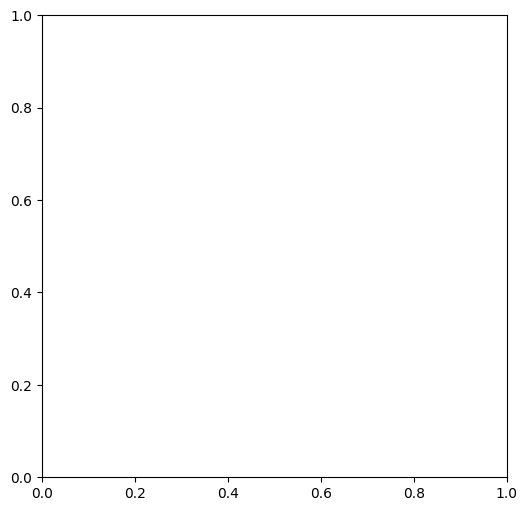

In [ ]:
# debug do codigo
LOG_ODDS_MIN = -10.0
LOG_ODDS_MAX = 10.0

# --- PARÂMETROS DO MAPA ---
MAP_RESOLUTION = 0.1  # 10 cm por célula
MAP_SIZE_X = 10.0      # metros
MAP_SIZE_Y = 10.0      # metros
MAP_ORIGIN_X = -5.0    # Canto inferior esquerdo X
MAP_ORIGIN_Y = -5.0    # Canto inferior esquerdo Y
nrows = int(MAP_SIZE_Y / MAP_RESOLUTION)
ncols = int(MAP_SIZE_X / MAP_RESOLUTION)

# Valores de Log-Odds
l_occ = 0.9
l_free = -0.4
LOG_ODDS_MIN = -5.0
LOG_ODDS_MAX = 5.0


def world_to_grid_xy(wx, wy):
    
    # Converte mundo (x,y) [m] -> índice de célula (ix, iy)
    # origem está no centro do mapa 0,0
    
    ix = int((x - MAP_ORIGIN_X) / MAP_RESOLUTION)
    iy = int((y - MAP_ORIGIN_Y) / MAP_RESOLUTION)
    
    # ix = int((ncols / 2) + (wx / cell_size)) # parentezes modificado, caso tenha problema rever
    # iy = int((nrows / 2) + (wy / cell_size))

    if 0 <= ix < ncols and 0 <= iy < nrows:
        return ix, iy
    return None, None


# Calculo do log_odds (explicar no video)
def update_map_log_odds(log_odds_map, robot_pos, laser_data, l_occ = 1, l_free = -1):
    
    # define a posicao e rotacao do robo
    x, y, theta_r = robot_pos[0], robot_pos[1], robot_pos[2]

    # índice da célula do robô (coluna, linha)
    x_Grid, y_Grid = world_to_grid_xy(x, y)
    
    # caso o robo esteja fora do mapa
    if x_Grid is None or y_Grid is None:
        return log_odds_map

    for d, ang in laser_data: # verificar como esse laiser data está chegando
        # filtrar leituras inválidas
        if d <= 0: 
            continue

        global_ang = theta_r + ang
        
        posi_x = x + d * np.cos(global_ang)
        posi_y = y + d * np.sin(global_ang)

        posi_xGrid, posi_yGrid = world_to_grid_xy(posi_x, posi_y)
        
        # Bresenham: linha de (iy_r, ix_r) até (iy, ix) -> rr (rows), cc (cols)
        rr, cc = line(y_Grid, x_Grid, posi_yGrid, posi_xGrid)
        
        # log oddsl
        if len(rr) > 2:
            # marcar as CELULAS INTERMEDIARIAS como livres (exclui a ultima)
            log_odds_map[rr[1:-1], cc[1:-1]] += l_free

        # marcar a célula de impacto como ocupada
        log_odds_map[posi_yGrid, posi_xGrid] += l_occ

    # clamp para estabilidade numérica
    np.clip(log_odds_map, LOG_ODDS_MIN, LOG_ODDS_MAX, out=log_odds_map)
    return log_odds_map





# tenho que mexer aq
def parse_laser_data(raw):
    """
    Converte retorno do sensor para lista de (d, ang) (metros, radianos no frame do sensor).
    Ajuste aqui se seu Hokuyo retornar outro formato.
    """
    # Caso já seja uma lista de (d, ang):
    if isinstance(raw, (list, tuple)) and len(raw) and isinstance(raw[0], (list, tuple)):
        return [(float(d), float(a)) for d, a in raw]

    # Caso seja apenas uma lista/array de ranges
    if isinstance(raw, (list, np.ndarray)):
        ranges = np.array(raw, dtype=float)
        n = len(ranges)
        if n == 0:
            return []
        # suposição típica: campo de visão -pi/2..+pi/2
        angles = np.linspace(-np.pi/2, np.pi/2, n)
        return [(float(np.ravel(r)[0]), float(a)) for r, a in zip(ranges, angles)]


    # se vazio ou formato desconhecido
    return []





# -----------------------
# Setup CoppeliaSim (exemplo)
# -----------------------
client = RemoteAPIClient()
sim = client.require("sim")
sim.stopSimulation()
time.sleep(0.2)
sim.startSimulation()
sim.setStepping(True)

robotname = "kobuki"
robot = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")  # seu wrapper



# -----------------------
# Config mapa / constantes
# -----------------------
map_size_m = 10.0
cell_size = 0.1                      # m por célula
ncols = int(map_size_m / cell_size)  # cols = eixo X
nrows = int(map_size_m / cell_size)  # rows = eixo Y
grid_origin = np.array([-map_size_m/2, -map_size_m/2])  # world coord do canto inferior esquerdo da célula (0,0)


L = 0.381  
r = 0.0975 

hist = []            
laser_global = []    



# log-odds map: shape (nrows, ncols) -> index como [row, col] = [y, x]
log_odds_map = np.zeros((nrows, ncols))



# colormap: 0=desconhecido(gray), 1=livre(white), 2=ocupado(black)
cmap = ListedColormap(["gray", "white", "black"])

# -----------------------
# Loop principal (visualização em metros)
# -----------------------
plt.ion()
fig, ax = plt.subplots(figsize=(6,6))

robot_path_world = []  # lista de (x,y) world coordinates

for step in range(400):
    sim.step()
    pos = sim.getObjectPosition(robot, -1)
    ori = sim.getObjectOrientation(robot, -1)
    robot_pos = [pos[0], pos[1], ori[2]]
    hist.append([pos[0], pos[1]])

    laser_raw = hokuyo.getSensorData()
    laser_data = parse_laser_data(laser_raw)  # lista (d,ang)
    
    # provavelmente um erro no transform to global
    laser_global.extend(transform_laser_to_global(laser_raw, pos, ori))

    log_odds_map = update_map_log_odds(log_odds_map, robot_pos, laser_data)

    # salvar rastro em coords do mundo
    robot_path_world.append((robot_pos[0], robot_pos[1]))
    
    wl, wr =  controle(laser_raw,r,L)
    sim.setJointTargetVelocity(l_wheel, wl)
    sim.setJointTargetVelocity(r_wheel, wr)

    if step % 50 == 0:
        print("hi")
        prob = 1.0 / (1.0 + np.exp(-log_odds_map))
        grid_vis = np.zeros_like(prob)
        grid_vis[prob < 0.3] = 1  # livre
        grid_vis[prob > 0.7] = 2  # ocupado

        # --- cálculo do extent ---
        nrows, ncols = grid_vis.shape
        extent = [grid_origin[0], grid_origin[0] + ncols * cell_size,
                    grid_origin[1], grid_origin[1] + nrows * cell_size]

        # --- Atualização do plot ---
        ax.clear()
        ax.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

        # desenhar rastro em coordenadas do mundo
        if robot_path_world:
            xs, ys = zip(*robot_path_world)
            ax.plot(xs, ys, color='blue', linewidth=1)

        # desenhar pose do robô
        arrow_scale = cell_size * 5
        ax.arrow(robot_pos[0], robot_pos[1],
                    arrow_scale*np.cos(robot_pos[2]), arrow_scale*np.sin(robot_pos[2]),
                    head_width=cell_size*2, head_length=cell_size*2, fc='red', ec='red')

        
        
        ax.set_title(f"Mapa Parcial - passo {step}")
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_aspect('equal')
        plt.pause(0.001)
        
        

# parar sim
sim.stopSimulation()

# mostrar mapa final
prob = 1.0 / (1.0 + np.exp(-log_odds_map))
grid_vis = np.zeros_like(prob, dtype=np.uint8)
grid_vis[prob < 0.3] = 1
grid_vis[prob > 0.7] = 2

plt.ioff()
fig2, ax2 = plt.subplots(figsize=(7,7))
extent = [grid_origin[0], grid_origin[0] + ncols*cell_size,
          grid_origin[1], grid_origin[1] + nrows*cell_size]
ax2.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

if robot_path_world:
    xs, ys = zip(*robot_path_world)
    ax2.plot(xs, ys, color='blue', linewidth=1)
ax2.arrow(robot_pos[0], robot_pos[1], 0.25*np.cos(robot_pos[2]), 0.25*np.sin(robot_pos[2]),
          head_width=0.08, head_length=0.08, fc='red', ec='red')

ax2.set_title("Mapa Final Explorado")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_aspect('equal')
plt.show()


fig = plt.figure(figsize=(8,8), dpi=100)
ax = fig.add_subplot(111, aspect='equal')
x, y = zip(*hist)
ax.plot(x, y, '--k', label="Trajetória")
ax.plot(x[0], y[0], 'go', markersize=10, label="Início")
ax.plot(x[-1], y[-1], 'ro', markersize=10, label="Fim")


if len(laser_global) > 0:
    lx, ly = zip(*laser_global)
    ax.scatter(lx, ly, s=2, c='r', alpha=0.3, label="Laser")

ax.legend()
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.grid(True)
plt.show()




Precise sensor angles read on attempt 1 (684 laser beam readings)
hi


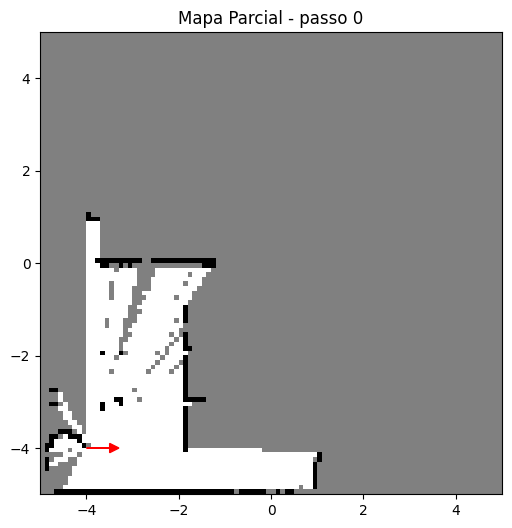

hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
hi
Program ended
Gerando Plot 1 (Scatter)...


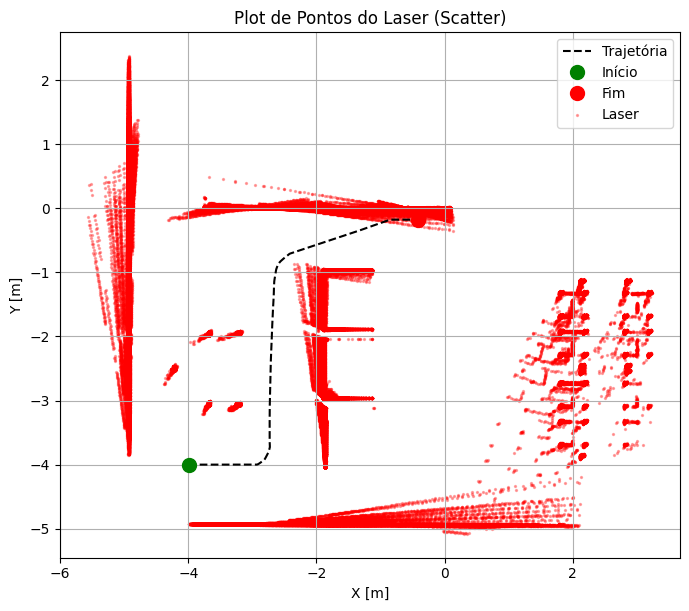

Gerando Plot 2 (Mapa de Grade)...


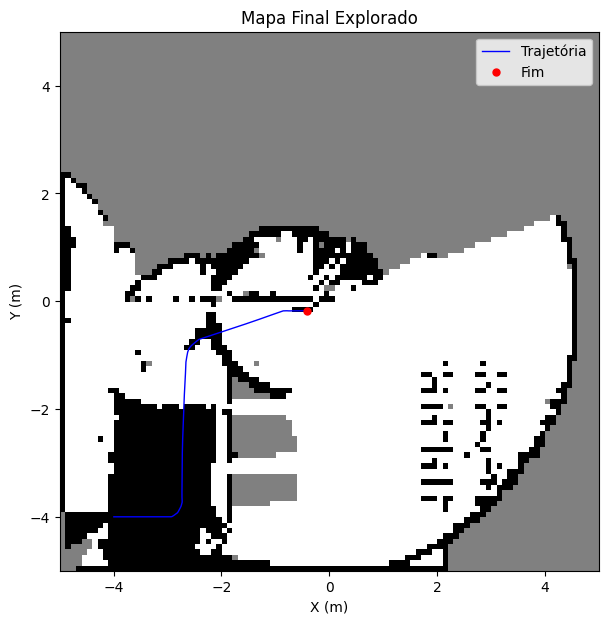

In [12]:
# melhor até o momento 22:51
LOG_ODDS_MIN = -10.0
LOG_ODDS_MAX = 10.0

# --- PARÂMETROS DO MAPA ---
MAP_RESOLUTION = 0.1  # 10 cm por célula (problema quando muda a resolucao)
MAP_SIZE_X = 10.0      # metros
MAP_SIZE_Y = 10.0      # metros
MAP_ORIGIN_X = -5.0    # Canto inferior esquerdo X
MAP_ORIGIN_Y = -5.0    # Canto inferior esquerdo Y
nrows = int(MAP_SIZE_Y / MAP_RESOLUTION)
ncols = int(MAP_SIZE_X / MAP_RESOLUTION)
MAX_SCAN_DISTANCE = 5.0

# Valores de Log-Odds
l_occ = 0.9
l_free = -0.4
LOG_ODDS_MIN = -5.0
LOG_ODDS_MAX = 5.0


def world_to_grid_xy(wx, wy):
    
    # Converte mundo (x,y) [m] -> índice de célula (ix, iy)
    # origem está no centro do mapa 0,0
    
    ix = int((wx - MAP_ORIGIN_X) / MAP_RESOLUTION)
    iy = int((wy - MAP_ORIGIN_Y) / MAP_RESOLUTION)
    
    # ix = int((ncols / 2) + (wx / cell_size)) # parentezes modificado, caso tenha problema rever
    # iy = int((nrows / 2) + (wy / cell_size))

    if 0 <= ix < ncols and 0 <= iy < nrows:
        return ix, iy
    return None, None

MAX_RANGE_THRESHOLD = MAX_SCAN_DISTANCE * 0.99
# Calculo do log_odds (explicar no video)
def update_map_log_odds(log_odds_map, robot_pos, laser_data, l_occ = 0.9, l_free = -0.4):
    
    # define a posicao e rotacao do robo
    x, y, theta_r = robot_pos[0], robot_pos[1], robot_pos[2]

    # índice da célula do robô (coluna, linha)
    x_Grid, y_Grid = world_to_grid_xy(x, y)
    
    # caso o robo esteja fora do mapa
    if x_Grid is None or y_Grid is None:
        return log_odds_map

    for d, ang in laser_data: # verificar como esse laiser data está chegando
        # filtrar leituras inválidas
        if d <= 0.01: 
            continue

        global_ang = theta_r + ang
        
        posi_x = x + d * np.cos(global_ang)
        posi_y = y + d * np.sin(global_ang)

        posi_xGrid, posi_yGrid = world_to_grid_xy(posi_x, posi_y)
        
        if posi_xGrid is None or posi_yGrid is None:
            continue
        
        # Bresenham: linha de (iy_r, ix_r) até (iy, ix) -> rr (rows), cc (cols)
        rr, cc = line(y_Grid, x_Grid, posi_yGrid, posi_xGrid)
        
        # CASO 1: É um obstáculo REAL (distância < max)
        if d < MAX_RANGE_THRESHOLD:
            # Marcar células intermediárias como livres
            if len(rr) > 2:
                log_odds_map[rr[1:-1], cc[1:-1]] += l_free
            
            # Marcar célula de impacto como ocupada
            log_odds_map[posi_yGrid, posi_xGrid] += l_occ
        
        # CASO 2: É um feixe de MAX RANGE (sem obstáculo)
        else:
            # Marcar TODAS as células ao longo do feixe como livres
            # (Exceto a primeira, onde o robô está)
            if len(rr) > 1:
                log_odds_map[rr[1:], cc[1:]] += l_free

        # marcar a célula de impacto como ocupada
        log_odds_map[posi_yGrid, posi_xGrid] += l_occ

    # clamp para estabilidade numérica
    np.clip(log_odds_map, LOG_ODDS_MIN, LOG_ODDS_MAX, out=log_odds_map)
    return log_odds_map





# tenho que mexer aq
def parse_laser_data(raw):
    """
    Converte retorno do sensor para lista de (d, ang) (metros, radianos no frame do sensor).
    Ajuste aqui se seu Hokuyo retornar outro formato.
    """
    # Caso já seja uma lista de (d, ang):
    if isinstance(raw, (list, tuple)) and len(raw) and isinstance(raw[0], (list, tuple)):
        return [(float(d), float(a)) for d, a in raw]

    # Caso seja apenas uma lista/array de ranges
    if isinstance(raw, (list, np.ndarray)):
        ranges = np.array(raw, dtype=float)
        n = len(ranges)
        if n == 0:
            return []
        # suposição típica: campo de visão -pi/2..+pi/2
        angles = np.linspace(-np.pi/2, np.pi/2, n)
        return [(float(np.ravel(r)[0]), float(a)) for r, a in zip(ranges, angles)]


    # se vazio ou formato desconhecido
    return []





# -----------------------
# Setup CoppeliaSim (exemplo)
# -----------------------
client = RemoteAPIClient()
sim = client.require("sim")
sim.stopSimulation()
time.sleep(0.2)
sim.startSimulation()
sim.setStepping(True)

robotname = "kobuki"
robot = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")  # seu wrapper



# -----------------------
# Config mapa / constantes
# -----------------------
map_size_m = 10.0
cell_size = 0.1                      # m por célula
ncols = int(map_size_m / cell_size)  # cols = eixo X
nrows = int(map_size_m / cell_size)  # rows = eixo Y
grid_origin = np.array([-map_size_m/2, -map_size_m/2])  # world coord do canto inferior esquerdo da célula (0,0)


L = 0.381  
r = 0.0975 

hist = []            
laser_global = []    



# log-odds map: shape (nrows, ncols) -> index como [row, col] = [y, x]
log_odds_map = np.zeros((nrows, ncols))



# colormap: 0=desconhecido(gray), 1=livre(white), 2=ocupado(black)
cmap = ListedColormap(["gray", "white", "black"])

# -----------------------
# Loop principal (visualização em metros)
# -----------------------
plt.ion()
fig, ax = plt.subplots(figsize=(6,6))

robot_path_world = []  # lista de (x,y) world coordinates

for step in range(1000):
    sim.step()
    # pos = sim.getObjectPosition(robot, -1)
    # ori = sim.getObjectOrientation(robot, -1)
    
    
    pos = sim.getObjectPosition(robot, sim.handle_world)
    ori = sim.getObjectOrientation(robot, sim.handle_world)
    
    
    hist.append([pos[0], pos[1]])
    
    laser_data = hokuyo.getSensorData() # Retorna [ângulo, dist]
    laser_global.extend(transform_laser_to_global(laser_data, pos, ori))

    robot_pos = [pos[0], pos[1], ori[2]]
    
    
    laser_data_swapped = [[d, a] for a, d in laser_data]
        
    log_odds_map = update_map_log_odds(
        log_odds_map, 
        robot_pos, 
        laser_data_swapped, # Usar os dados com ordem invertida
        l_occ, 
        l_free
    )

    log_odds_map = update_map_log_odds(log_odds_map, robot_pos, laser_data)

    # salvar rastro em coords do mundo
    robot_path_world.append((robot_pos[0], robot_pos[1]))
    
    wl, wr =  controle(laser_raw,r,L)
    sim.setJointTargetVelocity(l_wheel, wl)
    sim.setJointTargetVelocity(r_wheel, wr)

    if step % 50 == 0:
        print("hi")
        prob = 1.0 / (1.0 + np.exp(-log_odds_map))
        grid_vis = np.zeros_like(prob)
        grid_vis[prob < 0.3] = 1  # livre
        grid_vis[prob > 0.7] = 2  # ocupado

        # --- cálculo do extent ---
        nrows, ncols = grid_vis.shape
        extent = [grid_origin[0], grid_origin[0] + ncols * cell_size,
                    grid_origin[1], grid_origin[1] + nrows * cell_size]

        # --- Atualização do plot ---
        ax.clear()
        ax.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

        # desenhar rastro em coordenadas do mundo
        if robot_path_world:
            xs, ys = zip(*robot_path_world)
            ax.plot(xs, ys, color='blue', linewidth=1)

        # desenhar pose do robô
        arrow_scale = cell_size * 5
        ax.arrow(robot_pos[0], robot_pos[1],
                    arrow_scale*np.cos(robot_pos[2]), arrow_scale*np.sin(robot_pos[2]),
                    head_width=cell_size*2, head_length=cell_size*2, fc='red', ec='red')

        
        
        ax.set_title(f"Mapa Parcial - passo {step}")
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_aspect('equal')
        plt.pause(0.001)
        
        

# parar sim
sim.stopSimulation()
print('Program ended')

# -----------------------------------------------------------------
# Plot 1: Scatter (o que você já tinha, gera laiser.png)
# (Este código é do seu original.py e está correto)
# -----------------------------------------------------------------
print("Gerando Plot 1 (Scatter)...")
fig1 = plt.figure(figsize=(8,8), dpi=100)
ax1 = fig1.add_subplot(111, aspect='equal')

# 'hist' é a variável do seu script original.py
x, y = zip(*hist)
ax1.plot(x, y, '--k', label="Trajetória")
ax1.plot(x[0], y[0], 'go', markersize=10, label="Início")
ax1.plot(x[-1], y[-1], 'ro', markersize=10, label="Fim")

# 'laser_global' é a variável do seu script original.py
if len(laser_global) > 0:
    lx, ly = zip(*laser_global)
    ax1.scatter(lx, ly, s=2, c='r', alpha=0.3, label="Laser")

ax1.legend()
ax1.set_xlabel("X [m]")
ax1.set_ylabel("Y [m]")
ax1.grid(True)
ax1.set_title("Plot de Pontos do Laser (Scatter)")
plt.show()


# -----------------------------------------------------------------
# Plot 2: Mapa de Grade (gera grid.png)
# (Este é o código corrigido e integrado)
# -----------------------------------------------------------------
print("Gerando Plot 2 (Mapa de Grade)...")

# Converter log-odds para probabilidade (sua fórmula está correta)
# 'log_odds_map' foi criada e atualizada no seu loop 'while'
prob = 1.0 / (1.0 + np.exp(-log_odds_map)) 

# Criar mapa visual (0=desconhecido, 1=livre, 2=ocupado)
grid_vis = np.zeros_like(prob, dtype=np.uint8) # 0 = desconhecido
grid_vis[prob < 0.45] = 1 # 1 = livre (branco)
grid_vis[prob > 0.55] = 2 # 2 = ocupado (preto)

# Definir um colormap: 0=cinza, 1=branco, 2=preto
# (Substitui a variável 'cmap' indefinida)
cmap = ListedColormap(['#808080', '#FFFFFF', '#000000'])

plt.ioff()
fig2, ax2 = plt.subplots(figsize=(7,7))

# Definir a 'extent' usando as variáveis de configuração do mapa
# (Substitui 'grid_origin', 'ncols', 'cell_size')
extent = [MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X, 
          MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y]
          
ax2.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

# Plotar a trajetória (usando 'hist' ao invés de 'robot_path_world')
if hist:
    xs, ys = zip(*hist)
    ax2.plot(xs, ys, color='blue', linewidth=1, label="Trajetória")
    ax2.plot(xs[-1], ys[-1], 'ro', markersize=5, label="Fim") # Ponto final

# (Removi ax2.arrow() pois 'robot_pos' não está disponível aqui,
# e o ponto final vermelho já marca a posição final)

ax2.set_title("Mapa Final Explorado")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_aspect('equal')
ax2.legend()
plt.show()




In [3]:
# mexendo atualmente
LOG_ODDS_MIN = -10.0
LOG_ODDS_MAX = 10.0

# --- PARÂMETROS DO MAPA ---
MAP_RESOLUTION = 0.1  # 10 cm por célula (problema quando muda a resolucao)
MAP_SIZE_X = 10.0      # metros
MAP_SIZE_Y = 10.0      # metros
MAP_ORIGIN_X = -5.0    # Canto inferior esquerdo X
MAP_ORIGIN_Y = -5.0    # Canto inferior esquerdo Y
nrows = int(MAP_SIZE_Y / MAP_RESOLUTION)
ncols = int(MAP_SIZE_X / MAP_RESOLUTION)
MAX_SCAN_DISTANCE = 5.0

# Valores de Log-Odds
l_occ = 0.9
l_free = -0.4
LOG_ODDS_MIN = -5.0
LOG_ODDS_MAX = 5.0


def world_to_grid_xy(wx, wy):
    
    # Converte mundo (x,y) [m] -> índice de célula (ix, iy)
    # origem está no centro do mapa 0,0
    
    ix = int((wx - MAP_ORIGIN_X) / MAP_RESOLUTION)
    iy = int((wy - MAP_ORIGIN_Y) / MAP_RESOLUTION)
    
    # ix = int((ncols / 2) + (wx / cell_size)) # parentezes modificado, caso tenha problema rever
    # iy = int((nrows / 2) + (wy / cell_size))

    if 0 <= ix < ncols and 0 <= iy < nrows:
        return ix, iy
    return None, None

MAX_RANGE_THRESHOLD = MAX_SCAN_DISTANCE * 0.99
# Calculo do log_odds (explicar no video)
def update_map_log_odds(log_odds_map, robot_pos, laser_data, l_occ = 0.9, l_free = -0.4):
    
    # define a posicao e rotacao do robo
    x, y, theta_r = robot_pos[0], robot_pos[1], robot_pos[2]

    # índice da célula do robô (coluna, linha)
    x_Grid, y_Grid = world_to_grid_xy(x, y)
    
    # caso o robo esteja fora do mapa
    if x_Grid is None or y_Grid is None:
        return log_odds_map

    for d, ang in laser_data: # verificar como esse laiser data está chegando
        # filtrar leituras inválidas
        if d <= 0.01: 
            continue

        global_ang = theta_r + ang
        
        posi_x = x + d * np.cos(global_ang)
        posi_y = y + d * np.sin(global_ang)

        posi_xGrid, posi_yGrid = world_to_grid_xy(posi_x, posi_y)
        
        if posi_xGrid is None or posi_yGrid is None:
            continue
        
        # Bresenham: linha de (iy_r, ix_r) até (iy, ix) -> rr (rows), cc (cols)
        rr, cc = line(y_Grid, x_Grid, posi_yGrid, posi_xGrid)
        
        # CASO 1: É um obstáculo REAL (distância < max)
        if d < MAX_RANGE_THRESHOLD:
            # Marcar células intermediárias como livres
            if len(rr) > 2:
                log_odds_map[rr[1:-1], cc[1:-1]] += l_free
            
            # Marcar célula de impacto como ocupada
            log_odds_map[posi_yGrid, posi_xGrid] += l_occ
        
        # CASO 2: É um feixe de MAX RANGE (sem obstáculo)
        else:
            # Marcar TODAS as células ao longo do feixe como livres
            # (Exceto a primeira, onde o robô está)
            if len(rr) > 1:
                log_odds_map[rr[1:], cc[1:]] += l_free

        # marcar a célula de impacto como ocupada
        # log_odds_map[posi_yGrid, posi_xGrid] += l_occ

    # clamp para estabilidade numérica
    np.clip(log_odds_map, LOG_ODDS_MIN, LOG_ODDS_MAX, out=log_odds_map)
    return log_odds_map





# tenho que mexer aq
def parse_laser_data(raw):
    """
    Converte retorno do sensor para lista de (d, ang) (metros, radianos no frame do sensor).
    Ajuste aqui se seu Hokuyo retornar outro formato.
    """
    # Caso já seja uma lista de (d, ang):
    if isinstance(raw, (list, tuple)) and len(raw) and isinstance(raw[0], (list, tuple)):
        return [(float(d), float(a)) for d, a in raw]

    # Caso seja apenas uma lista/array de ranges
    if isinstance(raw, (list, np.ndarray)):
        ranges = np.array(raw, dtype=float)
        n = len(ranges)
        if n == 0:
            return []
        # suposição típica: campo de visão -pi/2..+pi/2
        angles = np.linspace(-np.pi/2, np.pi/2, n)
        return [(float(np.ravel(r)[0]), float(a)) for r, a in zip(ranges, angles)]


    # se vazio ou formato desconhecido
    return []





# -----------------------
# Setup CoppeliaSim (exemplo)
# -----------------------
client = RemoteAPIClient()
sim = client.require("sim")
sim.stopSimulation()
time.sleep(0.2)
sim.startSimulation()
sim.setStepping(True)

robotname = "kobuki"
robot = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")  # seu wrapper



# -----------------------
# Config mapa / constantes
# -----------------------
map_size_m = 10.0
cell_size = 0.1                      # m por célula
ncols = int(map_size_m / cell_size)  # cols = eixo X
nrows = int(map_size_m / cell_size)  # rows = eixo Y
grid_origin = np.array([-map_size_m/2, -map_size_m/2])  # world coord do canto inferior esquerdo da célula (0,0)


L = 0.381  
r = 0.0975 

hist = []            
laser_global = []    



# log-odds map: shape (nrows, ncols) -> index como [row, col] = [y, x]
log_odds_map = np.zeros((nrows, ncols))



# colormap: 0=desconhecido(gray), 1=livre(white), 2=ocupado(black)
cmap = ListedColormap(["gray", "white", "black"])

# -----------------------
# Loop principal (visualização em metros)
# -----------------------
plt.ion()
fig, ax = plt.subplots(figsize=(6,6))

robot_path_world = []  # lista de (x,y) world coordinates

for step in range(1000):
    sim.step()
    # pos = sim.getObjectPosition(robot, -1)
    # ori = sim.getObjectOrientation(robot, -1)
    
    
    pos = sim.getObjectPosition(robot, sim.handle_world)
    ori = sim.getObjectOrientation(robot, sim.handle_world)
    
    
    hist.append([pos[0], pos[1]])
    
    laser_data = hokuyo.getSensorData() # Retorna [ângulo, dist]
    laser_global.extend(transform_laser_to_global(laser_data, pos, ori))

    robot_pos = [pos[0], pos[1], ori[2]]
    
    
    laser_data_swapped = [[d, a] for a, d in laser_data]
        
    log_odds_map = update_map_log_odds(
        log_odds_map, 
        robot_pos, 
        laser_data_swapped, # Usar os dados com ordem invertida
        l_occ, 
        l_free
    )

    # log_odds_map = update_map_log_odds(log_odds_map, robot_pos, laser_data)

    # salvar rastro em coords do mundo
    robot_path_world.append((robot_pos[0], robot_pos[1]))
    
    wl, wr =  controle(laser_raw,r,L)
    sim.setJointTargetVelocity(l_wheel, wl)
    sim.setJointTargetVelocity(r_wheel, wr)

    if step % 50 == 0:
        print("hi")
        prob = 1.0 / (1.0 + np.exp(-log_odds_map))
        grid_vis = np.zeros_like(prob)
        grid_vis[prob < 0.3] = 1  # livre
        grid_vis[prob > 0.7] = 2  # ocupado

        # --- cálculo do extent ---
        nrows, ncols = grid_vis.shape
        extent = [grid_origin[0], grid_origin[0] + ncols * cell_size,
                    grid_origin[1], grid_origin[1] + nrows * cell_size]

        # --- Atualização do plot ---
        ax.clear()
        ax.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

        # desenhar rastro em coordenadas do mundo
        if robot_path_world:
            xs, ys = zip(*robot_path_world)
            ax.plot(xs, ys, color='blue', linewidth=1)

        # desenhar pose do robô
        arrow_scale = cell_size * 5
        ax.arrow(robot_pos[0], robot_pos[1],
                    arrow_scale*np.cos(robot_pos[2]), arrow_scale*np.sin(robot_pos[2]),
                    head_width=cell_size*2, head_length=cell_size*2, fc='red', ec='red')

        
        
        ax.set_title(f"Mapa Parcial - passo {step}")
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_aspect('equal')
        plt.pause(0.001)
        
        

# parar sim
sim.stopSimulation()
print('Program ended')

# -----------------------------------------------------------------
# Plot 1: Scatter (o que você já tinha, gera laiser.png)
# (Este código é do seu original.py e está correto)
# -----------------------------------------------------------------
print("Gerando Plot 1 (Scatter)...")
fig1 = plt.figure(figsize=(8,8), dpi=100)
ax1 = fig1.add_subplot(111, aspect='equal')

# 'hist' é a variável do seu script original.py
x, y = zip(*hist)
ax1.plot(x, y, '--k', label="Trajetória")
ax1.plot(x[0], y[0], 'go', markersize=10, label="Início")
ax1.plot(x[-1], y[-1], 'ro', markersize=10, label="Fim")

# 'laser_global' é a variável do seu script original.py
if len(laser_global) > 0:
    lx, ly = zip(*laser_global)
    ax1.scatter(lx, ly, s=2, c='r', alpha=0.3, label="Laser")

ax1.legend()
ax1.set_xlabel("X [m]")
ax1.set_ylabel("Y [m]")
ax1.grid(True)
ax1.set_title("Plot de Pontos do Laser (Scatter)")
plt.show()


# -----------------------------------------------------------------
# Plot 2: Mapa de Grade (gera grid.png)
# (Este é o código corrigido e integrado)
# -----------------------------------------------------------------
print("Gerando Plot 2 (Mapa de Grade)...")

# Converter log-odds para probabilidade (sua fórmula está correta)
# 'log_odds_map' foi criada e atualizada no seu loop 'while'
prob = 1.0 / (1.0 + np.exp(-log_odds_map)) 

# Criar mapa visual (0=desconhecido, 1=livre, 2=ocupado)
grid_vis = np.zeros_like(prob, dtype=np.uint8) # 0 = desconhecido
grid_vis[prob < 0.45] = 1 # 1 = livre (branco)
grid_vis[prob > 0.55] = 2 # 2 = ocupado (preto)

# Definir um colormap: 0=cinza, 1=branco, 2=preto
# (Substitui a variável 'cmap' indefinida)
cmap = ListedColormap(['#808080', '#FFFFFF', '#000000'])

plt.ioff()
fig2, ax2 = plt.subplots(figsize=(7,7))

# Definir a 'extent' usando as variáveis de configuração do mapa
# (Substitui 'grid_origin', 'ncols', 'cell_size')
extent = [MAP_ORIGIN_X, MAP_ORIGIN_X + MAP_SIZE_X, 
          MAP_ORIGIN_Y, MAP_ORIGIN_Y + MAP_SIZE_Y]
          
ax2.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

# Plotar a trajetória (usando 'hist' ao invés de 'robot_path_world')
if hist:
    xs, ys = zip(*hist)
    ax2.plot(xs, ys, color='blue', linewidth=1, label="Trajetória")
    ax2.plot(xs[-1], ys[-1], 'ro', markersize=5, label="Fim") # Ponto final

# (Removi ax2.arrow() pois 'robot_pos' não está disponível aqui,
# e o ponto final vermelho já marca a posição final)

ax2.set_title("Mapa Final Explorado")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_aspect('equal')
ax2.legend()
plt.show()




NameError: name 'HokuyoSensorSim' is not defined

Precise sensor angles read on attempt 1 (684 laser beam readings)
hi


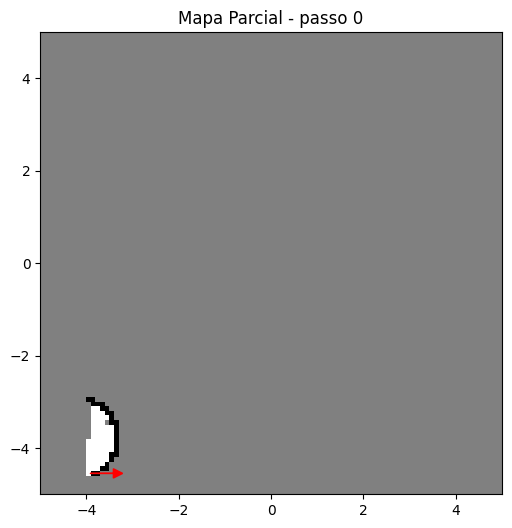

hi
hi
hi
hi
hi
hi
hi
hi
hi


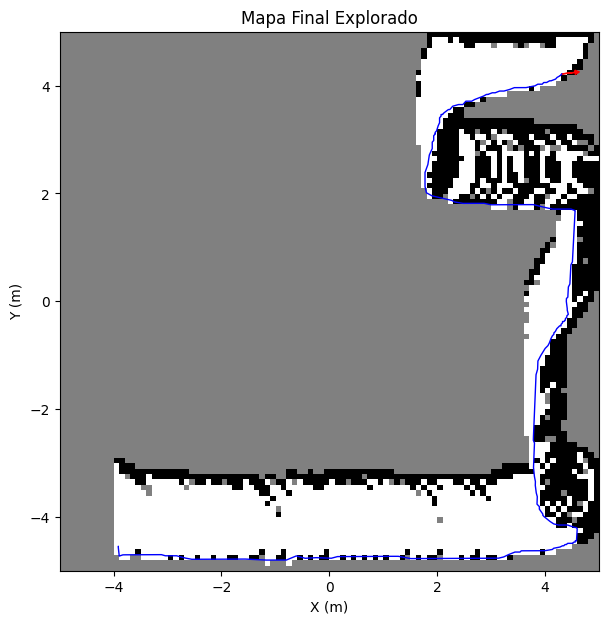

In [ ]:
LOG_ODDS_MIN = -10.0
LOG_ODDS_MAX = 10.0
SENSOR_OFFSET = 0.0  # ajuste aqui (rad). Experimente 0, +pi/2, -pi/2 conforme montagem do sensor
MAX_RANGE = 5.0  # alcance máximo do laser (m)



# -----------------------
# Utils
# -----------------------
def world_to_grid_xy(wx, wy):
    
    # Converte mundo (x,y) [m] -> índice de célula (ix, iy)
    # origem está no centro do mapa
    
    ix = int(ncols / 2 + wx / cell_size)
    iy = int(nrows / 2 + wy / cell_size)

    if 0 <= ix < ncols and 0 <= iy < nrows:
        return ix, iy
    return None, None


def parse_laser_data(raw):
    """
    Converte retorno do sensor para lista de (d, ang) (metros, radianos no frame do sensor).
    Ajuste aqui se seu Hokuyo retornar outro formato.
    """
    # Caso já seja uma lista de (d, ang):
    if isinstance(raw, (list, tuple)) and len(raw) and isinstance(raw[0], (list, tuple)):
        return [(float(d), float(a)) for d, a in raw]

    # Caso seja apenas uma lista/array de ranges
    if isinstance(raw, (list, np.ndarray)):
        ranges = np.array(raw, dtype=float)
        n = len(ranges)
        if n == 0:
            return []
        # suposição típica: campo de visão -pi/2..+pi/2
        angles = np.linspace(-np.pi/2, np.pi/2, n)
        return [(float(np.ravel(r)[0]), float(a)) for r, a in zip(ranges, angles)]


    # se vazio ou formato desconhecido
    return []

# -----------------------
# Função de atualização log-odds (corrigida)
# -----------------------
def update_map_log_odds(log_odds_map, robot_pos, laser_data,
                        l_occ=0.9, l_free=-0.4, sensor_offset=SENSOR_OFFSET, max_range=MAX_RANGE):
    """
    robot_pos: [x,y,theta] (m, rad) no frame world
    laser_data: lista de (d, ang_sensor) -> d[m], ang_sensor[rad] no frame do sensor
    Atualiza log_odds_map (shape nrows x ncols) indexado por [row, col] = [iy, ix].
    """
    x_r, y_r, theta_r = robot_pos[0], robot_pos[1], robot_pos[2]

    # índice da célula do robô (coluna, linha)
    ix_r, iy_r = world_to_grid_xy(x_r, y_r)
    if ix_r is None:
        return log_odds_map

    for d, ang in laser_data:
        # filtrar leituras inválidas
        if d <= 0 or d > max_range:
            continue

        global_ang = theta_r + ang + sensor_offset
        wx = x_r + d * np.cos(global_ang)
        wy = y_r + d * np.sin(global_ang)

        ix, iy = world_to_grid_xy(wx, wy)
        if ix is None or iy is None:
            # ponto fora do mapa -> opcional: projetar até a borda
            continue

        # Bresenham: linha de (iy_r, ix_r) até (iy, ix) -> rr (rows), cc (cols)
        rr, cc = line(iy_r, ix_r, iy, ix)
        if len(rr) > 1:
            # marcar as CELULAS INTERMEDIARIAS como livres (exclui a ultima)
            log_odds_map[rr[:-1], cc[:-1]] += l_free

        # marcar a célula de impacto como ocupada
        log_odds_map[iy, ix] += l_occ

    # clamp para estabilidade numérica
    np.clip(log_odds_map, LOG_ODDS_MIN, LOG_ODDS_MAX, out=log_odds_map)
    return log_odds_map

# -----------------------
# Setup CoppeliaSim (exemplo)
# -----------------------
client = RemoteAPIClient()
sim = client.require("sim")
sim.stopSimulation()
time.sleep(0.2)
sim.startSimulation()
sim.setStepping(True)

robotname = "kobuki"
robot = sim.getObject(f'/{robotname}')
left_motor = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
right_motor = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")  # seu wrapper



# -----------------------
# Config mapa / constantes
# -----------------------
map_size_m = 10.0
cell_size = 0.1                      # m por célula
ncols = int(map_size_m / cell_size)  # cols = eixo X
nrows = int(map_size_m / cell_size)  # rows = eixo Y
grid_origin = np.array([-map_size_m/2, -map_size_m/2])  # world coord do canto inferior esquerdo da célula (0,0)

# log-odds map: shape (nrows, ncols) -> index como [row, col] = [y, x]
log_odds_map = np.zeros((nrows, ncols))



# colormap: 0=desconhecido(gray), 1=livre(white), 2=ocupado(black)
cmap = ListedColormap(["gray", "white", "black"])

# -----------------------
# Loop principal (visualização em metros)
# -----------------------
plt.ion()
fig, ax = plt.subplots(figsize=(6,6))

robot_path_world = []  # lista de (x,y) world coordinates

for step in range(500):
    sim.step()
    pos = sim.getObjectPosition(robot, -1)
    ori = sim.getObjectOrientation(robot, -1)
    robot_pos = [pos[0], pos[1], ori[2]]

    laser_data = hokuyo.getSensorData()
    laser_data = parse_laser_data(laser_data)  # lista (d,ang)

    log_odds_map = update_map_log_odds(log_odds_map, robot_pos, laser_data)

    # salvar rastro em coords do mundo
    robot_path_world.append((robot_pos[0], robot_pos[1]))

    if step % 50 == 0:
        print("hi")
        prob = 1.0 / (1.0 + np.exp(-log_odds_map))
        grid_vis = np.zeros_like(prob)
        grid_vis[prob < 0.3] = 1  # livre
        grid_vis[prob > 0.7] = 2  # ocupado

        # --- cálculo do extent ---
        nrows, ncols = grid_vis.shape
        extent = [grid_origin[0], grid_origin[0] + ncols * cell_size,
                    grid_origin[1], grid_origin[1] + nrows * cell_size]

        # --- Atualização do plot ---
        ax.clear()
        ax.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

        # desenhar rastro em coordenadas do mundo
        if robot_path_world:
            xs, ys = zip(*robot_path_world)
            ax.plot(xs, ys, color='blue', linewidth=1)

        # desenhar pose do robô
        arrow_scale = cell_size * 5
        ax.arrow(robot_pos[0], robot_pos[1],
                    arrow_scale*np.cos(robot_pos[2]), arrow_scale*np.sin(robot_pos[2]),
                    head_width=cell_size*2, head_length=cell_size*2, fc='red', ec='red')

        ax.set_title(f"Mapa Parcial - passo {step}")
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_aspect('equal')
        plt.pause(0.001)

# parar sim
sim.stopSimulation()

# mostrar mapa final
prob = 1.0 / (1.0 + np.exp(-log_odds_map))
grid_vis = np.zeros_like(prob, dtype=np.uint8)
grid_vis[prob < 0.3] = 1
grid_vis[prob > 0.7] = 2

plt.ioff()
fig2, ax2 = plt.subplots(figsize=(7,7))
extent = [grid_origin[0], grid_origin[0] + ncols*cell_size,
          grid_origin[1], grid_origin[1] + nrows*cell_size]
ax2.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

if robot_path_world:
    xs, ys = zip(*robot_path_world)
    ax2.plot(xs, ys, color='blue', linewidth=1)
ax2.arrow(robot_pos[0], robot_pos[1], 0.25*np.cos(robot_pos[2]), 0.25*np.sin(robot_pos[2]),
          head_width=0.08, head_length=0.08, fc='red', ec='red')

ax2.set_title("Mapa Final Explorado")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_aspect('equal')
plt.show()


Program started
Simulation time: 0.05 [s]
Precise sensor angles read on attempt 1 (684 laser beam readings)
Simulation time: 0.10 [s]
Simulation time: 0.15 [s]
Simulation time: 0.20 [s]
Simulation time: 0.25 [s]
Simulation time: 0.30 [s]
Simulation time: 0.35 [s]
Simulation time: 0.40 [s]
Simulation time: 0.45 [s]
Simulation time: 0.50 [s]
Simulation time: 0.55 [s]
Simulation time: 0.60 [s]
Simulation time: 0.65 [s]
Simulation time: 0.70 [s]
Simulation time: 0.75 [s]
Simulation time: 0.80 [s]
Simulation time: 0.85 [s]
Simulation time: 0.90 [s]
Simulation time: 0.95 [s]
Simulation time: 1.00 [s]
Simulation time: 1.05 [s]
Simulation time: 1.10 [s]
Simulation time: 1.15 [s]
Simulation time: 1.20 [s]
Simulation time: 1.25 [s]
Simulation time: 1.30 [s]
Simulation time: 1.35 [s]
Simulation time: 1.40 [s]
Simulation time: 1.45 [s]
Simulation time: 1.50 [s]
Simulation time: 1.55 [s]
Simulation time: 1.60 [s]
Simulation time: 1.65 [s]
Simulation time: 1.70 [s]
Simulation time: 1.75 [s]
Simulati

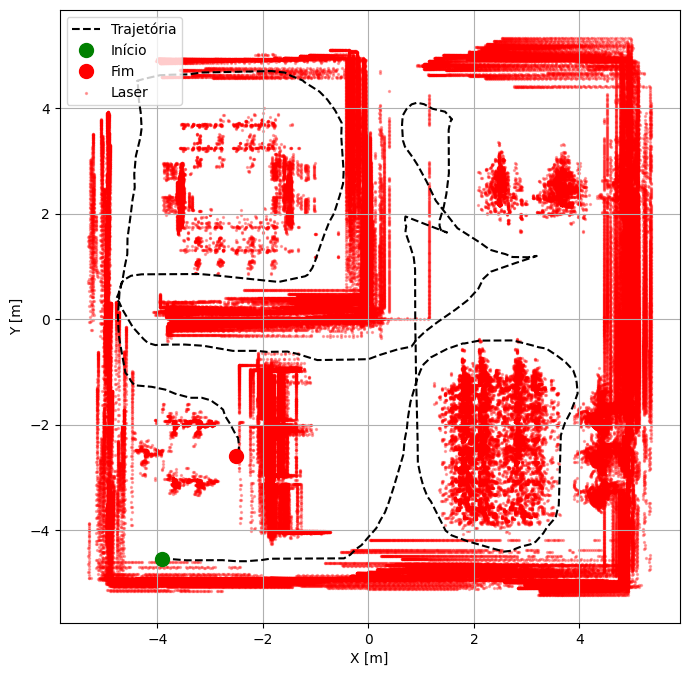

In [95]:
# plot do laizer funcional
print('Program started')

try:
    # Conectar ao servidor
    client = RemoteAPIClient()
    sim = client.require("sim")
    sim.setStepping(True)

    # Handles
    robotname = "kobuki"
    robotHandle = sim.getObject(f'/{robotname}')
    l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
    r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
    
    # Reinicia simulação
    initial_sim_state = sim.getSimulationState()
    if initial_sim_state != 0:
        sim.stopSimulation()
        time.sleep(1)

    sim.startSimulation()
    sim.step()

    # Sensor Hokuyo
    hokuyo_sensor = HokuyoSensorSim(sim, "/" + robotname + "/fastHokuyo")

    L = 0.381  
    r = 0.0975 

    hist = []            
    laser_global = []    

    while (sim_time := sim.getSimulationTime()) < 20:
        print(f"Simulation time: {sim_time:.2f} [s]")

    
        posRobo = sim.getObjectPosition(robotHandle, sim.handle_world)
        oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)

        hist.append([posRobo[0], posRobo[1]])

        # Leitura do laser
        laser_data = hokuyo_sensor.getSensorData()
        laser_global.extend(transform_laser_to_global(laser_data, posRobo, oriRobo))

        # Controle simples de desvio
        v, w = 0, 0
        frente = int(len(laser_data) / 2)
        lado_direito = int(len(laser_data) * 1 / 4)
        lado_esquerdo = int(len(laser_data) * 3 / 4)

        if laser_data[frente, 1] > 2:
            v = .5
            w = 0
        elif laser_data[lado_direito, 1] > 1:
            v = 0
            w = np.deg2rad(-45)
        elif laser_data[lado_esquerdo, 1] > 1:
            v = 0
            w = np.deg2rad(45)

        # Modelo cinemático
        wl = v / r - (w * L) / (2 * r)
        wr = v / r + (w * L) / (2 * r)

        sim.setJointTargetVelocity(l_wheel, wl)
        sim.setJointTargetVelocity(r_wheel, wr)

        sim.step()

    
    sim.setJointTargetVelocity(r_wheel, 0)
    sim.setJointTargetVelocity(l_wheel, 0)

except Exception as e:
    print(f"An error occurred: {e}")


sim.stopSimulation()
print('Program ended')


fig = plt.figure(figsize=(8,8), dpi=100)
ax = fig.add_subplot(111, aspect='equal')
x, y = zip(*hist)
ax.plot(x, y, '--k', label="Trajetória")
ax.plot(x[0], y[0], 'go', markersize=10, label="Início")
ax.plot(x[-1], y[-1], 'ro', markersize=10, label="Fim")


if len(laser_global) > 0:
    lx, ly = zip(*laser_global)
    ax.scatter(lx, ly, s=2, c='r', alpha=0.3, label="Laser")

ax.legend()
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.grid(True)
plt.show()


### Daniel

In [62]:
# MOdificações daniel

# import matplotlib.pyplot as plt
# import numpy as np
# import math
# from typing import Dict, List, Tuple, Optional
# from coppeliasim_zmqremoteapi_client import RemoteAPIClient
# import time

# class HokuyoSensorSim:
#     """
#     Simulates a Hokuyo laser sensor in CoppeliaSim.

#     Reused from TP1 - Provides interface to interact with a simulated Hokuyo sensor.
#     This sensor uses vision sensors to simulate laser range measurements.

#     Attributes:
#         _sim: CoppeliaSim API object
#         _base_name: Name of the sensor base object
#         _is_range_data: If True, returns [angle, distance]; else returns [x, y, z] points
#         _base_obj: Handle of the base object
#         _vision_sensors_obj: List of vision sensor handles
#     """

#     def __init__(self, sim, base_name: str, is_range_data: bool = True):
#         """
#         Initialize Hokuyo sensor interface.
#         Args:
#             sim: CoppeliaSim API object
#             base_name: Name of the sensor base (must contain 'fastHokuyo')
#             is_range_data: If True, returns [angle, distance]; else returns 3D points
#         """
#         self._sim = sim
#         self._base_name = base_name
#         self._is_range_data = is_range_data

#         if "fastHokuyo" not in base_name:
#             raise ValueError(
#                 f"ERROR: 'fastHokuyo' must be in the base object name. "
#                 f"Example: '/Kobuki/fastHokuyo'"
#             )

#         self._base_obj = sim.getObject(base_name)
#         if self._base_obj == -1:
#             raise ValueError(f"ERROR: Base object '{base_name}' not found in simulation")

#         vision_sensor_template = "{}/fastHokuyo_sensor{}"
#         try:
#             self._vision_sensors_obj = [
#                 sim.getObject(vision_sensor_template.format(base_name, 1)),
#                 sim.getObject(vision_sensor_template.format(base_name, 2)),
#             ]
#             if any(obj == -1 for obj in self._vision_sensors_obj):
#                 self._vision_sensors_obj = []
#         except:
#             self._vision_sensors_obj = []

#         print(f"[OK] Initialized Hokuyo sensor: {base_name}")
#         print(f"     Using buffer signal API for angle/range data")

#     def get_is_range_data(self) -> bool:
#         """Returns whether sensor returns range data or point data."""
#         return self._is_range_data

#     def set_is_range_data(self, is_range_data: bool) -> None:
#         """Set whether sensor should return range data or point data."""
#         self._is_range_data = is_range_data

#     def getSensorData(self, debug: bool = False) -> np.ndarray:
#         """
#         Retrieve sensor data from fastHokuyo using buffer signals.
#         CRITICAL FIX: Read angles directly from sensor (calculated by fastHokuyo).
#         This avoids incremental angle calculation errors that caused scattered points.
#         - Vision sensors use tangent-based unprojection from depth images
#         - Angles are NOT linearly spaced (perspective projection distortion)
#         - FastHokuyo Lua script calculates correct angles using atan2(x, z)
#         CoppeliaSim buffer signals docs
#         Args:
#             debug: Enable detailed debug logging for sensor data pipeline

#         Returns:
#             np.ndarray: Nx2 array of [angle, distance] for range data
#                        or Nx3 array of [x, y, z] for point data

#         Raises:
#             ValueError: If no valid sensor data could be obtained
#         """
#         try:
#             range_buffer = self._sim.getBufferProperty(
#                 self._sim.handle_scene,
#                 "signal.hokuyo_range_data",
#                 {'noError': True}  # Silent errors for cleaner output
#             )
#             angle_buffer = self._sim.getBufferProperty(
#                 self._sim.handle_scene,
#                 "signal.hokuyo_angle_data",
#                 {'noError': True}
#             )

#             if not range_buffer or not angle_buffer:
#                 raise ValueError(
#                     "ERROR: Hokuyo signals not available. "
#                     "Check that fastHokuyo.lua exports both range_data and angle_data signals."
#                 )

#             ranges = self._sim.unpackFloatTable(range_buffer)
#             angles = self._sim.unpackFloatTable(angle_buffer)

#             if len(ranges) != len(angles):
#                 raise ValueError(
#                     f"ERROR: Angle/range count mismatch: "
#                     f"{len(angles)} angles vs {len(ranges)} ranges"
#                 )

#             if debug:
#                 print(f"\n[DEBUG] HokuyoSensorSim.getSensorData()")
#                 print(f"  Total points: {len(ranges)}")
#                 print(f"  Angle range: [{np.rad2deg(min(angles)):.1f}°, "
#                       f"{np.rad2deg(max(angles)):.1f}°]")
#                 print(f"  Distance range: [{min(ranges):.3f}m, {max(ranges):.3f}m]")

#             if self._is_range_data:
#                 return np.column_stack([angles, ranges])
#             else:
#                 x = np.array(ranges) * np.cos(np.array(angles))
#                 y = np.array(ranges) * np.sin(np.array(angles))
#                 z = np.zeros(len(ranges))
#                 return np.column_stack([x, y, z])

#         except Exception as e:
#             if debug:
#                 import traceback
#                 traceback.print_exc()
#             raise ValueError(f"ERROR: Failed to process laser data: {e}")

# #desibled, in for reference
# def get_noisy_laser_data(hokuyo_sensor: HokuyoSensorSim,
#                         distance_noise_std: float = 0.0,
#                         angle_noise_std: float = 0.0,
#                         max_valid_range: float = 4.9) -> np.ndarray:  # Filter max range
#     """
#     Get laser data with added Gaussian noise and invalid reading filtering (as required by TP3).

#     Args:
#         hokuyo_sensor: HokuyoSensorSim instance
#         distance_noise_std: Standard deviation of distance noise (meters) - DEFAULT: 0.0 (disabled)
#         angle_noise_std: Standard deviation of angle noise (radians) - DEFAULT: 0.0 (disabled)
#         max_valid_range: Maximum valid range in meters (readings >= this are filtered out)
#                         DEFAULT: 4.9m (slightly below sensor's 5m max to catch max-range returns)

#     Returns:
#         np.ndarray: Nx2 array of [angle, distance] with noise added and invalid readings removed

#     Example:
#         # Sensor max range is 5.0m
#         # Raw data might contain: [..., [0.5, 5.0], [0.6, 2.3], [0.7, 5.0], ...]
#         # Filtered data returns: [..., [0.6, 2.3], ...]  (max-range readings removed)
#     """
#     laser_data = hokuyo_sensor.getSensorData()
#     valid_mask = laser_data[:, 1] < max_valid_range
#     laser_data_filtered = laser_data[valid_mask]

#     num_filtered = len(laser_data) - len(laser_data_filtered)
#     if num_filtered > 0:
#         pass  # Silent filtering to avoid spam

#     if len(laser_data_filtered) == 0:
#         return np.array([]).reshape(0, 2)

#     if distance_noise_std == 0.0 and angle_noise_std == 0.0:
#         return laser_data_filtered
#     noisy_data = laser_data_filtered.copy()

#     if angle_noise_std > 0.0:
#         angle_noise = np.random.normal(0, angle_noise_std, size=len(laser_data_filtered))
#         noisy_data[:, 0] += angle_noise

#     if distance_noise_std > 0.0:
#         distance_noise = np.random.normal(0, distance_noise_std, size=len(laser_data_filtered))
#         noisy_data[:, 1] += distance_noise

#         noisy_data[:, 1] = np.maximum(noisy_data[:, 1], 0.01)

#     return noisy_data


def transform_laser_to_global(robot_pose: Tuple[np.ndarray, np.ndarray],
                              laser_data: np.ndarray,
                              laser_to_robot_transform: Optional[np.ndarray] = None) -> np.ndarray:
    """
    Transform laser sensor data from sensor frame to global (world) frame.

    Args:
        robot_pose: Tuple of (position, euler_angles) of robot in world frame
                   position: [x, y, z] in meters
                   euler_angles: [roll, pitch, yaw] in radians
        laser_data: Nx2 array of [angle, distance] from laser sensor in POLAR format
                   angle: beam angle relative to robot heading (radians)
                   distance: range measurement (meters)
        laser_to_robot_transform: IGNORED (laser assumed at robot center for 2D mapping)

    Returns:
        np.ndarray: Nx2 array of [x, y] points in world frame

    """
    robot_position, robot_orientation = robot_pose
    x_robot = robot_position[0]
    y_robot = robot_position[1]
    theta_robot = robot_orientation[2]  # Yaw angle (Z-rotation)
    world_points = []

    for beam_angle, range_measurement in laser_data:
        world_angle = theta_robot + beam_angle

        x_world = x_robot + range_measurement * np.cos(world_angle)
        y_world = y_robot + range_measurement * np.sin(world_angle)

        world_points.append([x_world, y_world])

    return np.array(world_points)  # Returns Nx2 array


def analyze_mapping_alignment(robot_trajectory, mapper, laser_points_global):
    """
    Comprehensive analysis of grid-scene alignment.
    
    This function checks if your grid origin and size are correctly configured
    for the actual robot movement and laser data collected.
    """
    print("\n" + "="*70)
    print("OCCUPANCY GRID ALIGNMENT ANALYSIS")
    print("="*70)
    
    # Convert trajectory to array
    traj = np.array(robot_trajectory)
    laser_pts = np.array(laser_points_global)
    
    # 1. ROBOT TRAJECTORY BOUNDS
    print("\n1. ROBOT TRAJECTORY ANALYSIS")
    print("-" * 70)
    x_min_traj, x_max_traj = traj[:, 0].min(), traj[:, 0].max()
    y_min_traj, y_max_traj = traj[:, 1].min(), traj[:, 1].max()
    print(f"   X range: [{x_min_traj:7.3f}, {x_max_traj:7.3f}] m  (span: {x_max_traj-x_min_traj:.3f}m)")
    print(f"   Y range: [{y_min_traj:7.3f}, {y_max_traj:7.3f}] m  (span: {y_max_traj-y_min_traj:.3f}m)")
    
    # 2. LASER POINTS BOUNDS
    print("\n2. LASER POINTS ANALYSIS")
    print("-" * 70)
    x_min_laser, x_max_laser = laser_pts[:, 0].min(), laser_pts[:, 0].max()
    y_min_laser, y_max_laser = laser_pts[:, 1].min(), laser_pts[:, 1].max()
    print(f"   X range: [{x_min_laser:7.3f}, {x_max_laser:7.3f}] m  (span: {x_max_laser-x_min_laser:.3f}m)")
    print(f"   Y range: [{y_min_laser:7.3f}, {y_max_laser:7.3f}] m  (span: {y_max_laser-y_min_laser:.3f}m)")
    
    # 3. GRID CONFIGURATION
    print("\n3. GRID CONFIGURATION")
    print("-" * 70)
    grid_x_min = mapper.origin[0]
    grid_x_max = mapper.origin[0] + mapper.map_size[0]
    grid_y_min = mapper.origin[1]
    grid_y_max = mapper.origin[1] + mapper.map_size[1]
    print(f"   Origin:     ({mapper.origin[0]:7.3f}, {mapper.origin[1]:7.3f}) m")
    print(f"   Size:       ({mapper.map_size[0]:7.3f}, {mapper.map_size[1]:7.3f}) m")
    print(f"   Cell size:   {mapper.cell_size:.4f} m")
    print(f"   Grid shape:  {mapper.grid_height} × {mapper.grid_width} cells")
    print(f"   X coverage: [{grid_x_min:7.3f}, {grid_x_max:7.3f}] m")
    print(f"   Y coverage: [{grid_y_min:7.3f}, {grid_y_max:7.3f}] m")
    
    # 4. ALIGNMENT CHECK
    print("\n4. ALIGNMENT VERIFICATION")
    print("-" * 70)
    
    # Check trajectory coverage
    traj_x_in_grid = (traj[:, 0] >= grid_x_min) & (traj[:, 0] <= grid_x_max)
    traj_y_in_grid = (traj[:, 1] >= grid_y_min) & (traj[:, 1] <= grid_y_max)
    traj_in_grid = traj_x_in_grid & traj_y_in_grid
    traj_coverage = 100 * traj_in_grid.sum() / len(traj)
    
    print(f"   Trajectory coverage:  {traj_coverage:.1f}% within grid bounds")
    if traj_coverage < 80:
        print("   ⚠️  WARNING: Less than 80% of robot path is inside grid!")
        print("   → Consider adjusting MAP_ORIGIN or MAP_SIZE_M")
    else:
        print("   ✅ Good coverage!")
    
    # Check laser points coverage
    laser_x_in_grid = (laser_pts[:, 0] >= grid_x_min) & (laser_pts[:, 0] <= grid_x_max)
    laser_y_in_grid = (laser_pts[:, 1] >= grid_y_min) & (laser_pts[:, 1] <= grid_y_max)
    laser_in_grid = laser_x_in_grid & laser_y_in_grid
    laser_coverage = 100 * laser_in_grid.sum() / len(laser_pts)
    
    print(f"   Laser points coverage: {laser_coverage:.1f}% within grid bounds")
    if laser_coverage < 70:
        print("   ⚠️  WARNING: Less than 70% of laser data is inside grid!")
        print("   → Grid might be too small or misaligned")
    else:
        print("   ✅ Good coverage!")
    
    # 5. RECOMMENDED ADJUSTMENTS
    print("\n5. RECOMMENDED GRID CONFIGURATION")
    print("-" * 70)
    
    # Calculate optimal grid to cover all data
    data_x_min = min(x_min_traj, x_min_laser) - 1.0  # Add 1m margin
    data_x_max = max(x_max_traj, x_max_laser) + 1.0
    data_y_min = min(y_min_traj, y_min_laser) - 1.0
    data_y_max = max(y_max_traj, y_max_laser) + 1.0
    
    # Round to nice values
    suggested_origin_x = np.floor(data_x_min)
    suggested_origin_y = np.floor(data_y_min)
    suggested_size_x = np.ceil(data_x_max - suggested_origin_x)
    suggested_size_y = np.ceil(data_y_max - suggested_origin_y)
    
    print(f"   Based on actual data range:")
    print(f"   MAP_ORIGIN = ({suggested_origin_x:.1f}, {suggested_origin_y:.1f})")
    print(f"   MAP_SIZE_M = ({suggested_size_x:.1f}, {suggested_size_y:.1f})")
    print(f"   (Covers: X=[{suggested_origin_x:.1f}, {suggested_origin_x+suggested_size_x:.1f}], "
          f"Y=[{suggested_origin_y:.1f}, {suggested_origin_y+suggested_size_y:.1f}])")
    
    # Check if current grid is adequate
    if traj_coverage >= 80 and laser_coverage >= 70:
        print("\n   ✅ CURRENT GRID CONFIGURATION IS ADEQUATE")
        print("   If you're seeing distortions, the problem is NOT grid alignment.")
        print("   Check: sensor calibration, pose accuracy, or other issues.")
    else:
        print("\n   ⚠️  GRID CONFIGURATION NEEDS ADJUSTMENT")
        print("   Update your notebook with the recommended values above.")
    
    # 6. VISUAL DIAGNOSTIC
    print("\n6. GENERATING DIAGNOSTIC PLOT...")
    print("-" * 70)
    
    fig, ax = plt.subplots(figsize=(14, 14))
    
    # Plot grid bounds (as rectangle)
    from matplotlib.patches import Rectangle
    grid_rect = Rectangle((grid_x_min, grid_y_min), 
                           mapper.map_size[0], mapper.map_size[1],
                           fill=False, edgecolor='red', linewidth=3, 
                           linestyle='--', label='Grid Bounds')
    ax.add_patch(grid_rect)
    
    # Plot laser points
    ax.scatter(laser_pts[:, 0], laser_pts[:, 1], 
               c='blue', s=1, alpha=0.3, label='Laser Points')
    
    # Plot robot trajectory
    ax.plot(traj[:, 0], traj[:, 1], 
            'g-', linewidth=2, alpha=0.8, label='Robot Path')
    ax.scatter(traj[0, 0], traj[0, 1], 
               c='green', s=200, marker='o', edgecolor='black', 
               linewidth=2, zorder=5, label='Start')
    ax.scatter(traj[-1, 0], traj[-1, 1], 
               c='red', s=200, marker='X', edgecolor='black', 
               linewidth=2, zorder=5, label='End')
    
    # Add grid origin marker
    ax.scatter(mapper.origin[0], mapper.origin[1], 
               c='red', s=300, marker='+', linewidth=3, 
               zorder=5, label='Grid Origin')
    
    # Configure plot
    ax.set_xlabel('X (m)', fontsize=14)
    ax.set_ylabel('Y (m)', fontsize=14)
    ax.set_title('Grid Alignment Diagnostic\n'
                 f'Grid: {mapper.map_size[0]}×{mapper.map_size[1]}m @ origin ({mapper.origin[0]}, {mapper.origin[1]})',
                 fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=12)
    ax.set_aspect('equal')
    
    # Set limits to show everything
    all_x = np.concatenate([traj[:, 0], laser_pts[:, 0], [grid_x_min, grid_x_max]])
    all_y = np.concatenate([traj[:, 1], laser_pts[:, 1], [grid_y_min, grid_y_max]])
    margin = 2.0
    ax.set_xlim([all_x.min() - margin, all_x.max() + margin])
    ax.set_ylim([all_y.min() - margin, all_y.max() + margin])
    
    plt.tight_layout()
    plt.savefig('grid_alignment_diagnostic.png', dpi=150, bbox_inches='tight')
    print("   ✅ Diagnostic plot saved: grid_alignment_diagnostic.png")
    plt.show()
    
    print("\n" + "="*70)
    print("ANALYSIS COMPLETE")
    print("="*70 + "\n")
    
    return {
        'trajectory_coverage': traj_coverage,
        'laser_coverage': laser_coverage,
        'suggested_origin': (suggested_origin_x, suggested_origin_y),
        'suggested_size': (suggested_size_x, suggested_size_y)
    }


# HOW TO USE THIS SCRIPT:
# -----------------------
# After running your simulation in the notebook, add this cell:
#
# result = analyze_mapping_alignment(robot_trajectory, mapper, all_laser_points)
#
# This will generate a comprehensive report and diagnostic plot showing:
# 1. Whether your grid covers the actual robot movement
# 2. Whether laser points are within grid bounds
# 3. Recommended grid configuration if needed
# 4. Visual diagnostic showing grid vs. actual data

Program started
ALERT: Communication via buffer property failed. Using approximation. Map may be blurred.
Program ended

OCCUPANCY GRID ALIGNMENT ANALYSIS

1. ROBOT TRAJECTORY ANALYSIS
----------------------------------------------------------------------
   X range: [ -4.069,   3.605] m  (span: 7.674m)
   Y range: [ -4.493,  -4.323] m  (span: 0.170m)

2. LASER POINTS ANALYSIS
----------------------------------------------------------------------
   X range: [ -6.543,   5.243] m  (span: 11.786m)
   Y range: [ -5.520,   0.628] m  (span: 6.148m)

3. GRID CONFIGURATION
----------------------------------------------------------------------
   Origin:     (  0.000,   0.000) m
   Size:       ( 10.000,  10.000) m
   Cell size:   0.1000 m
   Grid shape:  100 × 100 cells
   X coverage: [  0.000,  10.000] m
   Y coverage: [  0.000,  10.000] m

4. ALIGNMENT VERIFICATION
----------------------------------------------------------------------
   Trajectory coverage:  0.0% within grid bounds
   ⚠️  W

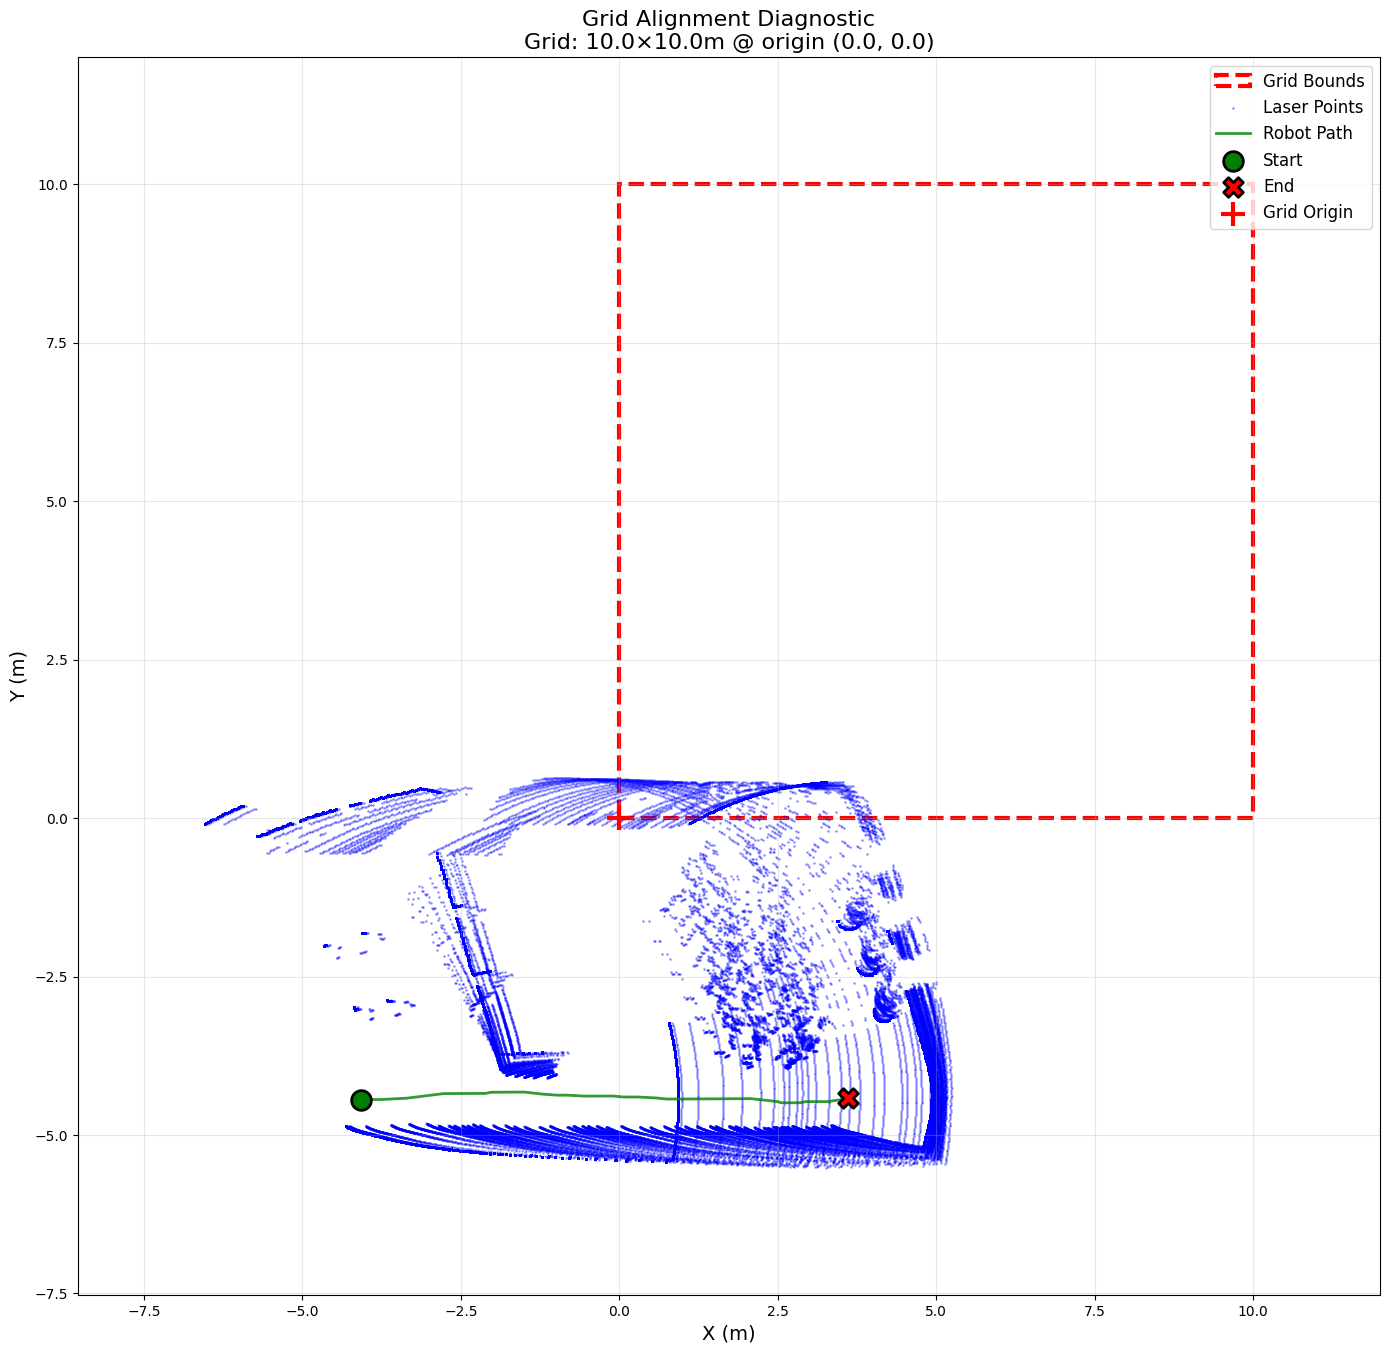


ANALYSIS COMPLETE



In [63]:
class DummyMapper:
    def __init__(self):
        self.origin = (0.0, 0.0)
        self.map_size = (10.0, 10.0)
        self.cell_size = 0.1
        self.grid_height = int(self.map_size[1] / self.cell_size)
        self.grid_width = int(self.map_size[0] / self.cell_size)

mapper = DummyMapper()

print('Program started')

try:
    client = RemoteAPIClient()
    sim = client.require("sim")
    sim.setStepping(True)

    robotname = "kobuki"
    robotHandle = sim.getObject(f'/{robotname}')
    l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
    r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')

    if sim.getSimulationState() != 0:
        sim.stopSimulation()
        time.sleep(1)

    sim.startSimulation()
    sim.step()

    hokuyo_sensor = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")

    L = 0.381
    r = 0.0975
    hist = []
    # laser_global = []

    while (sim_time := sim.getSimulationTime()) < 10:
        posRobo = sim.getObjectPosition(robotHandle, sim.handle_world)
        oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
        hist.append([posRobo[0], posRobo[1]])

        laser_data = hokuyo_sensor.getSensorData()
        if laser_data is not None and len(laser_data) > 0:
            # def transform_laser_to_global(robot_pose: Tuple[np.ndarray, np.ndarray],
            #                               laser_data: np.ndarray,
            #                               laser_to_robot_transform: Optional[np.ndarray] = None) -> np.ndarray:
            pts_global = transform_laser_to_global((posRobo, oriRobo), laser_data)
            laser_global.extend(pts_global.tolist())
            # laser_global.extend(transform_laser_to_global(posRobo, laser_data))

        sim.step()
        time.sleep(0.05)

    sim.setJointTargetVelocity(r_wheel, 0)
    sim.setJointTargetVelocity(l_wheel, 0)

except Exception as e:
    print(f"An error occurred: {e}")

sim.stopSimulation()
print('Program ended')




if len(laser_global) > 0:
    analyze_mapping_alignment(hist, mapper, laser_global)

In [57]:
# Occupancy Grid Debugging Script
# Run this after your simulation to diagnose mapping issues


print('Program started')

try:
    # Conectar ao servidor
    client = RemoteAPIClient()
    sim = client.require("sim")
    sim.setStepping(True)

    # Handles
    robotname = "kobuki"
    robotHandle = sim.getObject(f'/{robotname}')
    l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
    r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
    # hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")  # seu wrapper
    # Reinicia simulação
    initial_sim_state = sim.getSimulationState()
    if initial_sim_state != 0:
        sim.stopSimulation()
        time.sleep(1)

    sim.startSimulation()
    sim.step()

    # Sensor Hokuyo
    hokuyo_sensor = HokuyoSensorSim(sim, "/" + robotname + "/fastHokuyo")

    L = 0.381  
    r = 0.0975 

    hist = []            
    laser_global = []    

    while (sim_time := sim.getSimulationTime()) < 20:
        print(f"Simulation time: {sim_time:.2f} [s]")

    
        posRobo = sim.getObjectPosition(robotHandle, sim.handle_world)
        oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)

        hist.append([posRobo[0], posRobo[1]])

        # Leitura do laser
        laser_data = hokuyo_sensor.getSensorData()
        laser_global.extend(transform_laser_to_global(laser_data, posRobo, oriRobo))

        # Controle simples de desvio
        v, w = 0, 0
        frente = int(len(laser_data) / 2)
        lado_direito = int(len(laser_data) * 1 / 4)
        lado_esquerdo = int(len(laser_data) * 3 / 4)

        if laser_data[frente, 1] > 2:
            v = .5
            w = 0
        elif laser_data[lado_direito, 1] > 1:
            v = 0
            w = np.deg2rad(-45)
        elif laser_data[lado_esquerdo, 1] > 1:
            v = 0
            w = np.deg2rad(45)

        # Modelo cinemático
        wl = v / r - (w * L) / (2 * r)
        wr = v / r + (w * L) / (2 * r)

        sim.setJointTargetVelocity(l_wheel, wl)
        sim.setJointTargetVelocity(r_wheel, wr)

        sim.step()
        time.sleep(0.05)

    
    sim.setJointTargetVelocity(r_wheel, 0)
    sim.setJointTargetVelocity(l_wheel, 0)

except Exception as e:
    print(f"An error occurred: {e}")


sim.stopSimulation()
print('Program ended')


if len(laser_global) > 0:
    analyze_mapping_alignment(hist, mapper, laser_global)
    


Program started
[OK] Initialized Hokuyo sensor: /kobuki/fastHokuyo
     Using buffer signal API for angle/range data
Simulation time: 0.05 [s]
An error occurred: ERROR: Failed to process laser data: ERROR: Hokuyo signals not available. Check that fastHokuyo.lua exports both range_data and angle_data signals.
Program ended


### Ocuppancy grid

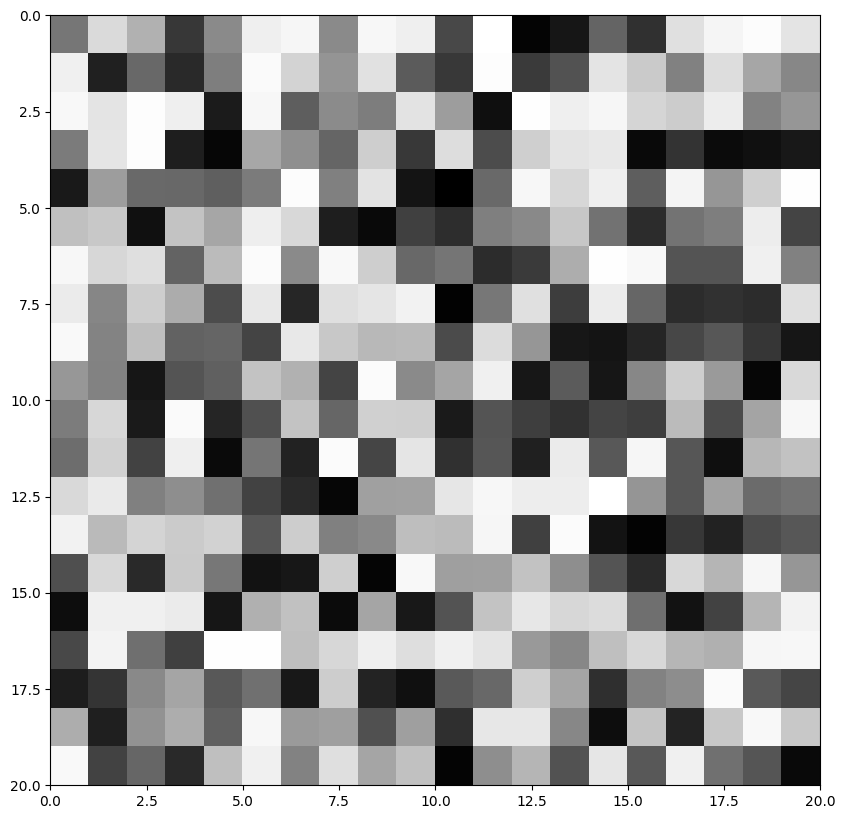

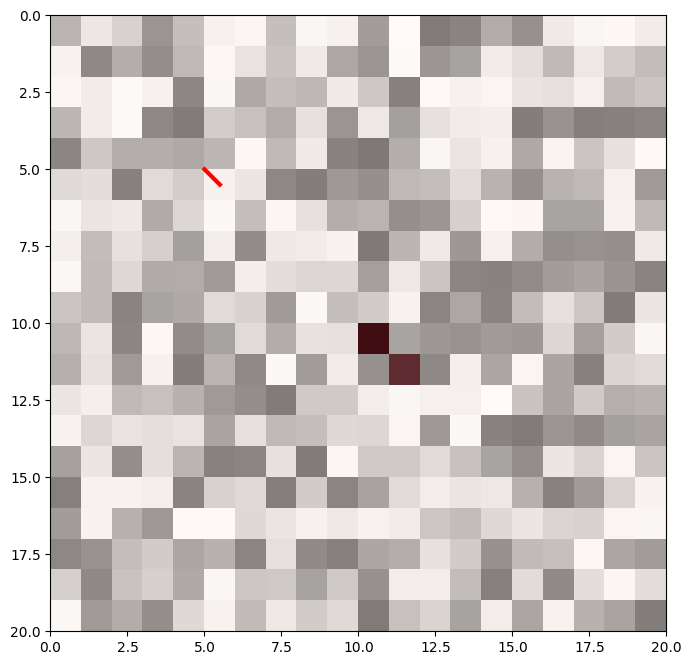

In [5]:

def grid(cell_size, map_size = 10):

    fig = plt.figure(figsize=(10,10), dpi=100)
    ax = fig.add_subplot(111, aspect='equal')

    map_size = np.array([map_size, map_size])

    rows, cols = (map_size/cell_size).astype(int)

    m = np.random.uniform(low=0.0, high=1.0, size=(rows, cols))

    plt.imshow(m, cmap='Greys', origin='upper', extent=(0, cols, rows, 0))


    return m, rows, cols, cell_size


def cellInterception(m, rows, cols, cell_size):

    x, y = 5.5, 5.5
    xo, yo = 5, 5

    # x: column, y: row
    xi, yi = np.floor((1/cell_size)*np.array([x, y])).astype(int)
    xoi, yoi = np.floor((1/cell_size)*np.array([xo, yo])).astype(int)

    line_bresenham = np.zeros((rows, cols), dtype=np.uint8)
    rr, cc = line(yi, xi, yoi, xoi) # r0, c0, r1, c1
    line_bresenham[rr, cc] = 1

    fig = plt.figure(figsize=(8,8), dpi=100)
    ax = fig.add_subplot(111, aspect='equal')

    ax.imshow(m, cmap='Greys', extent=(0, cols, rows, 0))
    ax.imshow(line_bresenham, cmap='Reds', extent=(0, cols, rows, 0), alpha=.5)

    ax.plot([x, xo], [y, yo], 'r-', linewidth=3)



m, rows, cols, cell_size = grid(0.5,10)
cellInterception(m, rows, cols, cell_size)

Step 0: 517 pontos detectados


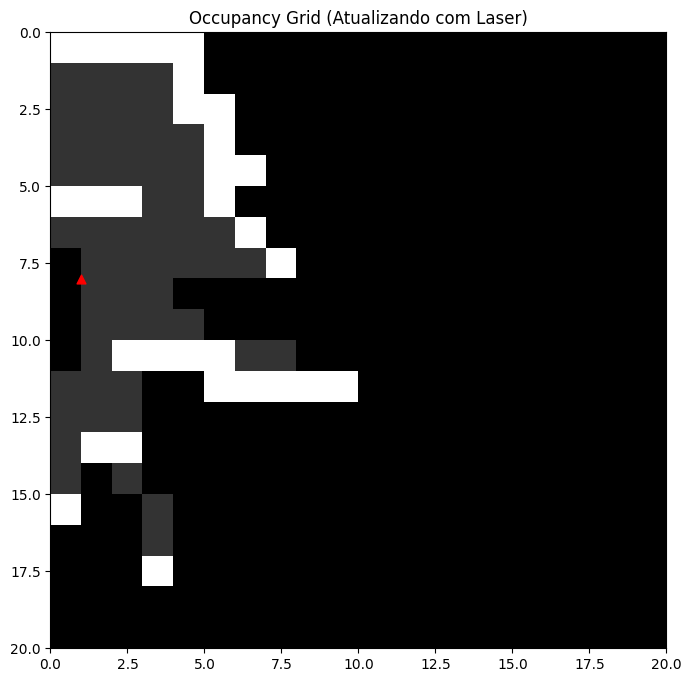

<Figure size 640x480 with 0 Axes>

Step 1: 517 pontos detectados


<Figure size 640x480 with 0 Axes>

Step 2: 517 pontos detectados


<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

Step 98: 504 pontos detectados


<Figure size 640x480 with 0 Axes>

Step 99: 503 pontos detectados


<Figure size 640x480 with 0 Axes>

In [21]:
## começando a funcionar

# --- Função para criar grid inicial ---
def grid(cell_size, map_size=10):
    map_size = np.array([map_size, map_size])
    rows, cols = (map_size / cell_size).astype(int)
    m = np.zeros((rows, cols))  # inicia como desconhecido (0)
    return m, rows, cols, cell_size

# --- Atualiza o grid com leituras do laser ---
def update_occupancy_grid(m, rows, cols, cell_size, global_pts, robot_pos):
    x_r, y_r = robot_pos[0], robot_pos[1]

    for (x, y) in global_pts:
        # converte coordenadas do mundo para o grid (origem no canto inferior esquerdo)
        xi = int((x + 5) / cell_size)  # desloca +5 porque o mapa é 10x10
        yi = int((y + 5) / cell_size)
        xoi = int((x_r + 5) / cell_size)
        yoi = int((y_r + 5) / cell_size)

        if 0 <= xi < cols and 0 <= yi < rows:
            rr, cc = line(yoi, xoi, yi, xi)
            m[rr, cc] = 0.2  # livre
            m[yi, xi] = 1.0  # ocupado

    return m

# --- Setup CoppeliaSim ---
client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)

robotname = "kobuki"

robotHandle = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')


hokuyo = HokuyoSensorSim(sim, "/kobuki/fastHokuyo")


# Cria grid inicial
m, rows, cols, cell_size = grid(0.5, 10)

plt.ion()  # modo interativo
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(m, cmap='Greys', origin='upper', extent=(0, cols, rows, 0))
plt.title("Occupancy Grid (Atualizando com Laser)")

# --- Loop de atualização ---
sim.startSimulation()

for step in range(100):  # número de iterações
    sim.step()

    pos_WR = sim.getObjectPosition(robotHandle, sim.handle_world)
    ori_WR = sim.getObjectOrientation(robotHandle, sim.handle_world)
    laser_data = hokuyo.getSensorData()

    # transforma pontos do laser para coordenadas globais
    global_pts = transform_laser_to_global(laser_data, pos_WR, ori_WR)

    print(f"Step {step}: {len(global_pts)} pontos detectados")


    # atualiza grid
    m = update_occupancy_grid(m, rows, cols, cell_size, global_pts, pos_WR)

    # atualiza visualização
    im = ax.imshow(m, cmap='gray', origin='upper', extent=(0, cols, rows, 0), vmin=0, vmax=1)
    # im.set_data(m)

    ax.clear()
    ax.imshow(m, cmap='gray', origin='upper', extent=(0, cols, rows, 0), vmin=0, vmax=1)

    # converte posição do robô para o grid
    x_r, y_r = pos_WR[0], pos_WR[1]
    xri = int((x_r + 5) / cell_size)
    yri = int((y_r + 5) / cell_size)

    # desenha robô
    ax.scatter(xri, yri, c='red', s=40, marker='^')

    # título e limites fixos
    ax.set_title("Occupancy Grid (Atualizando com Laser)")
    ax.set_xlim(0, cols)
    ax.set_ylim(rows, 0)
    plt.pause(0.05)




    plt.draw()
    plt.pause(0.05)

sim.stopSimulation()
plt.ioff()
plt.show()

# m *= 0.99  # envelhece o mapa lentamente

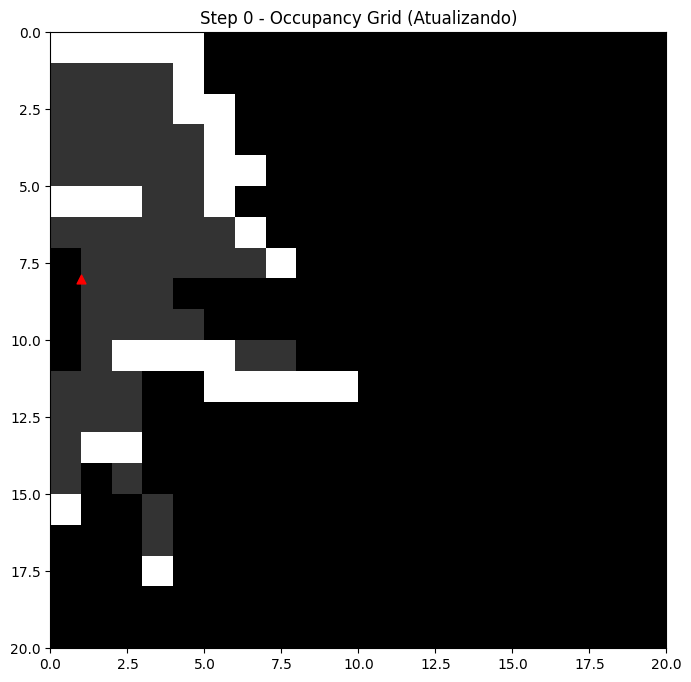

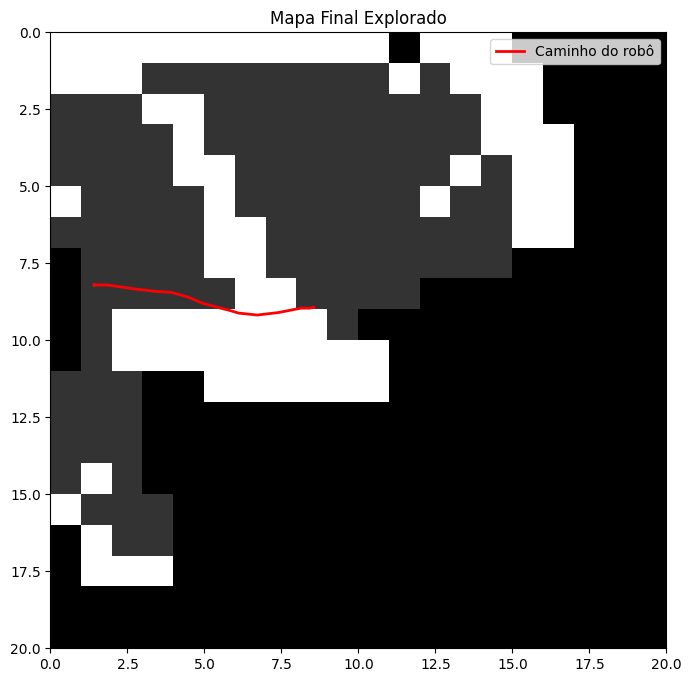

In [23]:
# import numpy as np
# import matplotlib.pyplot as plt
# from skimage.draw import line
# from coppeliasim_zmqremoteapi_client import RemoteAPIClient
# from HokuyoSensorSim import HokuyoSensorSim
# from transform_utils import transform_laser_to_global


# --- Função para criar grid inicial ---
def grid(cell_size, map_size=10):
    map_size = np.array([map_size, map_size])
    rows, cols = (map_size / cell_size).astype(int)
    m = np.zeros((rows, cols))  # inicia como desconhecido (0)
    return m, rows, cols, cell_size


# --- Atualiza o grid com leituras do laser ---
def update_occupancy_grid(m, rows, cols, cell_size, global_pts, robot_pos):
    x_r, y_r = robot_pos[0], robot_pos[1]

    for (x, y) in global_pts:
        # converte coordenadas do mundo para o grid (origem em 0,0, deslocando +5 m)
        xi = int((x + 5) / cell_size)
        yi = int((y + 5) / cell_size)
        xoi = int((x_r + 5) / cell_size)
        yoi = int((y_r + 5) / cell_size)

        if 0 <= xi < cols and 0 <= yi < rows:
            rr, cc = line(yoi, xoi, yi, xi)
            m[rr, cc] = 0.2  # livre
            m[yi, xi] = 1.0  # ocupado

    return m


# --- Setup CoppeliaSim ---
client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)

robotname = "kobuki"

robotHandle = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')

hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")

# Cria grid inicial
m, rows, cols, cell_size = grid(0.5, 10)

plt.ion()
fig, ax = plt.subplots(figsize=(8, 8))
plt.title("Occupancy Grid (Atualizando com Laser)")

# Guarda o caminho percorrido pelo robô
path = []

# --- Loop de atualização ---
sim.startSimulation()

for step in range(100):  # número de iterações
    sim.step()

    pos_WR = sim.getObjectPosition(robotHandle, sim.handle_world)
    ori_WR = sim.getObjectOrientation(robotHandle, sim.handle_world)
    laser_data = hokuyo.getSensorData()

    global_pts = transform_laser_to_global(laser_data, pos_WR, ori_WR)
    m = update_occupancy_grid(m, rows, cols, cell_size, global_pts, pos_WR)

    # salva caminho
    path.append((pos_WR[0], pos_WR[1]))

    # atualização visual (opcional)
    if step % 5 == 0:
        ax.clear()
        ax.imshow(m, cmap='gray', origin='upper', extent=(0, cols, rows, 0), vmin=0, vmax=1)
        x_r, y_r = pos_WR[0], pos_WR[1]
        xri, yri = int((x_r + 5) / cell_size), int((y_r + 5) / cell_size)
        ax.scatter(xri, yri, c='red', s=40, marker='^')
        ax.set_title(f"Step {step} - Occupancy Grid (Atualizando)")
        plt.pause(0.05)

sim.stopSimulation()

# --- Exibe o mapa final ---
plt.ioff()
fig_final, ax_final = plt.subplots(figsize=(8, 8))
ax_final.imshow(m, cmap='gray', origin='upper', extent=(0, cols, rows, 0), vmin=0, vmax=1)

# plota o caminho final percorrido pelo robô
if path:
    path_x = [(x + 5) / cell_size for x, _ in path]
    path_y = [(y + 5) / cell_size for _, y in path]
    ax_final.plot(path_x, path_y, 'r-', linewidth=2, label="Caminho do robô")

ax_final.set_title("Mapa Final Explorado")
ax_final.legend()
plt.show()


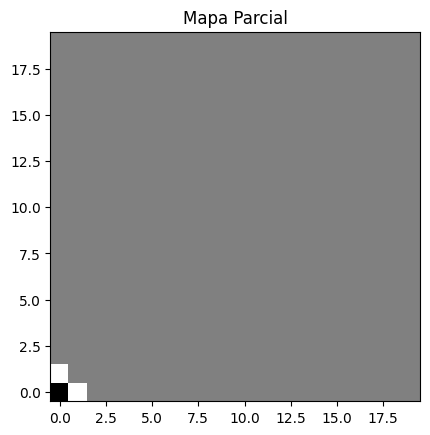

KeyboardInterrupt: 

In [64]:
## melhor até o momento - 8/11 23:20
from matplotlib.colors import ListedColormap

# --- Função auxiliar para converter coordenadas ---
def world_to_grid(pos, grid_origin, cell_size, grid_size):
    gx = int((pos[0] - grid_origin[0]) / cell_size)
    gy = int((pos[1] - grid_origin[1]) / cell_size)
    if 0 <= gx < grid_size[0] and 0 <= gy < grid_size[1]:
        return gx, gy
    return None, None

# --- Inicialização da simulação ---
client = RemoteAPIClient()
sim = client.require("sim")

sim.stopSimulation()
time.sleep(1)
sim.startSimulation()
sim.setStepping(True)

# --- Parâmetros do robô ---
L = 0.230   # distância entre rodas
r = 0.035  # raio da roda

left_motor = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
right_motor = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
robot = sim.getObject(f'/{robotname}')
# hokuyo = sim.getObject("/kobuki/fastHokuyo")
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")


# --- Parâmetros do mapa ---
map_size_m = 10  # mapa 10x10 metros
cell_size = 0.5  # células de 0.5x0.5m
grid_size = (int(map_size_m / cell_size), int(map_size_m / cell_size))
grid_origin = np.array([-map_size_m/2, -map_size_m/2])

# 0 = desconhecido, 1 = livre, 2 = ocupado
occupancy_grid = np.zeros(grid_size)

# --- Objetivo (goal) ---
goal = np.array([3.0, 3.0])

# --- Controle simples Bug2 ---
def go_to_goal(pos, goal):
    dx, dy = goal - pos[:2]
    angle_to_goal = np.arctan2(dy, dx)
    return angle_to_goal

def rep_force(pos, laser_data, R=2, krep=0.5):
    rep = np.zeros(2)
    for d, ang in laser_data:
        if d < R:
            rep += krep * (1.0 / d - 1.0 / R) * np.array([-np.cos(ang), -np.sin(ang)])
    return rep

# --- Atualizar mapa ---
def update_map(log_odds_map, robot_pos, laser_data, l_occ=0.85, l_free=-0.4):
    for d, ang in laser_data:
        wx = robot_pos[0] + d * np.cos(ang + robot_pos[2])
        wy = robot_pos[1] + d * np.sin(ang + robot_pos[2])
        gx, gy = world_to_grid([wx, wy], grid_origin, cell_size, grid_size)
        if gx is not None:
            if d < 1.5:  # obstáculo
                log_odds_map[gx, gy] += l_occ
            else:         # livre
                log_odds_map[gx, gy] += l_free
    return log_odds_map


cmap = ListedColormap(["gray", "white", "black"])

# --- Loop principal ---
for step in range(1000):
    sim.step()
    pos = sim.getObjectPosition(robot, -1)
    ori = sim.getObjectOrientation(robot, -1)
    robot_pos = [pos[0], pos[1], ori[2]]

    laser_data = hokuyo.getSensorData()
    occupancy_grid = update_map(occupancy_grid, robot_pos, laser_data)

    # Controle simples
    angle_to_goal = go_to_goal(robot_pos, goal)
    heading_error = angle_to_goal - robot_pos[2]
    heading_error = np.arctan2(np.sin(heading_error), np.cos(heading_error))

    # Vetor repulsivo
    rep = rep_force(robot_pos, laser_data)
    total_angle = angle_to_goal + np.arctan2(rep[1], rep[0])

    v = 0.2
    w = 1.0 * heading_error

    vl = (v - L/2 * w) / r
    vr = (v + L/2 * w) / r
    sim.setJointTargetVelocity(left_motor, vl)
    sim.setJointTargetVelocity(right_motor, vr)

    # Atualiza mapa a cada 50 passos
    if step % 200 == 0:
        plt.imshow(occupancy_grid.T, origin="lower", cmap=cmap)
        plt.title("Mapa Parcial")
        plt.pause(0.01)

sim.stopSimulation()

# --- Mostrar mapa final ---
plt.figure(figsize=(6,6))
plt.imshow(occupancy_grid.T, origin="lower", cmap=cmap)
plt.title("Mapa Final Explorado")
plt.xlabel("X (células)")
plt.ylabel("Y (células)")
plt.show()


Precise sensor angles read on attempt 1 (684 laser beam readings)


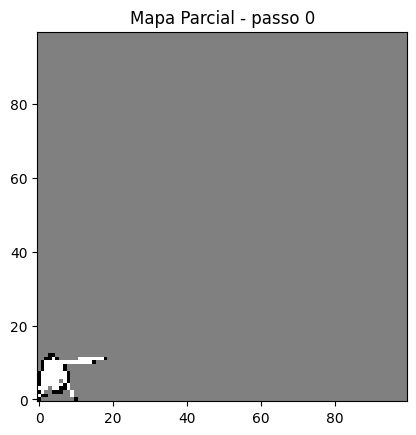

/tmp/ipykernel_6894/3585902371.py:80: RuntimeWarning: overflow encountered in exp
  prob = 1 / (1 + np.exp(-log_odds_map))


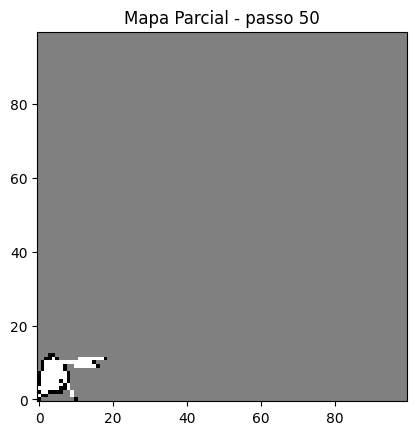

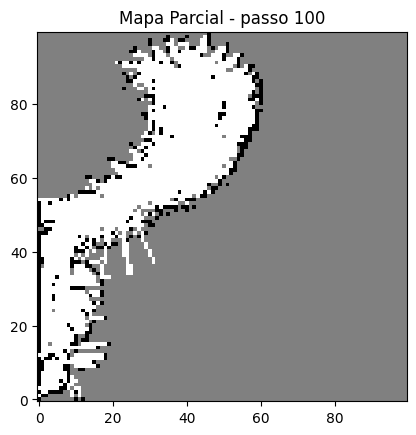

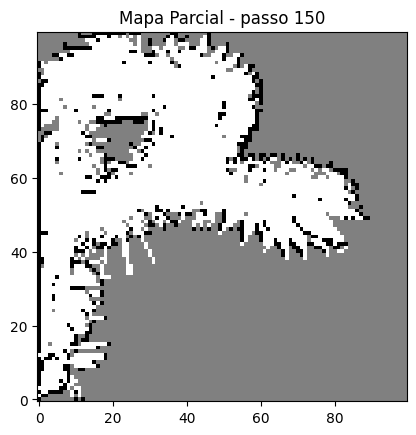

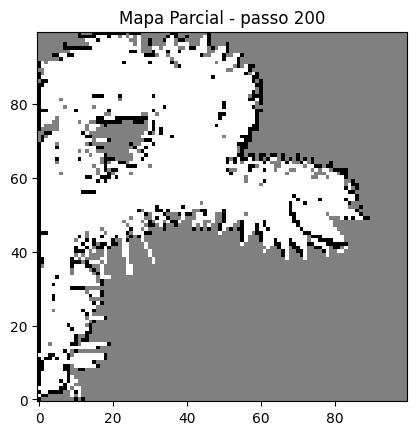

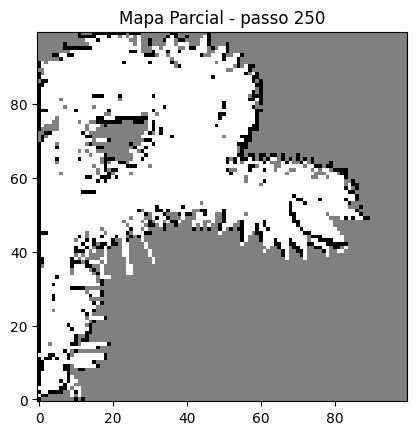

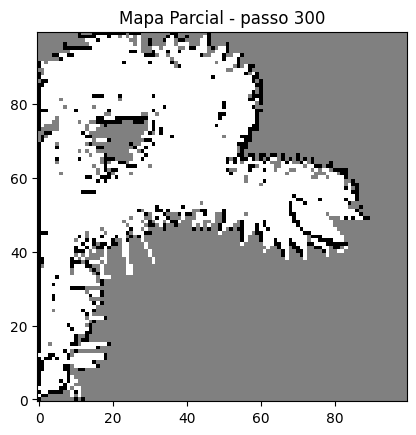

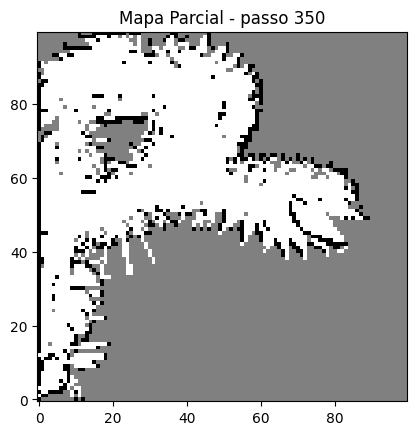

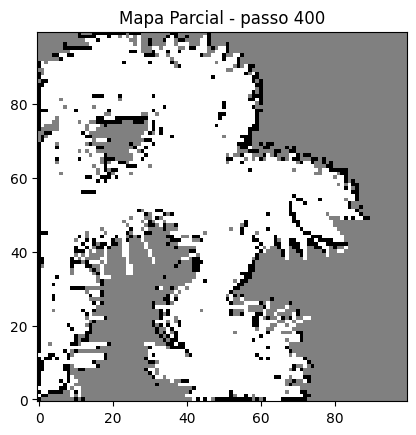

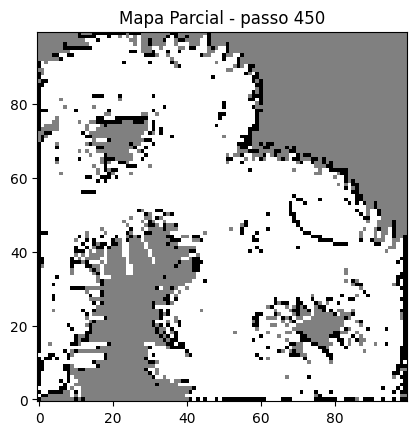

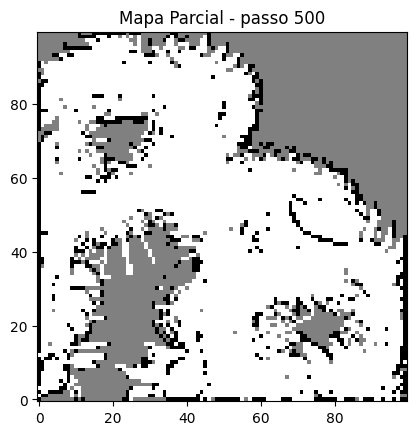

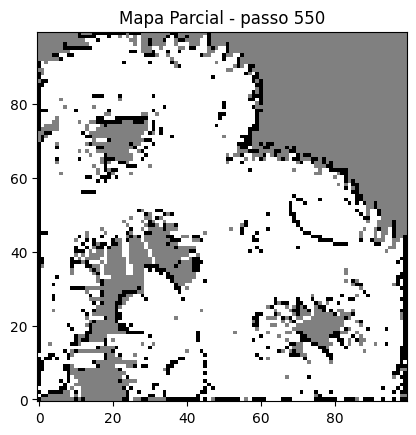

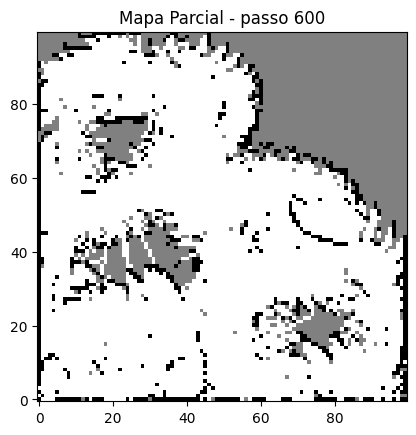

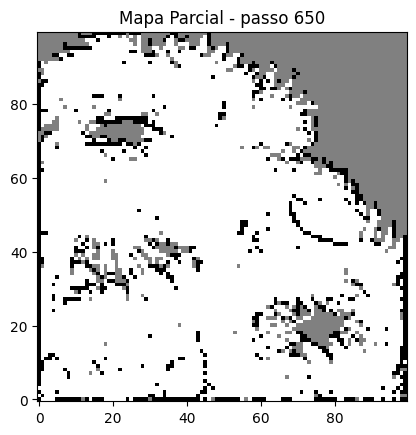

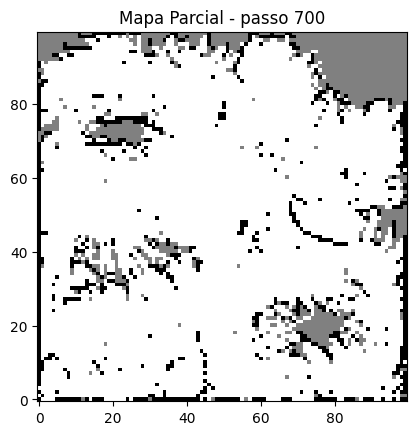

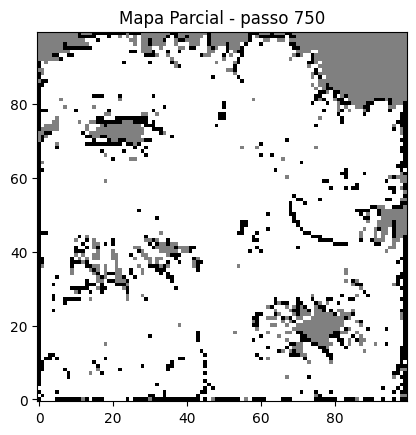

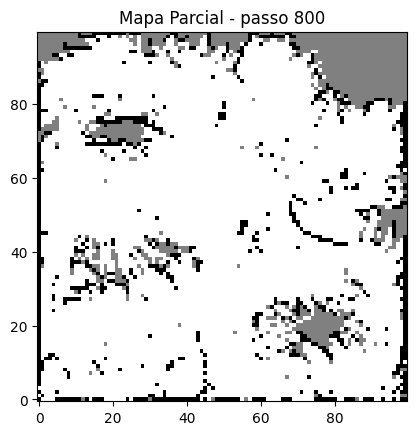

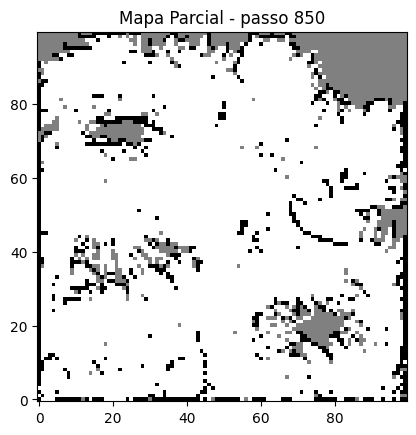

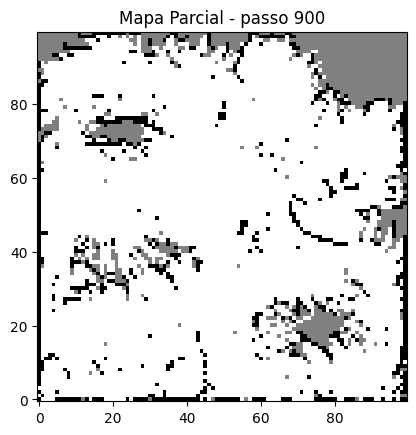

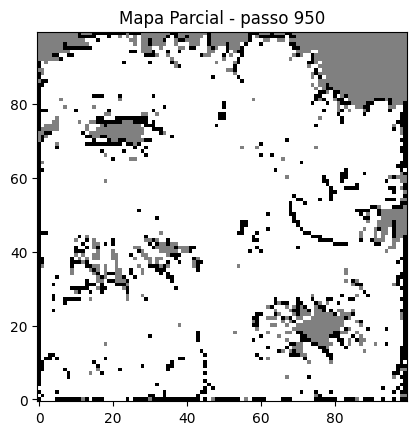

/tmp/ipykernel_6894/3585902371.py:91: RuntimeWarning: overflow encountered in exp
  prob = 1 / (1 + np.exp(-log_odds_map))


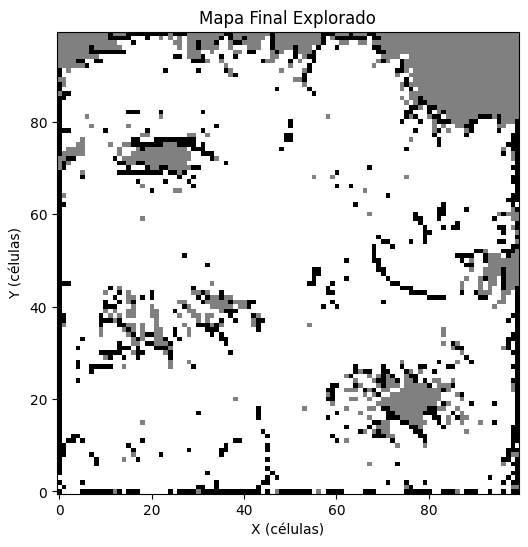

In [100]:
# codigo funcionando teoricamente

from matplotlib.colors import ListedColormap
from skimage.draw import line

# --- Função auxiliar ---
def world_to_grid(pos, grid_origin, cell_size, grid_size):
    gx = int((pos[0] - grid_origin[0]) / cell_size)
    gy = int((pos[1] - grid_origin[1]) / cell_size)
    if 0 <= gx < grid_size[0] and 0 <= gy < grid_size[1]:
        return gx, gy
    return None, None

# --- Atualizar mapa com log-odds ---
def update_map(log_odds_map, robot_pos, laser_data, l_occ=0.85, l_free=-0.4):
    gx_r, gy_r = world_to_grid(robot_pos[:2], grid_origin, cell_size, grid_size)
    if gx_r is None:
        return log_odds_map

    for d, ang in laser_data:
        wx = robot_pos[0] + d * np.cos(ang + robot_pos[2])
        wy = robot_pos[1] + d * np.sin(ang + robot_pos[2])
        gx, gy = world_to_grid([wx, wy], grid_origin, cell_size, grid_size)
        if gx is None or gy is None:
            continue

        # Marcar espaço livre até o obstáculo
        rr, cc = line(gy_r, gx_r, gy, gx)
        log_odds_map[rr, cc] += l_free

        # Marcar obstáculo
        if d < 1.5:
            log_odds_map[gy, gx] += l_occ

    return log_odds_map

# --- Setup CoppeliaSim ---
client = RemoteAPIClient()
sim = client.require("sim")

sim.stopSimulation()
time.sleep(1)
sim.startSimulation()
sim.setStepping(True)

# --- Parâmetros do robô ---
L = 0.230   # distância entre rodas
r = 0.035  # raio da roda

robotname = "kobuki"

left_motor = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
right_motor = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
robot = sim.getObject(f'/{robotname}')
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")


# --- Parâmetros do mapa ---
map_size_m = 10  # mapa 10x10 metros
cell_size = 0.1  # células de 0.5x0.5m
grid_size = (int(map_size_m / cell_size), int(map_size_m / cell_size))
grid_origin = np.array([-map_size_m/2, -map_size_m/2])

# 0 = desconhecido, 1 = livre, 2 = ocupado
# occupancy_grid = np.zeros(grid_size)
# --- Inicialização ---
log_odds_map = np.zeros(grid_size)
cmap = ListedColormap(["gray", "white", "black"])

for step in range(1000):
    sim.step()
    pos = sim.getObjectPosition(robot, -1)
    ori = sim.getObjectOrientation(robot, -1)
    robot_pos = [pos[0], pos[1], ori[2]]

    laser_data = hokuyo.getSensorData()
    log_odds_map = update_map(log_odds_map, robot_pos, laser_data)

    if step % 50 == 0:
        prob = 1 / (1 + np.exp(-log_odds_map))
        grid_vis = np.zeros_like(prob)
        grid_vis[prob < 0.3] = 1  # livre
        grid_vis[prob > 0.7] = 2  # ocupado
        plt.imshow(grid_vis.T, origin="lower", cmap=cmap)
        plt.title(f"Mapa Parcial - passo {step}")
        plt.pause(0.01)

sim.stopSimulation()

# --- Mapa final ---
prob = 1 / (1 + np.exp(-log_odds_map))
grid_vis = np.zeros_like(prob)
grid_vis[prob < 0.3] = 1
grid_vis[prob > 0.7] = 2

plt.figure(figsize=(6,6))
plt.imshow(grid_vis.T, origin="lower", cmap=cmap)
plt.title("Mapa Final Explorado")
plt.xlabel("X (células)")
plt.ylabel("Y (células)")
plt.show()


hi


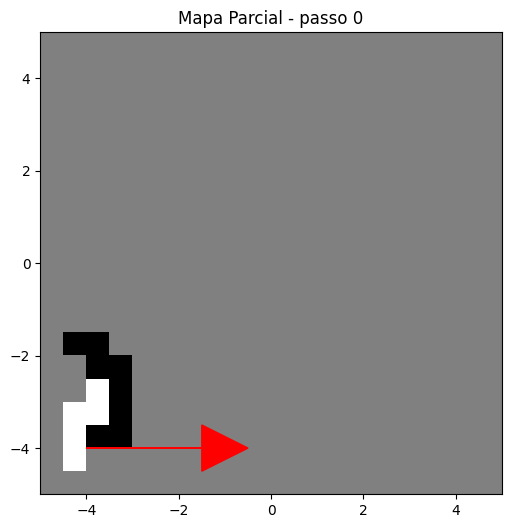

hi
hi
hi


KeyboardInterrupt: 

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap
# from skimage.draw import line
# import time
# from coppeliasim_zmqremoteapi_client import RemoteAPIClient

## fazer isso funcionar

# -----------------------
# Utils
# -----------------------
def world_to_grid_xy(wx, wy):
    """
    Converte mundo (x,y) [m] -> índice de célula (ix, iy)
    ix = coluna (x), iy = linha (y).
    Retorna (ix, iy) ou (None, None) se fora dos limites.
    """
    ix = int((wx - grid_origin[0]) / cell_size)
    iy = int((wy - grid_origin[1]) / cell_size)
    if 0 <= ix < ncols and 0 <= iy < nrows:
        return ix, iy
    return None, None

def parse_laser_data(raw):
    """
    Converte retorno do sensor para lista de (d, ang) (metros, radianos no frame do sensor).
    Ajuste aqui se seu Hokuyo retornar outro formato.
    """
    # Caso já seja uma lista de (d, ang):
    if isinstance(raw, (list, tuple)) and len(raw) and isinstance(raw[0], (list, tuple)):
        return [(float(d), float(a)) for d, a in raw]

    # Caso seja apenas uma lista/array de ranges
    if isinstance(raw, (list, np.ndarray)):
        ranges = np.array(raw, dtype=float)
        n = len(ranges)
        if n == 0:
            return []
        # suposição típica: campo de visão -pi/2..+pi/2
        angles = np.linspace(-np.pi/2, np.pi/2, n)
        return [(float(np.ravel(r)[0]), float(a)) for r, a in zip(ranges, angles)]


    # se vazio ou formato desconhecido
    return []

# -----------------------
# Função de atualização log-odds (corrigida)
# -----------------------
def update_map_log_odds(log_odds_map, robot_pos, laser_data,
                        l_occ=0.9, l_free=-0.4, sensor_offset=SENSOR_OFFSET, max_range=MAX_RANGE):
    """
    robot_pos: [x,y,theta] (m, rad) no frame world
    laser_data: lista de (d, ang_sensor) -> d[m], ang_sensor[rad] no frame do sensor
    Atualiza log_odds_map (shape nrows x ncols) indexado por [row, col] = [iy, ix].
    """
    x_r, y_r, theta_r = robot_pos[0], robot_pos[1], robot_pos[2]

    # índice da célula do robô (coluna, linha)
    ix_r, iy_r = world_to_grid_xy(x_r, y_r)
    if ix_r is None:
        return log_odds_map

    for d, ang in laser_data:
        # filtrar leituras inválidas
        if d <= 0 or d > max_range:
            continue

        global_ang = theta_r + ang + sensor_offset
        wx = x_r + d * np.cos(global_ang)
        wy = y_r + d * np.sin(global_ang)

        ix, iy = world_to_grid_xy(wx, wy)
        if ix is None or iy is None:
            # ponto fora do mapa -> opcional: projetar até a borda
            continue

        # Bresenham: linha de (iy_r, ix_r) até (iy, ix) -> rr (rows), cc (cols)
        rr, cc = line(iy_r, ix_r, iy, ix)
        if len(rr) > 1:
            # marcar as CELULAS INTERMEDIARIAS como livres (exclui a ultima)
            log_odds_map[rr[:-1], cc[:-1]] += l_free

        # marcar a célula de impacto como ocupada
        log_odds_map[iy, ix] += l_occ

    # clamp para estabilidade numérica
    np.clip(log_odds_map, LOG_ODDS_MIN, LOG_ODDS_MAX, out=log_odds_map)
    return log_odds_map

# -----------------------
# Setup CoppeliaSim (exemplo)
# -----------------------
client = RemoteAPIClient()
sim = client.require("sim")
sim.stopSimulation()
time.sleep(0.2)
sim.startSimulation()
sim.setStepping(True)

robotname = "kobuki"
robot = sim.getObject(f'/{robotname}')
left_motor = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
right_motor = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')
hokuyo = HokuyoSensorSim(sim, f"/{robotname}/fastHokuyo")  # seu wrapper



# -----------------------
# Config mapa / constantes
# -----------------------
map_size_m = 10.0
cell_size = 0.5                      # m por célula
ncols = int(map_size_m / cell_size)  # cols = eixo X
nrows = int(map_size_m / cell_size)  # rows = eixo Y
grid_origin = np.array([-map_size_m/2, -map_size_m/2])  # world coord do canto inferior esquerdo da célula (0,0)

# log-odds map: shape (nrows, ncols) -> index como [row, col] = [y, x]
log_odds_map = np.zeros((nrows, ncols))

LOG_ODDS_MIN = -10.0
LOG_ODDS_MAX = 10.0
SENSOR_OFFSET = 0.0  # ajuste aqui (rad). Experimente 0, +pi/2, -pi/2 conforme montagem do sensor
MAX_RANGE = 5.0  # alcance máximo do laser (m)

# colormap: 0=desconhecido(gray), 1=livre(white), 2=ocupado(black)
cmap = ListedColormap(["gray", "white", "black"])

# -----------------------
# Loop principal (visualização em metros)
# -----------------------
plt.ion()
fig, ax = plt.subplots(figsize=(6,6))

robot_path_world = []  # lista de (x,y) world coordinates

for step in range(1000):
    sim.step()
    pos = sim.getObjectPosition(robot, -1)
    ori = sim.getObjectOrientation(robot, -1)
    robot_pos = [pos[0], pos[1], ori[2]]

    laser_data = hokuyo.getSensorData()
    laser_data = parse_laser_data(laser_data)  # lista (d,ang)

    log_odds_map = update_map_log_odds(log_odds_map, robot_pos, laser_data)

    # salvar rastro em coords do mundo
    robot_path_world.append((robot_pos[0], robot_pos[1]))

    if step % 50 == 0:
        print("hi")
        prob = 1.0 / (1.0 + np.exp(-log_odds_map))
        grid_vis = np.zeros_like(prob)
        grid_vis[prob < 0.3] = 1  # livre
        grid_vis[prob > 0.7] = 2  # ocupado

        # --- cálculo do extent ---
        nrows, ncols = grid_vis.shape
        extent = [grid_origin[0], grid_origin[0] + ncols * cell_size,
                    grid_origin[1], grid_origin[1] + nrows * cell_size]

        # --- Atualização do plot ---
        ax.clear()
        ax.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

        # desenhar rastro em coordenadas do mundo
        if robot_path_world:
            xs, ys = zip(*robot_path_world)
            ax.plot(xs, ys, color='blue', linewidth=1)

        # desenhar pose do robô
        arrow_scale = cell_size * 5
        ax.arrow(robot_pos[0], robot_pos[1],
                    arrow_scale*np.cos(robot_pos[2]), arrow_scale*np.sin(robot_pos[2]),
                    head_width=cell_size*2, head_length=cell_size*2, fc='red', ec='red')

        ax.set_title(f"Mapa Parcial - passo {step}")
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        ax.set_aspect('equal')
        plt.pause(0.001)

# parar sim
sim.stopSimulation()

# mostrar mapa final
prob = 1.0 / (1.0 + np.exp(-log_odds_map))
grid_vis = np.zeros_like(prob, dtype=np.uint8)
grid_vis[prob < 0.3] = 1
grid_vis[prob > 0.7] = 2

plt.ioff()
fig2, ax2 = plt.subplots(figsize=(7,7))
extent = [grid_origin[0], grid_origin[0] + ncols*cell_size,
          grid_origin[1], grid_origin[1] + nrows*cell_size]
ax2.imshow(grid_vis, origin='lower', cmap=cmap, extent=extent, vmin=0, vmax=2)

if robot_path_world:
    xs, ys = zip(*robot_path_world)
    ax2.plot(xs, ys, color='blue', linewidth=1)
ax2.arrow(robot_pos[0], robot_pos[1], 0.25*np.cos(robot_pos[2]), 0.25*np.sin(robot_pos[2]),
          head_width=0.08, head_length=0.08, fc='red', ec='red')

ax2.set_title("Mapa Final Explorado")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Y (m)")
ax2.set_aspect('equal')
plt.show()


### Bug algortimo

### Campos Potenciais

In [14]:
# verificar funcao
def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
        scale = world_size / img_size
        x_world = ((x_px - img_size/2) * scale)
        y_world = (-(y_px - img_size/2) * scale) 
        return x_world, y_world


def att_force(q, goal, katt=.01):
    return katt*(goal - q)

def rep_force(q, laser_data, R=3, krep=.1):
    # Se lista estiver vazia
    if not laser_data:
        return np.zeros(2)

    laser_data = np.array(laser_data, dtype=float)

    # Garante que tenha 3 colunas (x, y, r)
    if laser_data.shape[1] == 2:
        # adiciona uma coluna de zeros (raio)
        laser_data = np.hstack([laser_data, np.zeros((laser_data.shape[0], 1))])

    # Vetor posição relativa robô -> obstáculo
    v = q - laser_data[:, :2]

    # Distância ao obstáculo (menos o raio)
    d = np.linalg.norm(v, axis=1) - laser_data[:, 2]
    d = np.maximum(d, 1e-6)  # evita divisão por zero
    d = d.reshape(-1, 1)

    # Força repulsiva
    rep = (1/d**2) * ((1/d) - (1/R)) * (v/d)

    # Zera onde fora do raio de influência
    rep[d.flatten() > R, :] = 0.0

    # Retorna soma das forças
    return krep * np.sum(rep, axis=0)




In [ ]:
print('Program started')

# Incia simulacao
client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)


# constantes -> verificar
K_att = 50
REP_RADIUS = 0.6
REP_GAIN = 15

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

LINEAR_GAIN = 0.25
ANGULAR_GAIN = 2.0
GOAL_TOL = 0.20


#Configuracao do kobuki
L = 0.230  # distancia do centro as rodas (m) (sugerido no pdf)
r = 0.035  # raio das rodas (m) (sugerido no pdf)

robotname = "kobuki"

robotHandle = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')



sim.startSimulation()
sim.step()

# Conectando a sensor
hokuyo_sensor = HokuyoSensorSim(sim, "/kobuki/fastHokuyo")

# funcoes a verificar
world = pixel_to_world(30,34,100,10)
goal_position = np.array([world[0], world[1]])


while True:
    sim_time = sim.getSimulationTime()

    # Pega as posicoes do robo no mapa
    posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
    oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
    robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

    # verifica se o robo chegou no objetivo e finaliza o loop
    if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
        print("Objetivo alcancado.")
        break

    laser_data = hokuyo_sensor.getSensorData()
    laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)

    # onde tudo acontece, verificar no jupyter do professor
    f_att = att_force(robot_pos, goal_position,K_att)
    f_rep = rep_force(robot_pos, laser_global, R = REP_RADIUS, krep = REP_GAIN)

    f_total = f_att + f_rep

    # CONTROLADOR DESAI ET AL. (1998) -> verificar se realmente está correto
    xd, yd = f_total
    theta = oriRobo[2]
    d = L / 2.0  

    J = np.array([
        [np.cos(theta), np.sin(theta)],
        [-np.sin(theta) / d, np.cos(theta) / d]
    ])

    v_cmd, w_cmd = J @ np.array([xd, yd])

    v_cmd *= LINEAR_GAIN
    w_cmd *= ANGULAR_GAIN

    theta_d = np.arctan2(f_total[1], f_total[0])
    erro_theta = np.arctan2(np.sin(theta_d - theta), np.cos(theta_d - theta))
    if abs(erro_theta) > np.deg2rad(45):
        v_cmd *= 0.25

    v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
    w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

    prev_v_cmd = v_cmd

    # cinematica
    v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
    v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

    sim.setJointTargetVelocity(l_wheel, v_l)
    sim.setJointTargetVelocity(r_wheel, v_r)

    # print(f"t={sim_time:.2f} | pos={robot_pos} | v={v_cmd:.3f}, w={np.rad2deg(w_cmd):.1f}°/s | escape={escape_mode} | stuck_t={stuck_timer:.2f}")

    prev_pos = robot_pos.copy()
    sim.step()

sim.stopSimulation()
print('Simulação finalizada.')


Program started


KeyboardInterrupt: 

### Lixo


In [132]:
print('Program started')

# Incia simulacao
client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)


# constantes -> verificar
K_att = 50
REP_RADIUS = 0.8
REP_GAIN = 10




ATT_GAIN = 1.0
REP_GAIN = 80.0
REP_RADIUS = 0.8
MAX_REP_FORCE = 25.0

LINEAR_GAIN = 0.25
ANGULAR_GAIN = 2.0

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

GOAL_TOL = 0.20

prev_v_cmd = 0.0
v_smoothing = 0.12

#Configuracao do kobuki
L = 0.230  # distancia do centro as rodas (m) (sugerido no pdf)
r = 0.035  # raio das rodas (m) (sugerido no pdf)

robotname = "kobuki"

robotHandle = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')



sim.startSimulation()
sim.step()





# --- Inicialização ---
hokuyo_sensor = HokuyoSensorSim(sim, "/kobuki/fastHokuyo")
world = pixel_to_world(70, 54, 100, 10)
goal_position = np.array([world[0], world[1]])

mode = "GO_TO_GOAL"
prev_pos = np.zeros(2)
HIT_POINT = None

while True:
    sim_time = sim.getSimulationTime()
    posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
    oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
    robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

    # --- Condição de parada ---
    if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
        print("Objetivo alcançado.")
        break

    # --- Dados do sensor ---
    laser_data = hokuyo_sensor.getSensorData()
    laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)

    # --- Cálculo de forças ---
    f_att = att_force(robot_pos, goal_position, K_att)
    f_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN)
    f_total = f_att + f_rep

    # --- Controle de modo Bug2 ---
    dist_to_goal_line = np.abs(np.cross(goal_position - prev_pos, robot_pos - prev_pos) /
                               np.linalg.norm(goal_position - prev_pos))
    min_dist_laser = np.min([np.linalg.norm(p - robot_pos) for p in laser_global])

    if mode == "GO_TO_GOAL":
        # Se há obstáculo muito perto, muda para seguir obstáculo
        if min_dist_laser < 0.5:
            mode = "FOLLOW_OBSTACLE"
            HIT_POINT = robot_pos.copy()
            print(f"Entrando em FOLLOW_OBSTACLE | t={sim_time:.2f}")

    elif mode == "FOLLOW_OBSTACLE":
        # Se voltou à linha para o objetivo e está mais próximo que o ponto de hit
        if dist_to_goal_line < 0.1 and np.linalg.norm(robot_pos - goal_position) < np.linalg.norm(HIT_POINT - goal_position):
            mode = "GO_TO_GOAL"
            print(f"Retornando ao GO_TO_GOAL | t={sim_time:.2f}")

        # Reforço: força repulsiva domina, move contornando obstáculo
        f_total = f_rep + 0.2 * f_att  # pequena atração ainda

    # --- Controle diferencial ---
    xd, yd = f_total
    theta = oriRobo[2]
    d = L / 2.0
    J = np.array([
        [np.cos(theta), np.sin(theta)],
        [-np.sin(theta) / d, np.cos(theta) / d]
    ])

    v_cmd, w_cmd = J @ np.array([xd, yd])
    v_cmd *= LINEAR_GAIN
    w_cmd *= ANGULAR_GAIN

    # Ajuste para ângulo de direção
    theta_d = np.arctan2(f_total[1], f_total[0])
    erro_theta = np.arctan2(np.sin(theta_d - theta), np.cos(theta_d - theta))
    if abs(erro_theta) > np.deg2rad(45):
        v_cmd *= 0.25

    v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
    w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

    # Cinemática diferencial
    v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
    v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

    sim.setJointTargetVelocity(l_wheel, v_l)
    sim.setJointTargetVelocity(r_wheel, v_r)

    prev_pos = robot_pos.copy()
    sim.step()

sim.stopSimulation()
print('Simulação finalizada.')


Program started


/tmp/ipykernel_45304/1373973892.py:82: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist_to_goal_line = np.abs(np.cross(goal_position - prev_pos, robot_pos - prev_pos) /


Entrando em FOLLOW_OBSTACLE | t=12.55
Retornando ao GO_TO_GOAL | t=15.35
Entrando em FOLLOW_OBSTACLE | t=15.40
Retornando ao GO_TO_GOAL | t=15.45
Entrando em FOLLOW_OBSTACLE | t=15.50
Retornando ao GO_TO_GOAL | t=16.35
Entrando em FOLLOW_OBSTACLE | t=16.40
Retornando ao GO_TO_GOAL | t=16.45
Entrando em FOLLOW_OBSTACLE | t=16.50
Retornando ao GO_TO_GOAL | t=19.30


ValueError: zero-size array to reduction operation minimum which has no identity

In [133]:
import numpy as np

# ======= CONFIGURAÇÕES =======
DIST_OBST = 0.5     # distância mínima para considerar obstáculo (m)
KP_GOAL = 0.5       # ganho proporcional para controle de direção
WALL_FOLLOW_DIST = 0.4  # distância desejada da parede
TOL_GOAL = 0.2      # tolerância para atingir o alvo (m)

# ======= ESTADOS =======
GO_TO_GOAL = 0
FOLLOW_WALL = 1

# ======= FUNÇÕES =======
def angle_to_goal(q, goal):
    """Retorna o ângulo entre o robô e o objetivo"""
    dx, dy = goal[0] - q[0], goal[1] - q[1]
    return np.arctan2(dy, dx)

def laser_front(laser):
    """Média dos valores frontais do laser"""
    n = len(laser)
    return np.mean(laser[n//2 - 5 : n//2 + 5])

def laser_left(laser):
    """Média dos valores à esquerda"""
    n = len(laser)
    return np.mean(laser[int(0.75*n):n])

def laser_right(laser):
    """Média dos valores à direita"""
    n = len(laser)
    return np.mean(laser[:int(0.25*n)])

def bug2(q, theta, goal, laser):
    """
    Retorna velocidade linear e angular
    q: posição (x, y)
    theta: orientação (rad)
    goal: posição alvo (x, y)
    laser: array com distâncias do sensor laser
    """
    global state
    v = 0.0
    w = 0.0

    # Verifica se chegou ao alvo
    dist_to_goal = np.linalg.norm(goal - q)
    if dist_to_goal < TOL_GOAL:
        return 0, 0

    # Leituras do laser
    front = laser_front(laser)
    left = laser_left(laser)
    right = laser_right(laser)

    # ======= MODO GO TO GOAL =======
    if state == GO_TO_GOAL:
        desired = angle_to_goal(q, goal)
        error_angle = np.arctan2(np.sin(desired - theta), np.cos(desired - theta))

        v = 0.2
        w = KP_GOAL * error_angle

        # Se obstáculo à frente, muda para seguir parede
        if front < DIST_OBST:
            state = FOLLOW_WALL

    # ======= MODO FOLLOW WALL =======
    elif state == FOLLOW_WALL:
        v = 0.15
        error = WALL_FOLLOW_DIST - right  # seguir parede à direita
        w = 1.0 * error

        # Se linha até o alvo está livre, volta para GO_TO_GOAL
        desired = angle_to_goal(q, goal)
        error_angle = np.arctan2(np.sin(desired - theta), np.cos(desired - theta))
        if abs(error_angle) < 0.1 and front > 0.8:
            state = GO_TO_GOAL

    return v, w

# ======= LOOP PRINCIPAL (EXEMPLO) =======
if __name__ == "__main__":
    # posição inicial e alvo
    q = np.array([0.0, 0.0])
    theta = 0.0
    goal = np.array([5.0, 3.0])
    state = GO_TO_GOAL

    # simulação (exemplo com dados fake)
    for step in range(100):
        # laser simulado: 180 medidas de 0° a 180°
        laser = np.random.uniform(0.2, 3.0, 180)
        v, w = bug2(q, theta, goal, laser)
        print(f"Step {step}: v={v:.2f}, w={w:.2f}, state={'GOAL' if state==0 else 'WALL'}")

        # atualização simples (modelo cinemático diferencial)
        dt = 0.1
        q[0] += v * np.cos(theta) * dt
        q[1] += v * np.sin(theta) * dt
        theta += w * dt


Step 0: v=0.20, w=0.27, state=GOAL
Step 1: v=0.20, w=0.26, state=GOAL
Step 2: v=0.20, w=0.25, state=GOAL
Step 3: v=0.20, w=0.23, state=GOAL
Step 4: v=0.20, w=0.22, state=GOAL
Step 5: v=0.20, w=0.21, state=GOAL
Step 6: v=0.20, w=0.20, state=GOAL
Step 7: v=0.20, w=0.19, state=GOAL
Step 8: v=0.20, w=0.18, state=GOAL
Step 9: v=0.20, w=0.18, state=GOAL
Step 10: v=0.20, w=0.17, state=GOAL
Step 11: v=0.20, w=0.16, state=GOAL
Step 12: v=0.20, w=0.15, state=GOAL
Step 13: v=0.20, w=0.15, state=GOAL
Step 14: v=0.20, w=0.14, state=GOAL
Step 15: v=0.20, w=0.13, state=GOAL
Step 16: v=0.20, w=0.13, state=GOAL
Step 17: v=0.20, w=0.12, state=GOAL
Step 18: v=0.20, w=0.11, state=GOAL
Step 19: v=0.20, w=0.11, state=GOAL
Step 20: v=0.20, w=0.10, state=GOAL
Step 21: v=0.20, w=0.10, state=GOAL
Step 22: v=0.20, w=0.09, state=GOAL
Step 23: v=0.20, w=0.09, state=GOAL
Step 24: v=0.20, w=0.09, state=GOAL
Step 25: v=0.20, w=0.08, state=GOAL
Step 26: v=0.20, w=0.08, state=GOAL
Step 27: v=0.20, w=0.07, state=GOAL
St

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

WORLDX, WORLDY = 10, 6 

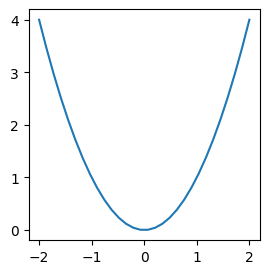

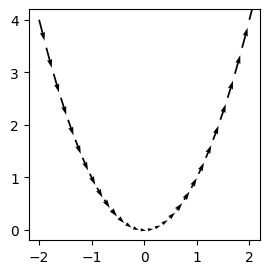

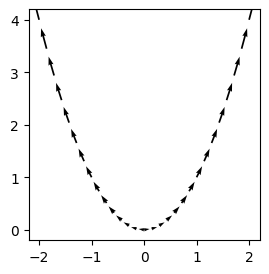

In [55]:
# Atenção com a ordem dos pontos
xn = np.linspace(0, -2, 15)
xp = np.linspace(0, 2, 15)
x =  np.linspace(-2, 2, 30)
y = x**2


fig = plt.figure(figsize=(6,3), dpi=100)
ax = fig.add_subplot(111, aspect='equal')
plt.plot(x, y)



dx = np.gradient(x)
dy = np.gradient(y)

fig = plt.figure(figsize=(6,3), dpi=100)
ax = fig.add_subplot(111, aspect='equal')
ax.quiver(x, y, dx, dy)



fig = plt.figure(figsize=(6,3), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

y = xn**2
dx = np.gradient(xn)
dy = np.gradient(y)
ax.quiver(xn, y, dx, dy)

y = xp**2
dx = np.gradient(xp)
dy = np.gradient(y)
ax.quiver(xp, y, dx, dy)

(0.0, 6.0)

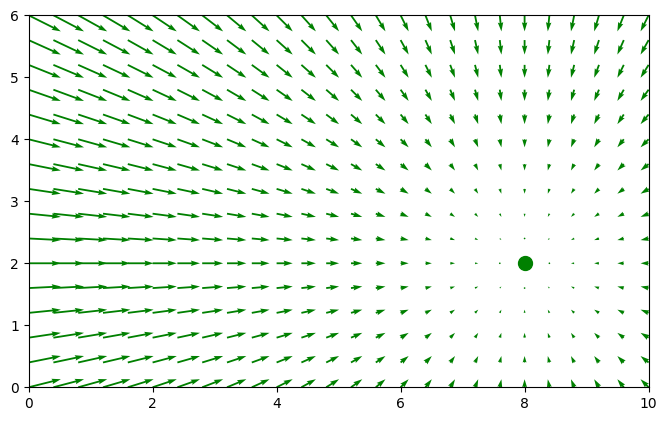

In [56]:
def att_force(q, goal, katt=.01):
    return katt*(goal - q)

goal = np.array([8, 2])

fig = plt.figure(figsize=(8,5), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

XX, YY = np.meshgrid(np.arange(0, WORLDX+.4, .4), np.arange(0, WORLDY+.4, .4))
XY = np.dstack([XX, YY]).reshape(-1, 2)

Fatt = att_force(XY, goal)
Fatt_x = Fatt[:,0]
Fatt_y = Fatt[:,1]

ax.quiver(XX, YY, Fatt_x, Fatt_y, color='g')

plt.plot(goal[0], goal[1], 'og', markersize=10)
    
ax.set_xlim(0, WORLDX)
ax.set_ylim(0, WORLDY)

(0.0, 6.0)

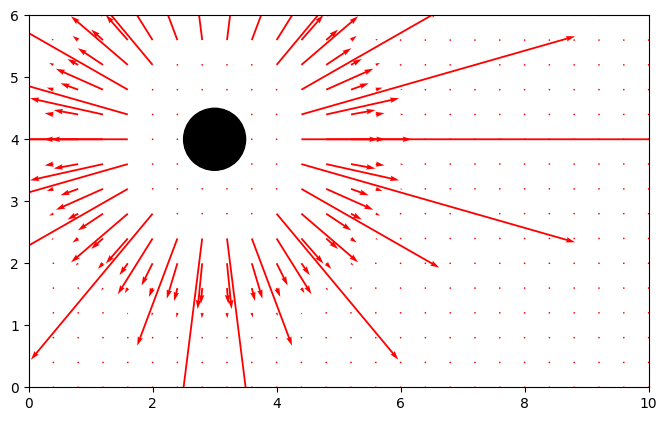

In [ ]:
def rep_force(q, obs, R=3, krep=.1):
    
    # Obstáculo: (x, y, r)
    v = q - obs[0:2]
    d = np.linalg.norm(v, axis=1) - obs[2]
    d = d.reshape((len(v) ,1))
    
    rep = (1/d**2)*((1/d)-(1/R))*(v/d)    
    
    invalid = np.squeeze(d > R)
    rep[invalid, :] = 0
    
    return krep*rep

# Obstáculo: (x, y, r)
laser_data = np.array([3, 4, .5])

fig = plt.figure(figsize=(8,5), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

Frep = rep_force(XY, laser_data)
Frep_x = np.copy(Frep[:,0])  # Cuidado com as referências
Frep_y = np.copy(Frep[:,1])  # Cuidado com as referências

# Threshold para visualização
fmax = .15
Fm = np.linalg.norm(Frep, axis=1)
Frep_x[Fm > fmax], Frep_y[Fm > fmax] = 0, 0

ax.quiver(XX, YY, Frep_x, Frep_y, color='r')
ax.add_patch(patches.Circle((laser_data[0], laser_data[1]), laser_data[2], color='k'))

ax.set_xlim(0, WORLDX)
ax.set_ylim(0, WORLDY)

(0.0, 6.0)

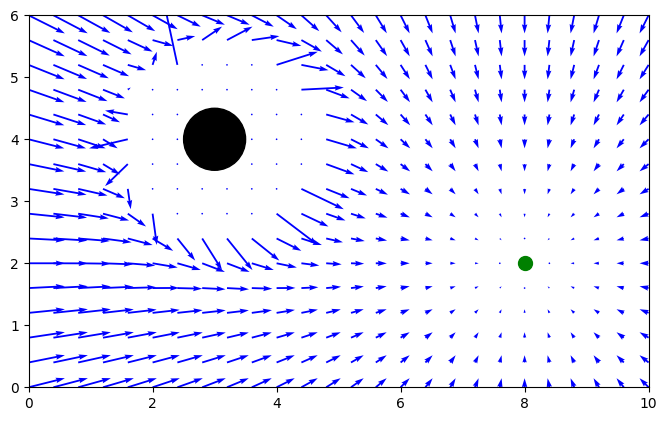

In [ ]:
Ft = Fatt + Frep

# Normalização
# Ft = Ft / np.linalg.norm(Ft, axis=1).reshape((len(Ft), 1))

Ft_x = Ft[:,0]
Ft_y = Ft[:,1]

# Threshold para visualização
fmax = .15
Fm = np.linalg.norm(Ft, axis=1)
Ft_x[Fm > fmax], Ft_y[Fm > fmax] = 0, 0

fig = plt.figure(figsize=(8,5), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

ax.quiver(XX, YY, Ft_x, Ft_y, color='b')
plt.plot(goal[0], goal[1], 'og', markersize=10)
ax.add_patch(patches.Circle((laser_data[0], laser_data[1]), laser_data[2], color='k'))

ax.set_xlim(0, WORLDX)
ax.set_ylim(0, WORLDY)

(0.0, 6.0)

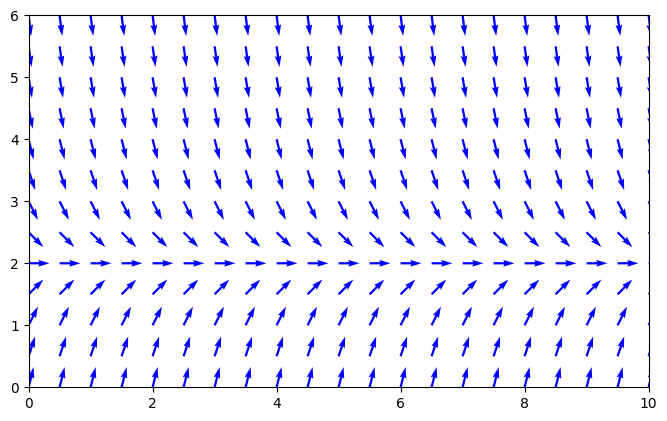

In [59]:
def att_force(q, goal, k=2):
    f = k*(goal - q)
    f[:,0] = 1
    #f[:,1] = 0
    return f

goal = np.array([0, 2])

fig = plt.figure(figsize=(8,5), dpi=100)
ax = fig.add_subplot(111, aspect='equal')

XX, YY = np.meshgrid(np.arange(0, WORLDX+.5, .5), np.arange(0, WORLDY+.5, .5))
XY = np.dstack([XX, YY]).reshape(-1, 2)

Fatt = att_force(XY, goal)
Fatt = Fatt / np.linalg.norm(Fatt, axis=1).reshape((len(Fatt), 1))

Fatt_x = Fatt[:,0]
Fatt_y = Fatt[:,1]

ax.quiver(XX, YY, Fatt_x, Fatt_y, color='b')
    
ax.set_xlim(0, WORLDX)
ax.set_ylim(0, WORLDY)

### Antigo

In [3]:
def rep_force(q, obs_array, R, krep, d_min, max_f_rep):
    if obs_array is None or len(obs_array) == 0:
        return np.zeros(2)

    q = np.asarray(q).reshape(1, -1)
    obs = np.asarray(obs_array).reshape(-1, 2)
    v = q - obs
    d = np.linalg.norm(v, axis=1)
    d_safe = np.maximum(d, d_min)

    within = d < R
    if not np.any(within):
        return np.zeros(2)

    coeff = np.zeros_like(d_safe)
    coeff[within] = krep * ((1.0 / d_safe[within]) - (1.0 / R)) * (1.0 / (d_safe[within] ** 2))
    dirs = v / d_safe.reshape(-1, 1)
    rep = (coeff.reshape(-1, 1) * dirs)
    force_sum = np.sum(rep, axis=0)

    idx_closest = np.argmin(d_safe)
    dir_closest = dirs[idx_closest]
    tangential = np.array([-dir_closest[1], dir_closest[0]])
    tangential_gain = 0.4
    tangential_component = tangential_gain * tangential * min(1.0, np.linalg.norm(force_sum) / (max_f_rep + 1e-6))
    force_sum = force_sum + tangential_component

    norm_f = np.linalg.norm(force_sum)
    if norm_f > max_f_rep:
        force_sum = (force_sum / norm_f) * max_f_rep

    return force_sum


def att_force(q, goal, k, max_f_att):
    f = k * (np.asarray(goal) - np.asarray(q))
    norm = np.linalg.norm(f)
    if norm > max_f_att:
        f = f / norm * max_f_att
    return f

# validacao dos pontos dos sensores
def filter_valid_points(points, robot_pos, min_dist, max_dist):
    if points is None or len(points) == 0:
        return np.empty((0, 2))
    pts = np.asarray(points).reshape(-1, 2)
    d = np.linalg.norm(pts - robot_pos.reshape(1, 2), axis=1)
    mask = np.isfinite(d) & (d > min_dist) & (d < max_dist)
    return pts[mask]


def transform_laser_to_global(laser_points, posRobo_full, oriRobo):
    if laser_points is None or len(laser_points) == 0:
        return np.empty((0, 2))

    x_r, y_r, _ = posRobo_full
    theta = oriRobo[2]

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    pts = np.asarray(laser_points).reshape(-1, 2)
    pts_global = (R @ pts.T).T + np.array([x_r, y_r])
    return pts_global




def escape_if_stuck(robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt):
    stuck_threshold = 0.02
    stuck_time_limit = 1.2
    escape_duration = 2.0
    min_time_between_escapes = 3.0

    moved_dist = np.linalg.norm(robot_pos - prev_pos)
    if moved_dist < stuck_threshold:
        stuck_timer += dt
    else:
        stuck_timer = 0.0

    if (stuck_timer > stuck_time_limit) and (not escape_mode) and ((sim_time - last_escape_time) > min_time_between_escapes):
        escape_mode = True
        last_escape_time = sim_time
        print("[ESCAPE] Robo preso — iniciando rotina de escape")

    if escape_mode:
        if (sim_time - last_escape_time) < escape_duration:
            v = -0.15
            bias = 1.0 if ((int(last_escape_time) % 2) == 0) else -1.0
            w = bias * 0.9
        else:
            escape_mode = False
            v, w = None, None
            stuck_timer = 0.0
    else:
        v, w = None, None

    return v, w, stuck_timer, escape_mode, last_escape_time



def pixel_to_world(x_px, y_px, img_size=64, world_size=10):
        scale = world_size / img_size
        x_world = ((x_px - img_size/2) * scale)
        y_world = (-(y_px - img_size/2) * scale) 
        return x_world, y_world



In [ ]:
print('Program started')

# constantes
ATT_GAIN = 1.0
REP_GAIN = 80.0
REP_RADIUS = 0.8
MAX_REP_FORCE = 25.0

LINEAR_GAIN = 0.25
ANGULAR_GAIN = 2.0

MAX_LINEAR_VEL = 0.8
MAX_ANGULAR_VEL = np.deg2rad(90)

GOAL_TOL = 0.20

prev_v_cmd = 0.0
v_smoothing = 0.12


# simulacao

client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)


#Configuracao robo kobuki

L = 0.230  # distancia do centro as rodas (m)
r = 0.035  # raio das rodas (m)

robotname = "kobuki"

robotHandle = sim.getObject(f'/{robotname}')
l_wheel = sim.getObject(f'/{robotname}/wheel_left_drop_sensor/kobuki_leftMotor')
r_wheel = sim.getObject(f'/{robotname}/wheel_right_drop_sensor/kobuki_rightMotor')

# l_wheel = sim.getObject(f'/{robotname}/kuboki_leftMotor')
# r_wheel = sim.getObject(f'/{robotname}/kuboki_rightMotor')

world = pixel_to_world(89,54,100,10)
goal_position = np.array([world[0], world[1]])


sim.startSimulation()
sim.step()

hokuyo_sensor = HokuyoSensorSim(sim, "/kobuki/fastHokuyo")
has_sensor = True



prev_pos = np.array(sim.getObjectPosition(robotHandle, sim.handle_world)[:2])
stuck_timer = 0.0
escape_mode = False
last_escape_time = -999.0
last_sim_time = sim.getSimulationTime()

while True:
    sim_time = sim.getSimulationTime()
    dt = sim_time - last_sim_time if sim_time - last_sim_time > 0 else 0.05
    last_sim_time = sim_time

    posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
    oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
    robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

    if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
        print("Objetivo alcancado.")
        break

    v_escape, w_escape, stuck_timer, escape_mode, last_escape_time = escape_if_stuck(
        robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt
    )

    if escape_mode and (v_escape is not None):
        v_cmd = v_escape
        w_cmd = w_escape
    else:
        if has_sensor:
            pass
            laser_data = hokuyo_sensor.getSensorData()
            laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)
            laser_global = filter_valid_points(laser_global, robot_pos, min_dist=0.05, max_dist= 0.05)
        else:
            laser_global = np.empty((0, 2))

        f_att = att_force(robot_pos, goal_position, k=ATT_GAIN, max_f_att=20.0)
        f_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN, d_min=0.03, max_f_rep=MAX_REP_FORCE)

        f_total = f_att + f_rep
        if np.linalg.norm(f_total) < 1e-3:
            jitter = 0.05 * (np.random.rand(2) - 0.5)
            f_total = f_total + jitter

    
        # CONTROLADOR DESAI ET AL. (1998)
        xd, yd = f_total
        theta = oriRobo[2]
        d = L / 2.0  

        J = np.array([
            [np.cos(theta), np.sin(theta)],
            [-np.sin(theta) / d, np.cos(theta) / d]
        ])

        v_cmd, w_cmd = J @ np.array([xd, yd])

        v_cmd *= LINEAR_GAIN
        w_cmd *= ANGULAR_GAIN

        theta_d = np.arctan2(f_total[1], f_total[0])
        erro_theta = np.arctan2(np.sin(theta_d - theta), np.cos(theta_d - theta))
        if abs(erro_theta) > np.deg2rad(45):
            v_cmd *= 0.25

        v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
        w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

        prev_v_cmd = v_cmd

    # cinematica diferencial
    v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)robot_pos[0:1]
    v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

    sim.setJointTargetVelocity(l_wheel, v_l)
    sim.setJointTargetVelocity(r_wheel, v_r)

    print(f"t={sim_time:.2f} | pos={robot_pos} | v={v_cmd:.3f}, w={np.rad2deg(w_cmd):.1f}°/s | escape={escape_mode} | stuck_t={stuck_timer:.2f}")

    prev_pos = robot_pos.copy()
    sim.step()

sim.setJointTargetVelocity(l_wheel, 0)
sim.setJointTargetVelocity(r_wheel, 0)



















laser_data = hokuyo_sensor.getSensorData()

print(laser_data)

    
sim.stopSimulation()
print('Simulação finalizada.')

Program started
t=0.05 | pos=[-4.00003551 -4.00000475] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.05
t=0.10 | pos=[-3.99344068 -4.00044135] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.10
t=0.15 | pos=[-3.97411446 -4.00046636] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.15
t=0.20 | pos=[-3.9434876  -4.00050096] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.25 | pos=[-3.90719816 -3.99958634] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.30 | pos=[-3.86770403 -3.99594588] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.35 | pos=[-3.82889943 -3.98926856] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.40 | pos=[-3.79073976 -3.97959461] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.45 | pos=[-3.75326746 -3.96692614] | v=0.800, w=90.0°/s | escape=False | stuck_t=0.00
t=0.50 | pos=[-3.71716873 -3.95155467] | v=0.800, w=-68.0°/s | escape=False | stuck_t=0.00
t=0.55 | pos=[-3.68190513 -3.93396547] | v=0.800, w=-90.0°/s | escape=False | stuck

KeyboardInterrupt: 

In [ ]:

#


In [5]:


# Conexao Coppelia








world = pixel_to_world(89,54,100,10)
goal_position = np.array([world[0], world[1]])



# Informacao do robotino
L = 0.135  # distancia do centro as rodas (m)
r = 0.040  # raio das rodas (m)


# pos_world = {node: pixel_to_world(x_px, y_px, 100, 10) for node, (x_px, y_px) in pos.items()}

# Mdir = np.array([[-r/np.sqrt(3),     0,        r/np.sqrt(3)], 
#                  [r/3,            (-2*r)/3,    r/3], 
#                  [r/(3*L),         r/(3*L),    r/(3*L)]])


# # Posicao inicial do robo - o mesmo da caminho
# start_node = path[0]
# start_pos_world = pos_world[start_node]
# start_pos_sim = [start_pos_world[0], start_pos_world[1], 0.08]
# start_ori_sim = [0, 0, np.deg2rad(90)]




# # Parar a simulacao se estiver executando
# initial_sim_state = sim.getSimulationState()
# if initial_sim_state != 0:
#     sim.stopSimulation()
#     time.sleep(1)

# sim.startSimulation()
# sim.setObjectPosition(robotHandle, sim.handle_world, start_pos_sim)
# sim.setObjectOrientation(robotHandle, sim.handle_world, start_ori_sim)
# sim.step()





# sim.setStepping(True)
# sim.stopSimulation()
# time.sleep(0.5)




# L = 0.381
# r = 0.0975


# hokuyo_sensor = HokuyoSensorSim(sim, "/PioneerP3DX/fastHokuyo")
# has_sensor = True


# sim.startSimulation()

# prev_pos = np.array(sim.getObjectPosition(robotHandle, sim.handle_world)[:2])
# stuck_timer = 0.0
# escape_mode = False
# last_escape_time = -999.0
# last_sim_time = sim.getSimulationTime()

# while True:
#     sim_time = sim.getSimulationTime()
#     dt = sim_time - last_sim_time if sim_time - last_sim_time > 0 else 0.05
#     last_sim_time = sim_time

#     posRobo_full = sim.getObjectPosition(robotHandle, sim.handle_world)
#     oriRobo = sim.getObjectOrientation(robotHandle, sim.handle_world)
#     robot_pos = np.array([posRobo_full[0], posRobo_full[1]])

#     if np.linalg.norm(goal_position - robot_pos) <= GOAL_TOL:
#         print("Objetivo alcancado.")
#         break

#     v_escape, w_escape, stuck_timer, escape_mode, last_escape_time = escape_if_stuck(
#         robot_pos, prev_pos, stuck_timer, escape_mode, last_escape_time, sim_time, dt
#     )

#     if escape_mode and (v_escape is not None):
#         v_cmd = v_escape
#         w_cmd = w_escape
#     else:
#         if has_sensor:
#             laser_data = hokuyo_sensor.getSensorData()
#             laser_global = transform_laser_to_global(laser_data, posRobo_full, oriRobo)
#             laser_global = filter_valid_points(laser_global, robot_pos, min_dist=0.05, max_dist= 0.05)
#         else:
#             laser_global = np.empty((0, 2))

#         f_att = att_force(robot_pos, goal_position, k=ATT_GAIN, max_f_att=20.0)
#         f_rep = rep_force(robot_pos, laser_global, R=REP_RADIUS, krep=REP_GAIN, d_min=0.03, max_f_rep=MAX_REP_FORCE)

#         f_total = f_att + f_rep
#         if np.linalg.norm(f_total) < 1e-3:
#             jitter = 0.05 * (np.random.rand(2) - 0.5)
#             f_total = f_total + jitter

    
#         # CONTROLADOR DESAI ET AL. (1998)
#         xd, yd = f_total
#         theta = oriRobo[2]
#         d = L / 2.0  

#         J = np.array([
#             [np.cos(theta), np.sin(theta)],
#             [-np.sin(theta) / d, np.cos(theta) / d]
#         ])

#         v_cmd, w_cmd = J @ np.array([xd, yd])

#         v_cmd *= LINEAR_GAIN
#         w_cmd *= ANGULAR_GAIN

#         theta_d = np.arctan2(f_total[1], f_total[0])
#         erro_theta = np.arctan2(np.sin(theta_d - theta), np.cos(theta_d - theta))
#         if abs(erro_theta) > np.deg2rad(45):
#             v_cmd *= 0.25

#         v_cmd = np.clip(v_cmd, -MAX_LINEAR_VEL, MAX_LINEAR_VEL)
#         w_cmd = np.clip(w_cmd, -MAX_ANGULAR_VEL, MAX_ANGULAR_VEL)

#         prev_v_cmd = v_cmd

#     # cinematica diferencial
#     v_r = (2.0 * v_cmd + w_cmd * L) / (2.0 * r)
#     v_l = (2.0 * v_cmd - w_cmd * L) / (2.0 * r)

#     sim.setJointTargetVelocity(l_wheel, v_l)
#     sim.setJointTargetVelocity(r_wheel, v_r)

#     print(f"t={sim_time:.2f} | pos={robot_pos} | v={v_cmd:.3f}, w={np.rad2deg(w_cmd):.1f}°/s | escape={escape_mode} | stuck_t={stuck_timer:.2f}")

#     prev_pos = robot_pos.copy()
#     sim.step()

# sim.setJointTargetVelocity(l_wheel, 0)
# sim.setJointTargetVelocity(r_wheel, 0)

sim.stopSimulation()
print('Simulação finalizada.')
    
    

Program started


NameError: name 'pos' is not defined